<a href="https://colab.research.google.com/github/barlaldo/Time-Series/blob/main/SDTMSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error
from dateutil import parser
from scipy.stats import boxcox
from statsmodels.formula.api import ols

In [ ]:
plt.rcParams['figure.figsize'] = (10, 7)  # increase image size
plt.rcParams['figure.dpi'] = 300  # enhance DPI
plt.rcParams['figure.autolayout'] = True  # adjust layout

In [ ]:
df = pd.read_csv("/content/train_2324.csv")
print(df.head())

         date   weekday  ave_days
0  2007-01-04  Thursday  0.179487
1  2007-01-05    Friday  0.500000
2  2007-01-06  Saturday       NaN
3  2007-01-07    Sunday       NaN
4  2007-01-08    Monday  3.521739


In [ ]:
# Objective: forecast all the days from 2015-04-01 through 2015-11-07.
data_start = pd.to_datetime("2007-01-04")
data_start_idx = 0
data_end = pd.to_datetime("2015-03-31")
data_end_idx = len(df['date']) - 1
pred_start = pd.to_datetime("2015-04-01")
pred_start_idx = data_end_idx + 1
pred_end = pd.to_datetime("2015-11-07")
pred_end_idx = data_end_idx + (pred_end - pred_start).days + 1
pred_window_final = pred_end_idx - pred_start_idx + 1

In [ ]:
# Error measure: MAE mean absolute error.
error_func = mae

In [ ]:
# For training and testing dataset splitting, we consider one year test
pred_window = 365
print(pred_window)

365


In [ ]:
# Predict the same prediction days, one year before
train_start = data_start
train_start_idx = data_start_idx
train_end = pred_start - pd.DateOffset(years=1)
train_end_idx = pred_start_idx - 1 - 365
test_start = pred_start - pd.DateOffset(years=1)
test_start_idx = pred_start_idx - 365
test_end = pred_end - pd.DateOffset(years=1)
test_end_idx = pred_end_idx - 365
pred_window = test_end_idx - test_start_idx + 1

In [ ]:
# Output dataset
df_out = pd.DataFrame({
    'date': pd.date_range(start=pred_start, end=pred_end)
})

In [ ]:
# The prediction CSV files must be named `matricola_yyyymmdd.csv`
df_out_name = "897742_202501XX.csv"

In [ ]:
# Dataset preparation
print(df.head())
print(df['ave_days'].iloc[data_start_idx])
print(df.tail())
print(df['ave_days'].iloc[data_end_idx])

         date   weekday  ave_days
0  2007-01-04  Thursday  0.179487
1  2007-01-05    Friday  0.500000
2  2007-01-06  Saturday       NaN
3  2007-01-07    Sunday       NaN
4  2007-01-08    Monday  3.521739
0.17948717948718
            date   weekday   ave_days
3004  2015-03-27    Friday  38.580756
3005  2015-03-28  Saturday   1.040000
3006  2015-03-29    Sunday  42.000000
3007  2015-03-30    Monday  63.477124
3008  2015-03-31   Tuesday  40.496689
40.4966887417219


In [ ]:
# Date format
df['date_str'] = df['date']
df['date'] = pd.to_datetime(df['date'], format="%Y-%m-%d")

print(df.head())

        date   weekday  ave_days    date_str
0 2007-01-04  Thursday  0.179487  2007-01-04
1 2007-01-05    Friday  0.500000  2007-01-05
2 2007-01-06  Saturday       NaN  2007-01-06
3 2007-01-07    Sunday       NaN  2007-01-07
4 2007-01-08    Monday  3.521739  2007-01-08


In [ ]:
# Null values
print(f"NaN count: {df['ave_days'].isna().sum()}")
print(f"NA count: {df['ave_days'].isna().sum()}")
print(f"Inf count: {np.isinf(df['ave_days']).sum()}")

# Cover null values by copying the previous value in the time series
df['ave_days_original'] = df['ave_days']
df['ave_days'].fillna(method='ffill', inplace=True)

print(f"NA count: {df['ave_days'].isna().sum()}")

NaN count: 202
NA count: 202
Inf count: 0
NA count: 0


<ipython-input-68-53c6b9f931e4>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ave_days'].fillna(method='ffill', inplace=True)
<ipython-input-68-53c6b9f931e4>:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['ave_days'].fillna(method='ffill', inplace=True)


In [ ]:
# Check for negative values
print(f"Negative count: {(df['ave_days'] < 0).sum()}")
print(f"Positive count: {(df['ave_days'] > 0).sum()}")

# Zero values can sometimes cause problems
print(f"Zero count: {(df['ave_days'] == 0).sum()}")

zero_replacement = 0.00001
df['ave_days'].replace(0, zero_replacement, inplace=True)

print(f"Zero count: {(df['ave_days'] == 0).sum()}")

Negative count: 0
Positive count: 2984
Zero count: 25
Zero count: 0


<ipython-input-69-b53bdd9c81b8>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ave_days'].replace(0, zero_replacement, inplace=True)


In [ ]:
df.index = pd.to_datetime(df.date)

# Split the DataFrame into training and testing sets based on the index (date)
df_train = df[df.date < pd.Timestamp('2013-03-31')].copy()
df_test = df[df.date >= pd.Timestamp('2013-03-31')].copy()

df_train

,date,weekday,ave_days,date_str,ave_days_original
date,,,,,
2007-01-04,2007-01-04,Thursday,0.179487,2007-01-04,0.179487
2007-01-05,2007-01-05,Friday,0.500000,2007-01-05,0.500000
2007-01-06,2007-01-06,Saturday,0.500000,2007-01-06,NaN
2007-01-07,2007-01-07,Sunday,0.500000,2007-01-07,NaN
2007-01-08,2007-01-08,Monday,3.521739,2007-01-08,3.521739
...,...,...,...,...,...
2013-03-26,2013-03-26,Tuesday,25.945813,2013-03-26,25.945813
2013-03-27,2013-03-27,Wednesday,31.072948,2013-03-27,31.072948
2013-03-28,2013-03-28,Thursday,44.032738,2013-03-28,44.032738


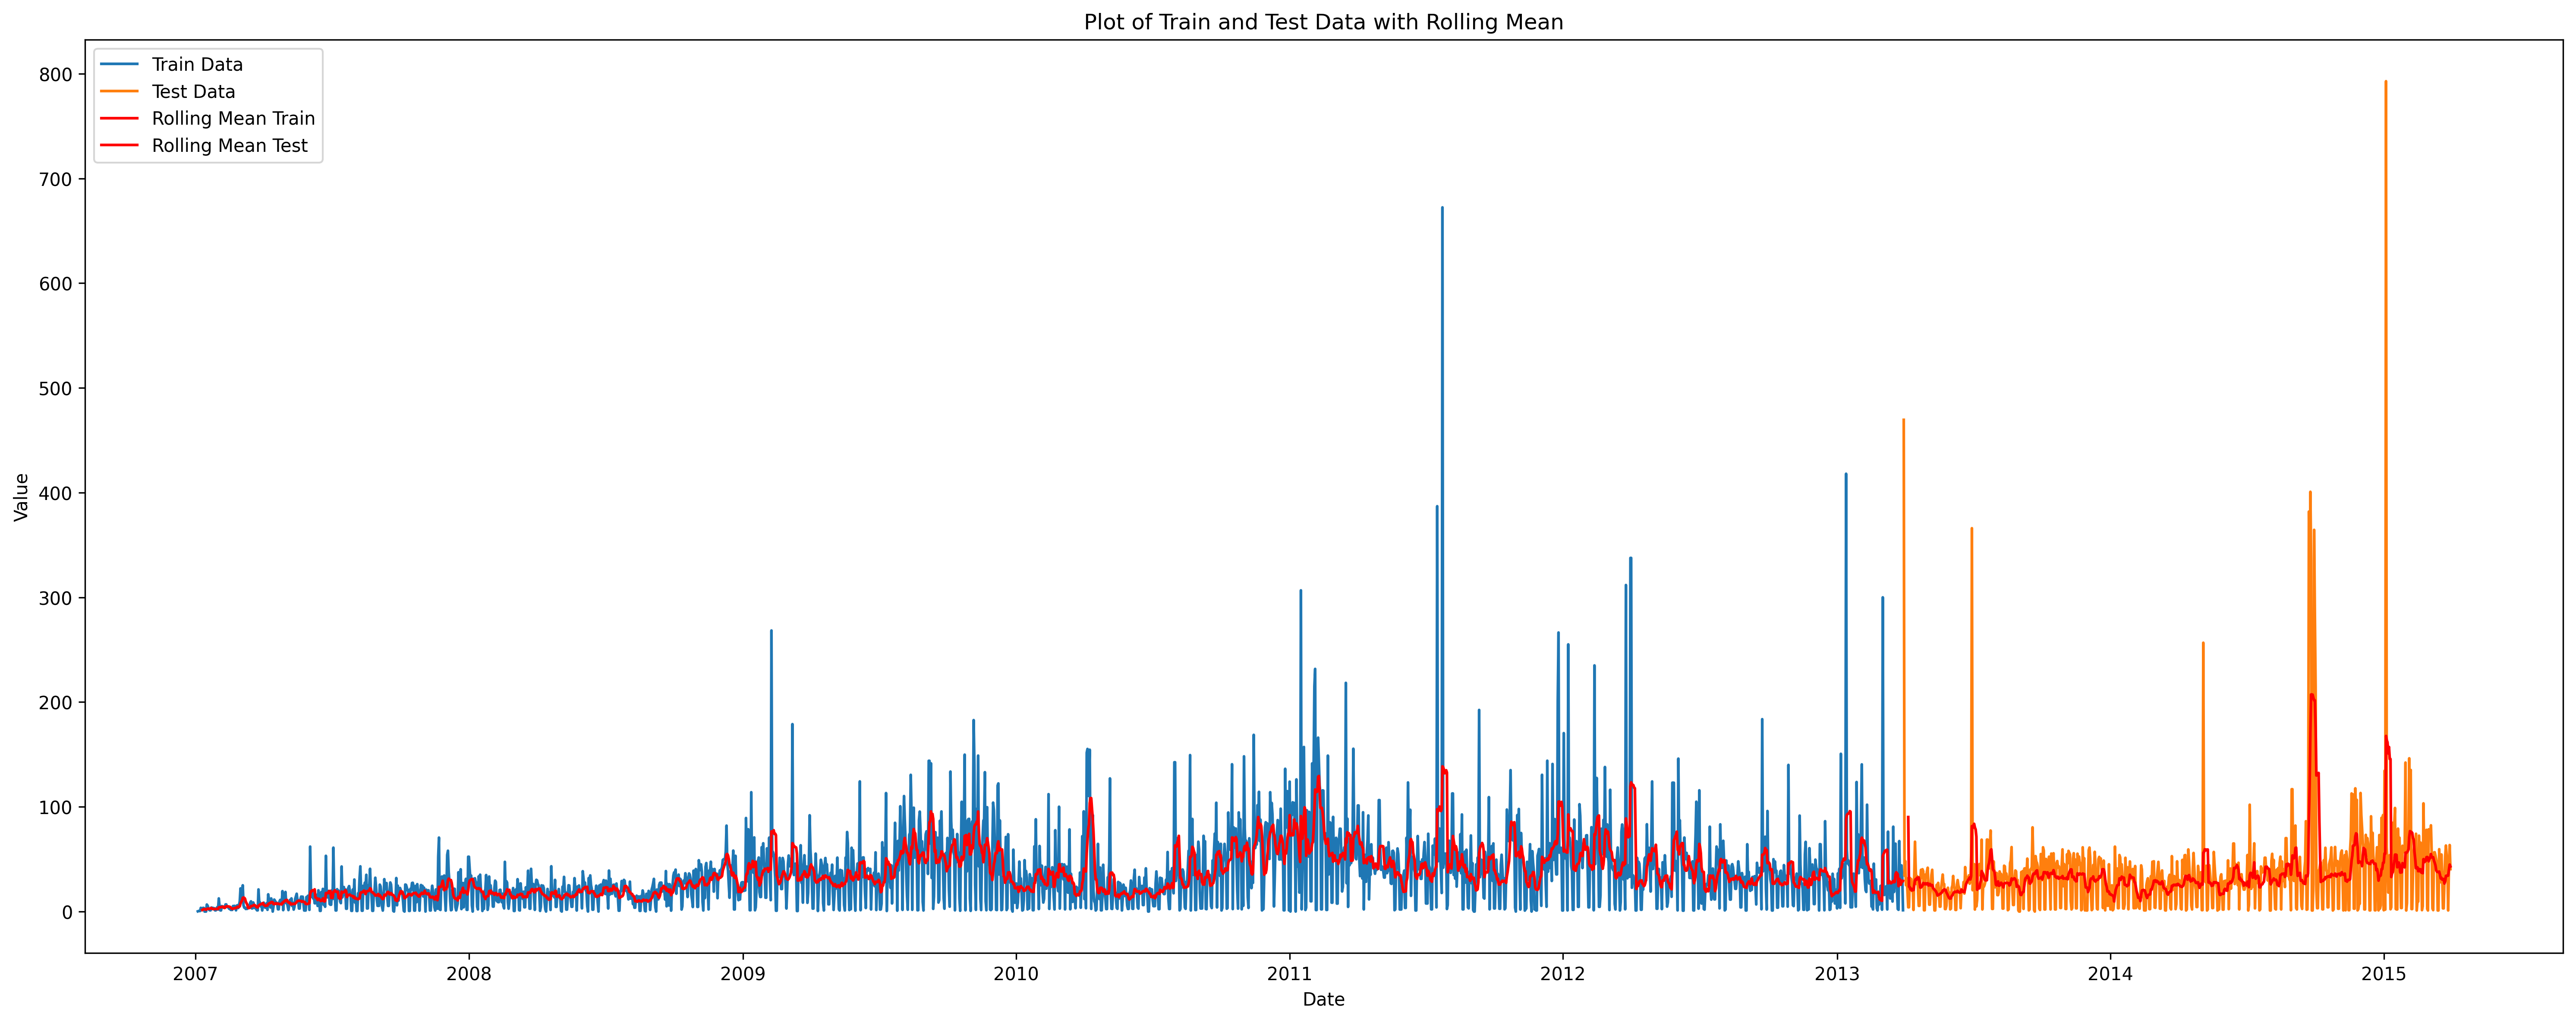

In [ ]:
import matplotlib.pyplot as plt

# Assuming df_train and df_test are your DataFrame variables
# Calculate the rolling mean with a window size of your choice
# Select only the 'ave_days' column for the rolling mean calculation
rolling_mean_train = df_train['ave_days'].rolling(window=7).mean()
rolling_mean_test = df_test['ave_days'].rolling(window=7).mean()

# Plot the original data and the rolling mean
plt.figure(figsize=(20, 8))
plt.plot(df_train['ave_days'], label='Train Data')  # Plot 'ave_days' column for train data
plt.plot(df_test['ave_days'], label='Test Data')  # Plot 'ave_days' column for test data
plt.plot(rolling_mean_train, label='Rolling Mean Train', linestyle='-', color='red')
plt.plot(rolling_mean_test, label='Rolling Mean Test', linestyle='-', color='red')

# Add labels and legend
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Plot of Train and Test Data with Rolling Mean')
plt.legend()

# Show the plot
plt.show()

In [ ]:
# Time series
ts = pd.Series(df['ave_days'].values, index=df['date'])
ts_original = pd.Series(df['ave_days_original'].values, index=df['date'])

ts_full = ts.reindex(pd.date_range(start=df['date'].min(), end=pred_end)).fillna(np.nan)
ts_full_original = ts_original.reindex(pd.date_range(start=df['date'].min(), end=pred_end)).fillna(np.nan)

Zero count: 0


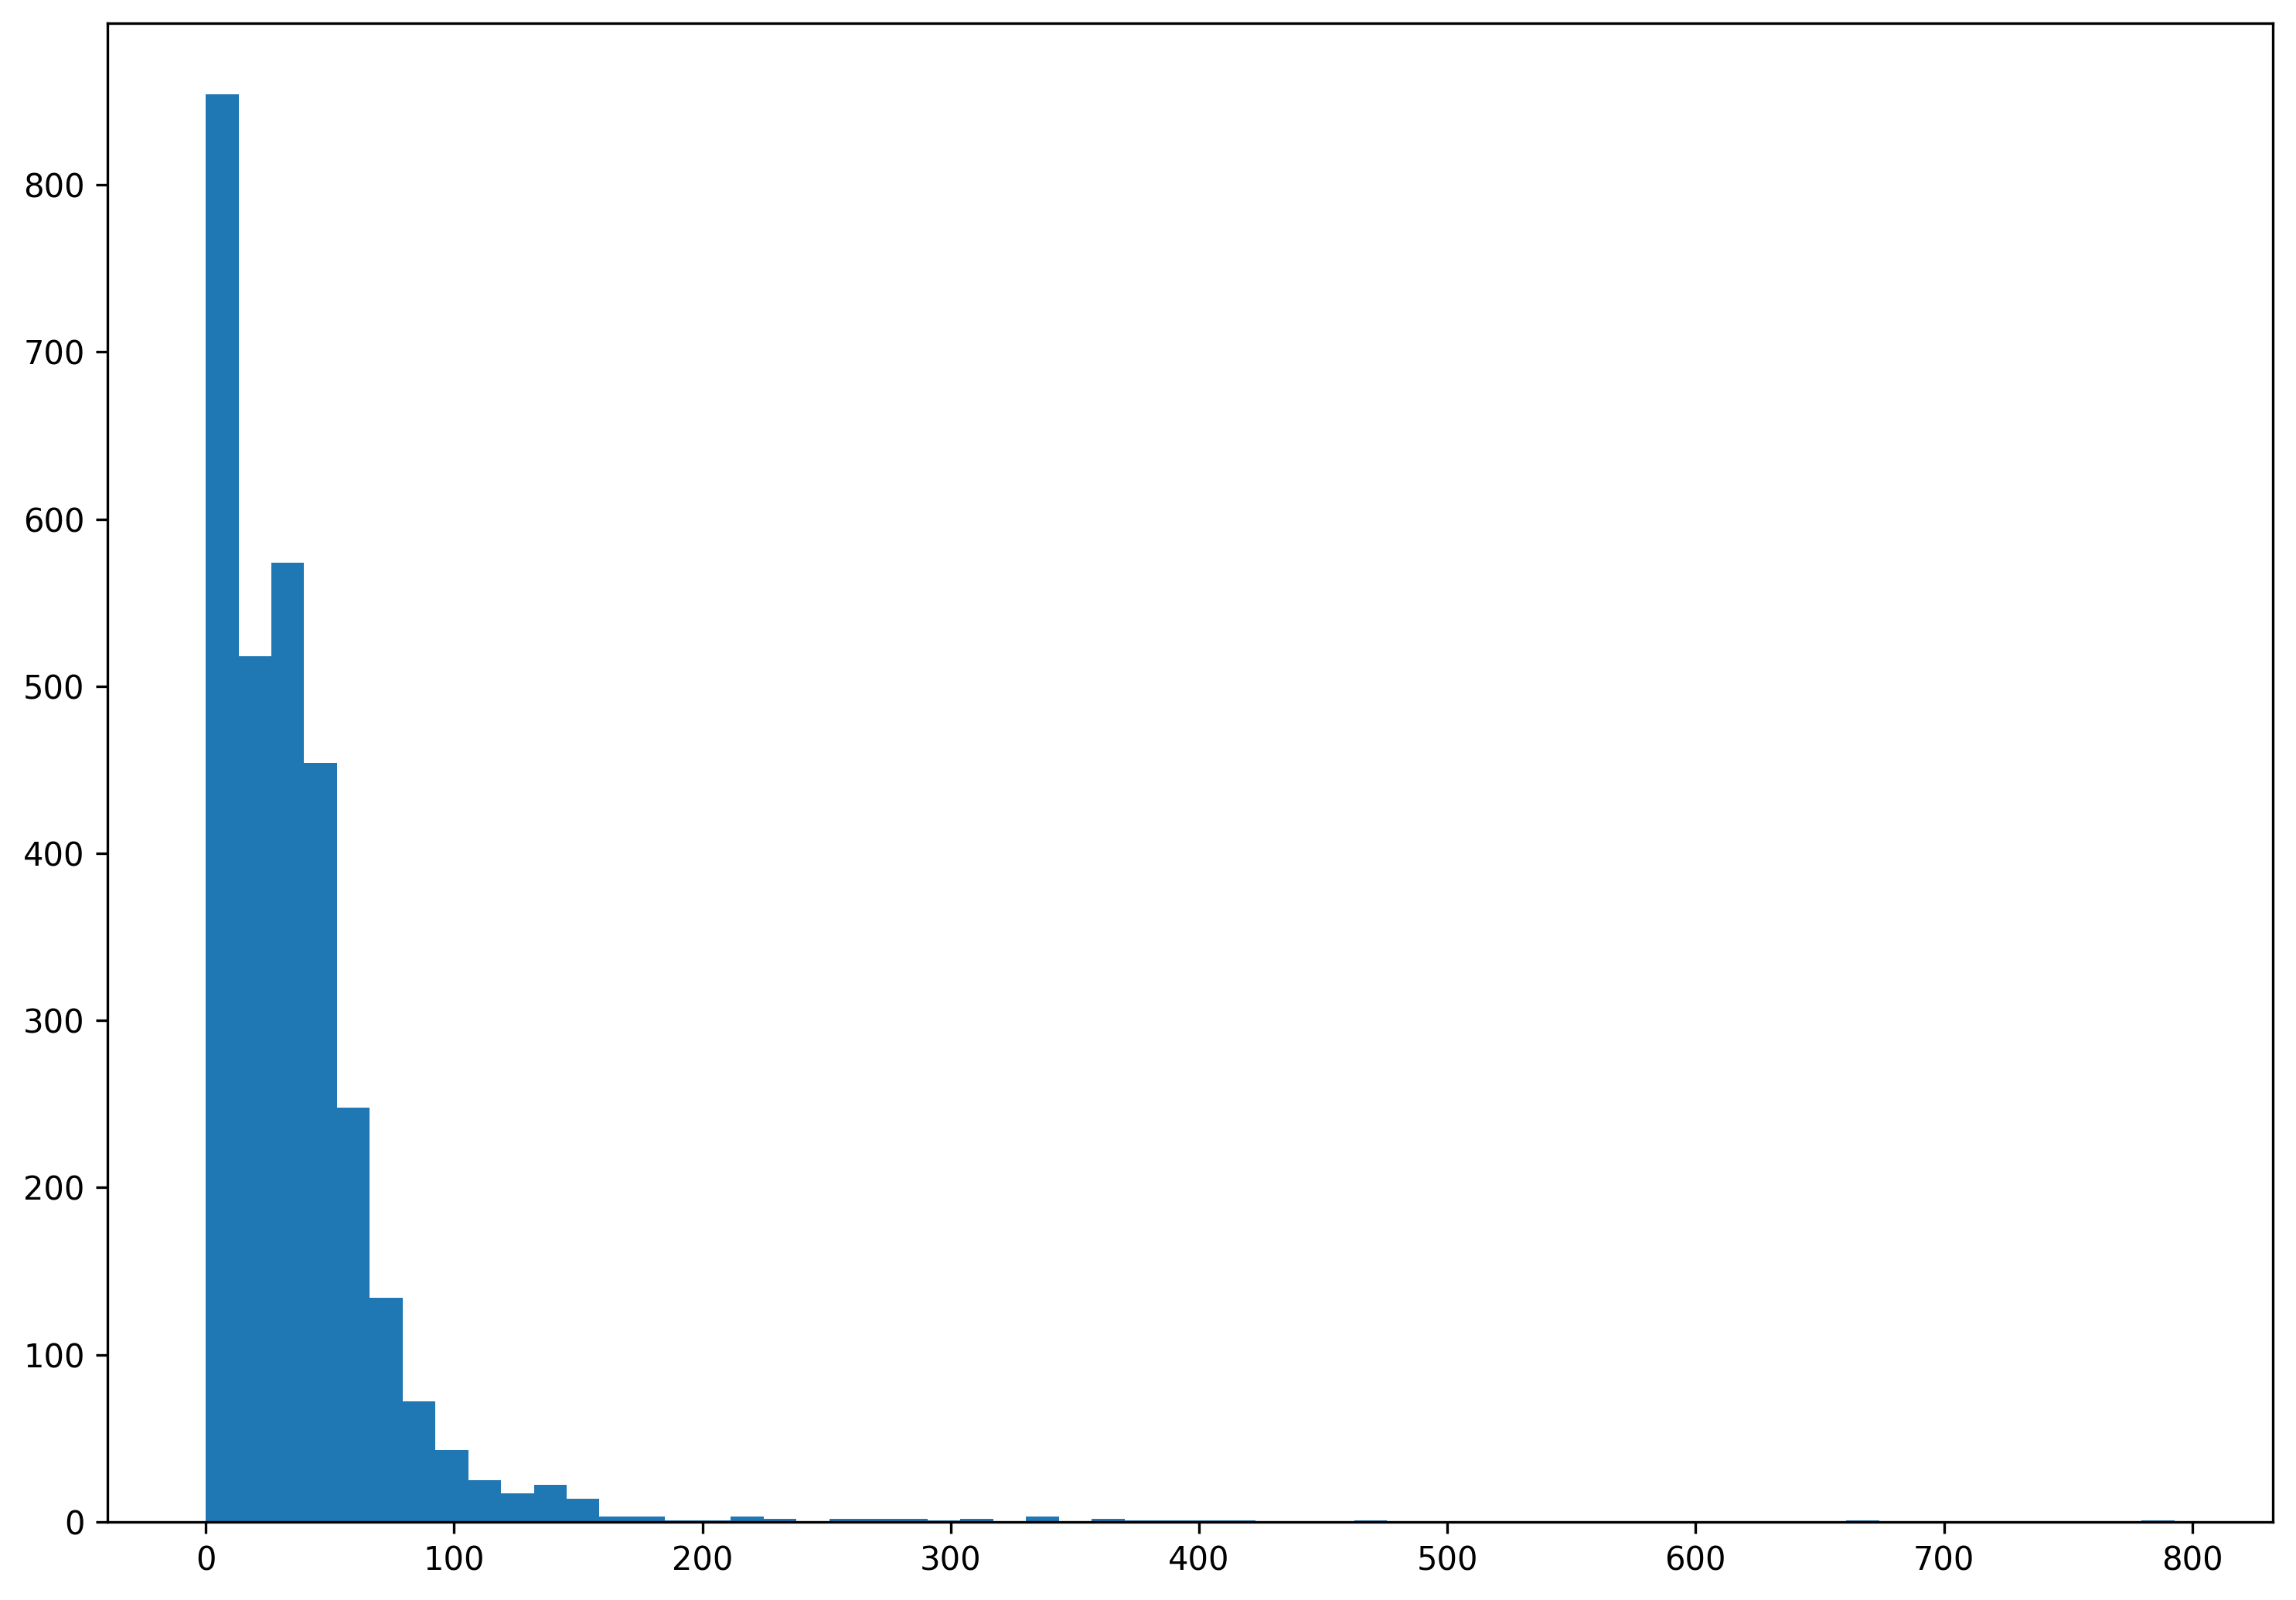

In [ ]:
# Descriptive statistics
print(f"Zero count: {(df['ave_days'] == 0).sum()}")
plt.hist(df['ave_days'], bins=60)
plt.show()

In [ ]:
# Outliers
q25 = ts.quantile(0.25)
print(q25)
q75 = ts.quantile(0.75)
print(q75)
iqr = q75 - q25
print(iqr)
outlier_threshold_low = q25 - (1.5 * iqr)
print(outlier_threshold_low)
outlier_threshold_high = q75 + (1.5 * iqr)
print(outlier_threshold_high)

9.54471544715447
47.9782608695652
38.43354542241073
-48.10560268646162
105.6285790031813


In [ ]:
# Outliers mitigation
print(len(ts[ts > outlier_threshold_high]))
ts[ts > outlier_threshold_high] = outlier_threshold_high
print(len(ts[ts < outlier_threshold_low]))
ts[ts < outlier_threshold_low] = outlier_threshold_low

112
0


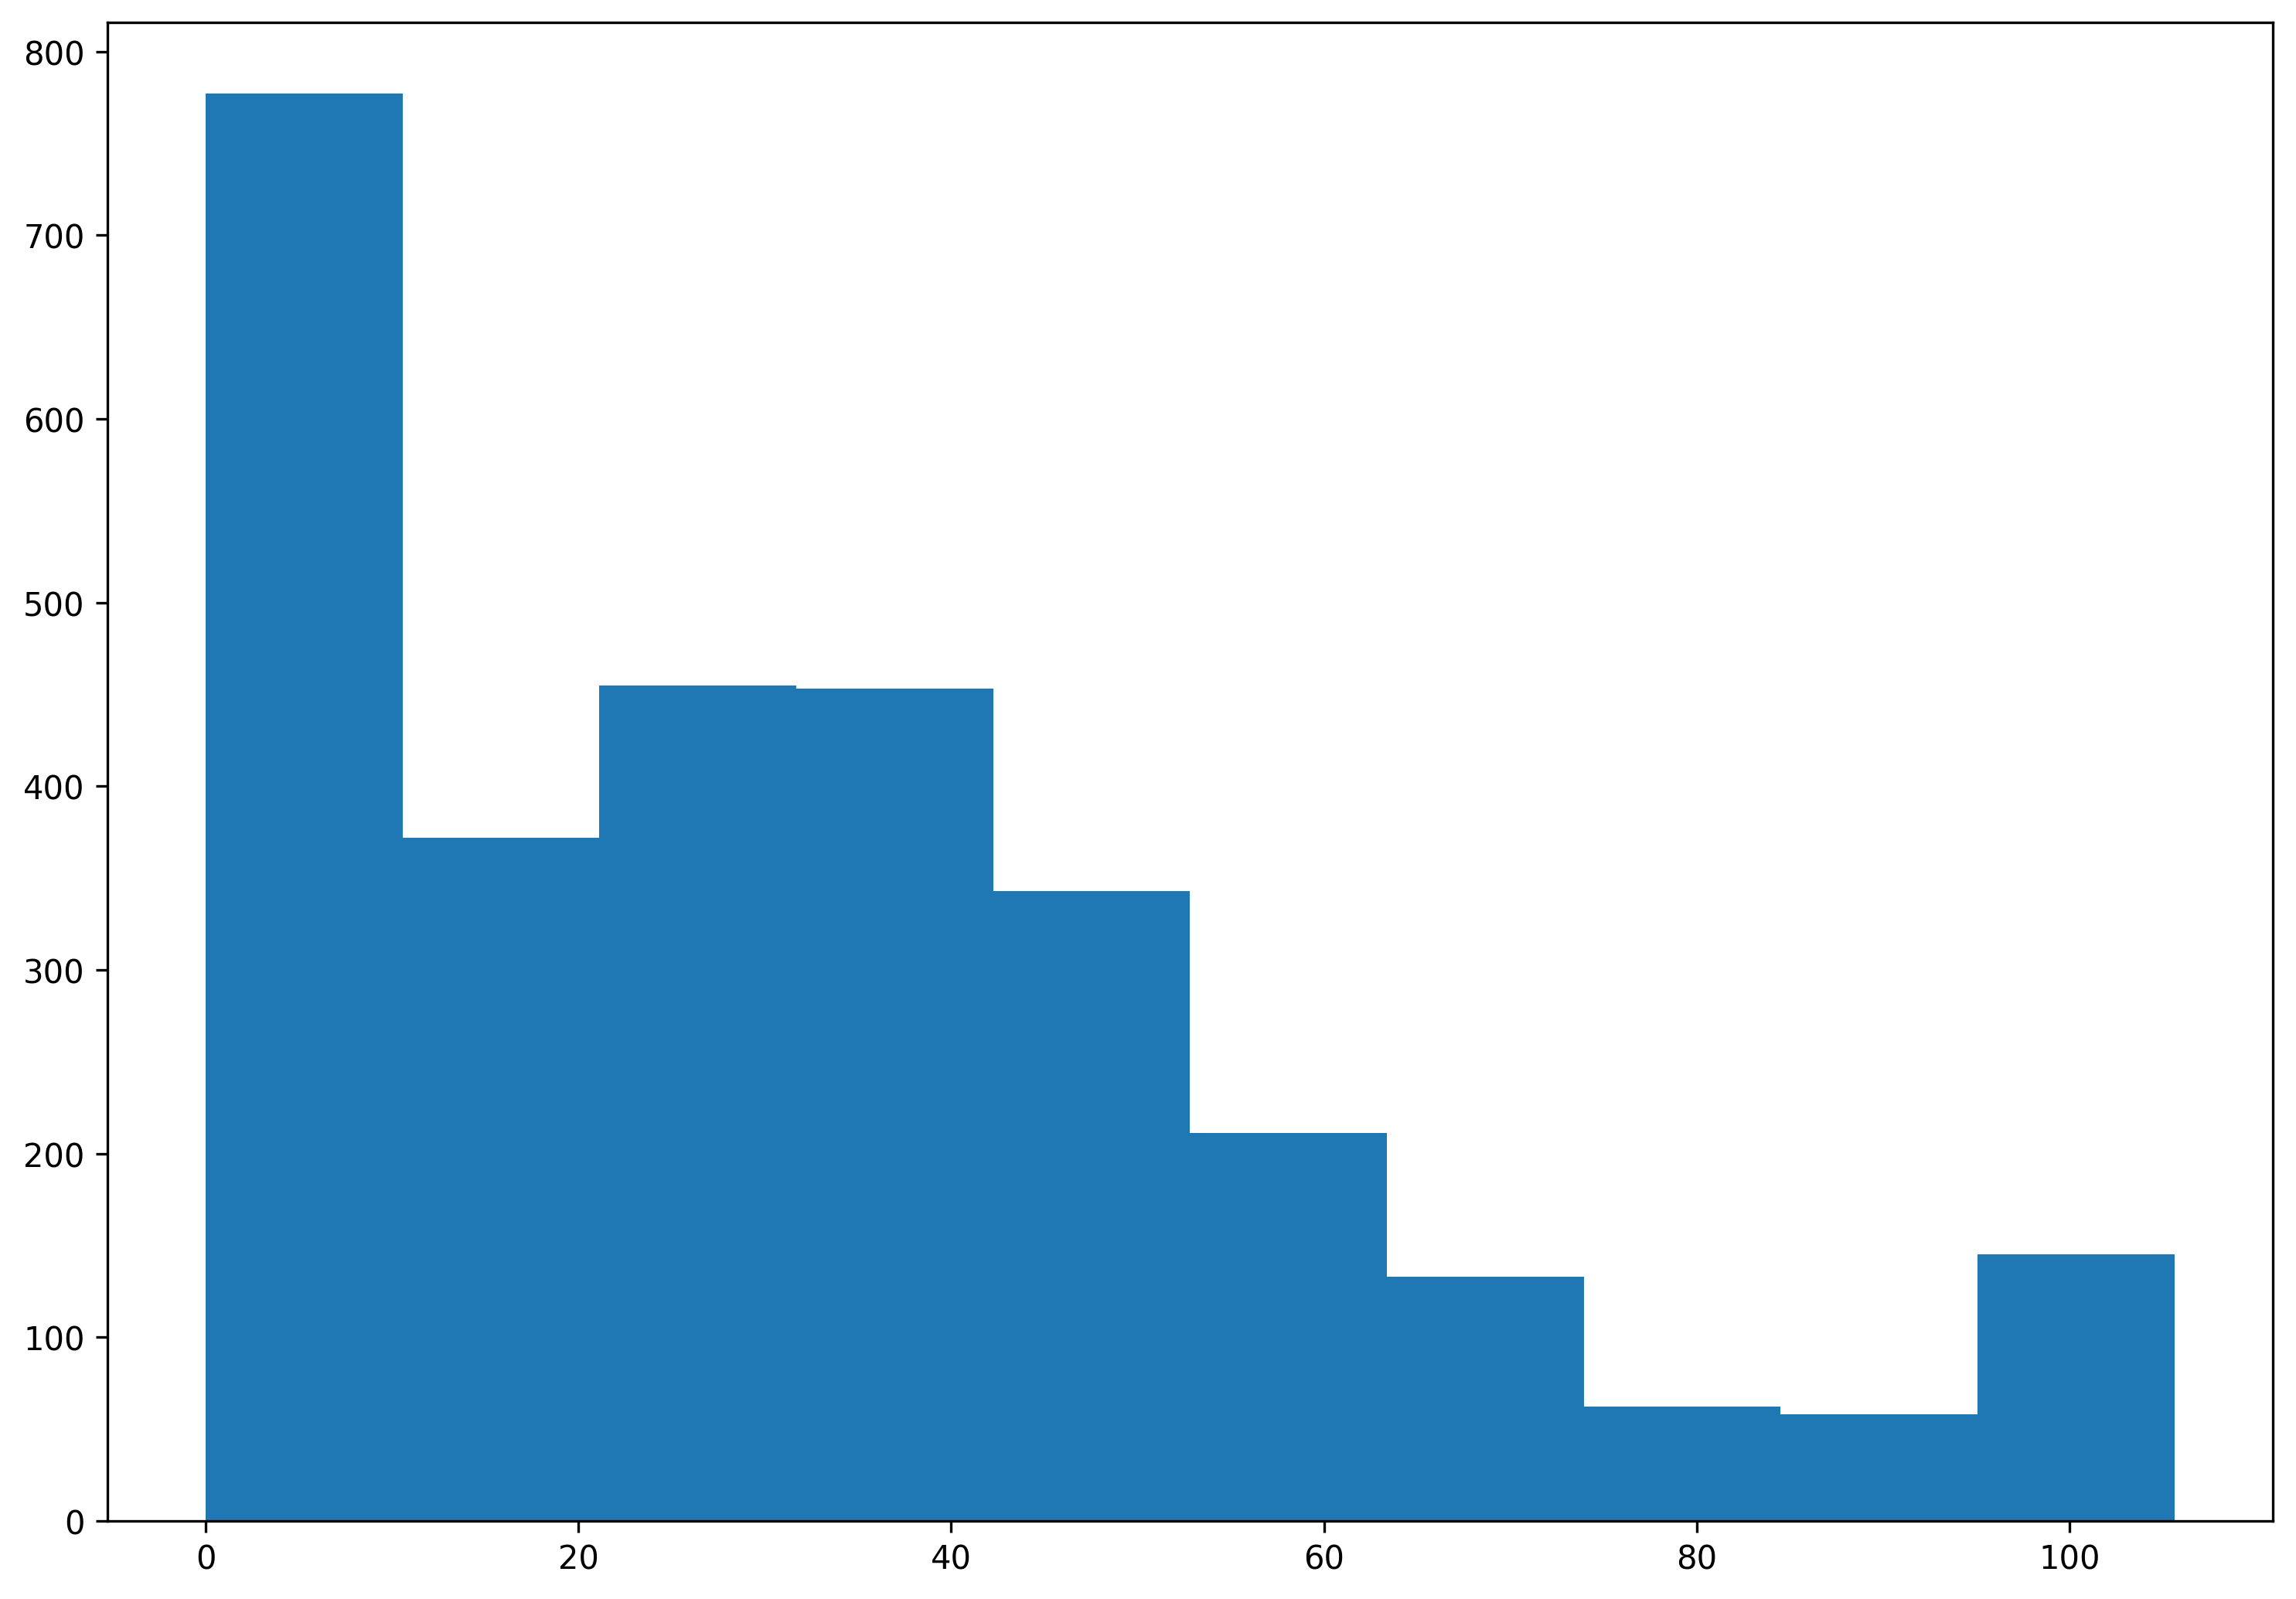

Text(0.5, 1.0, 'Whole data plot with and without threshold')

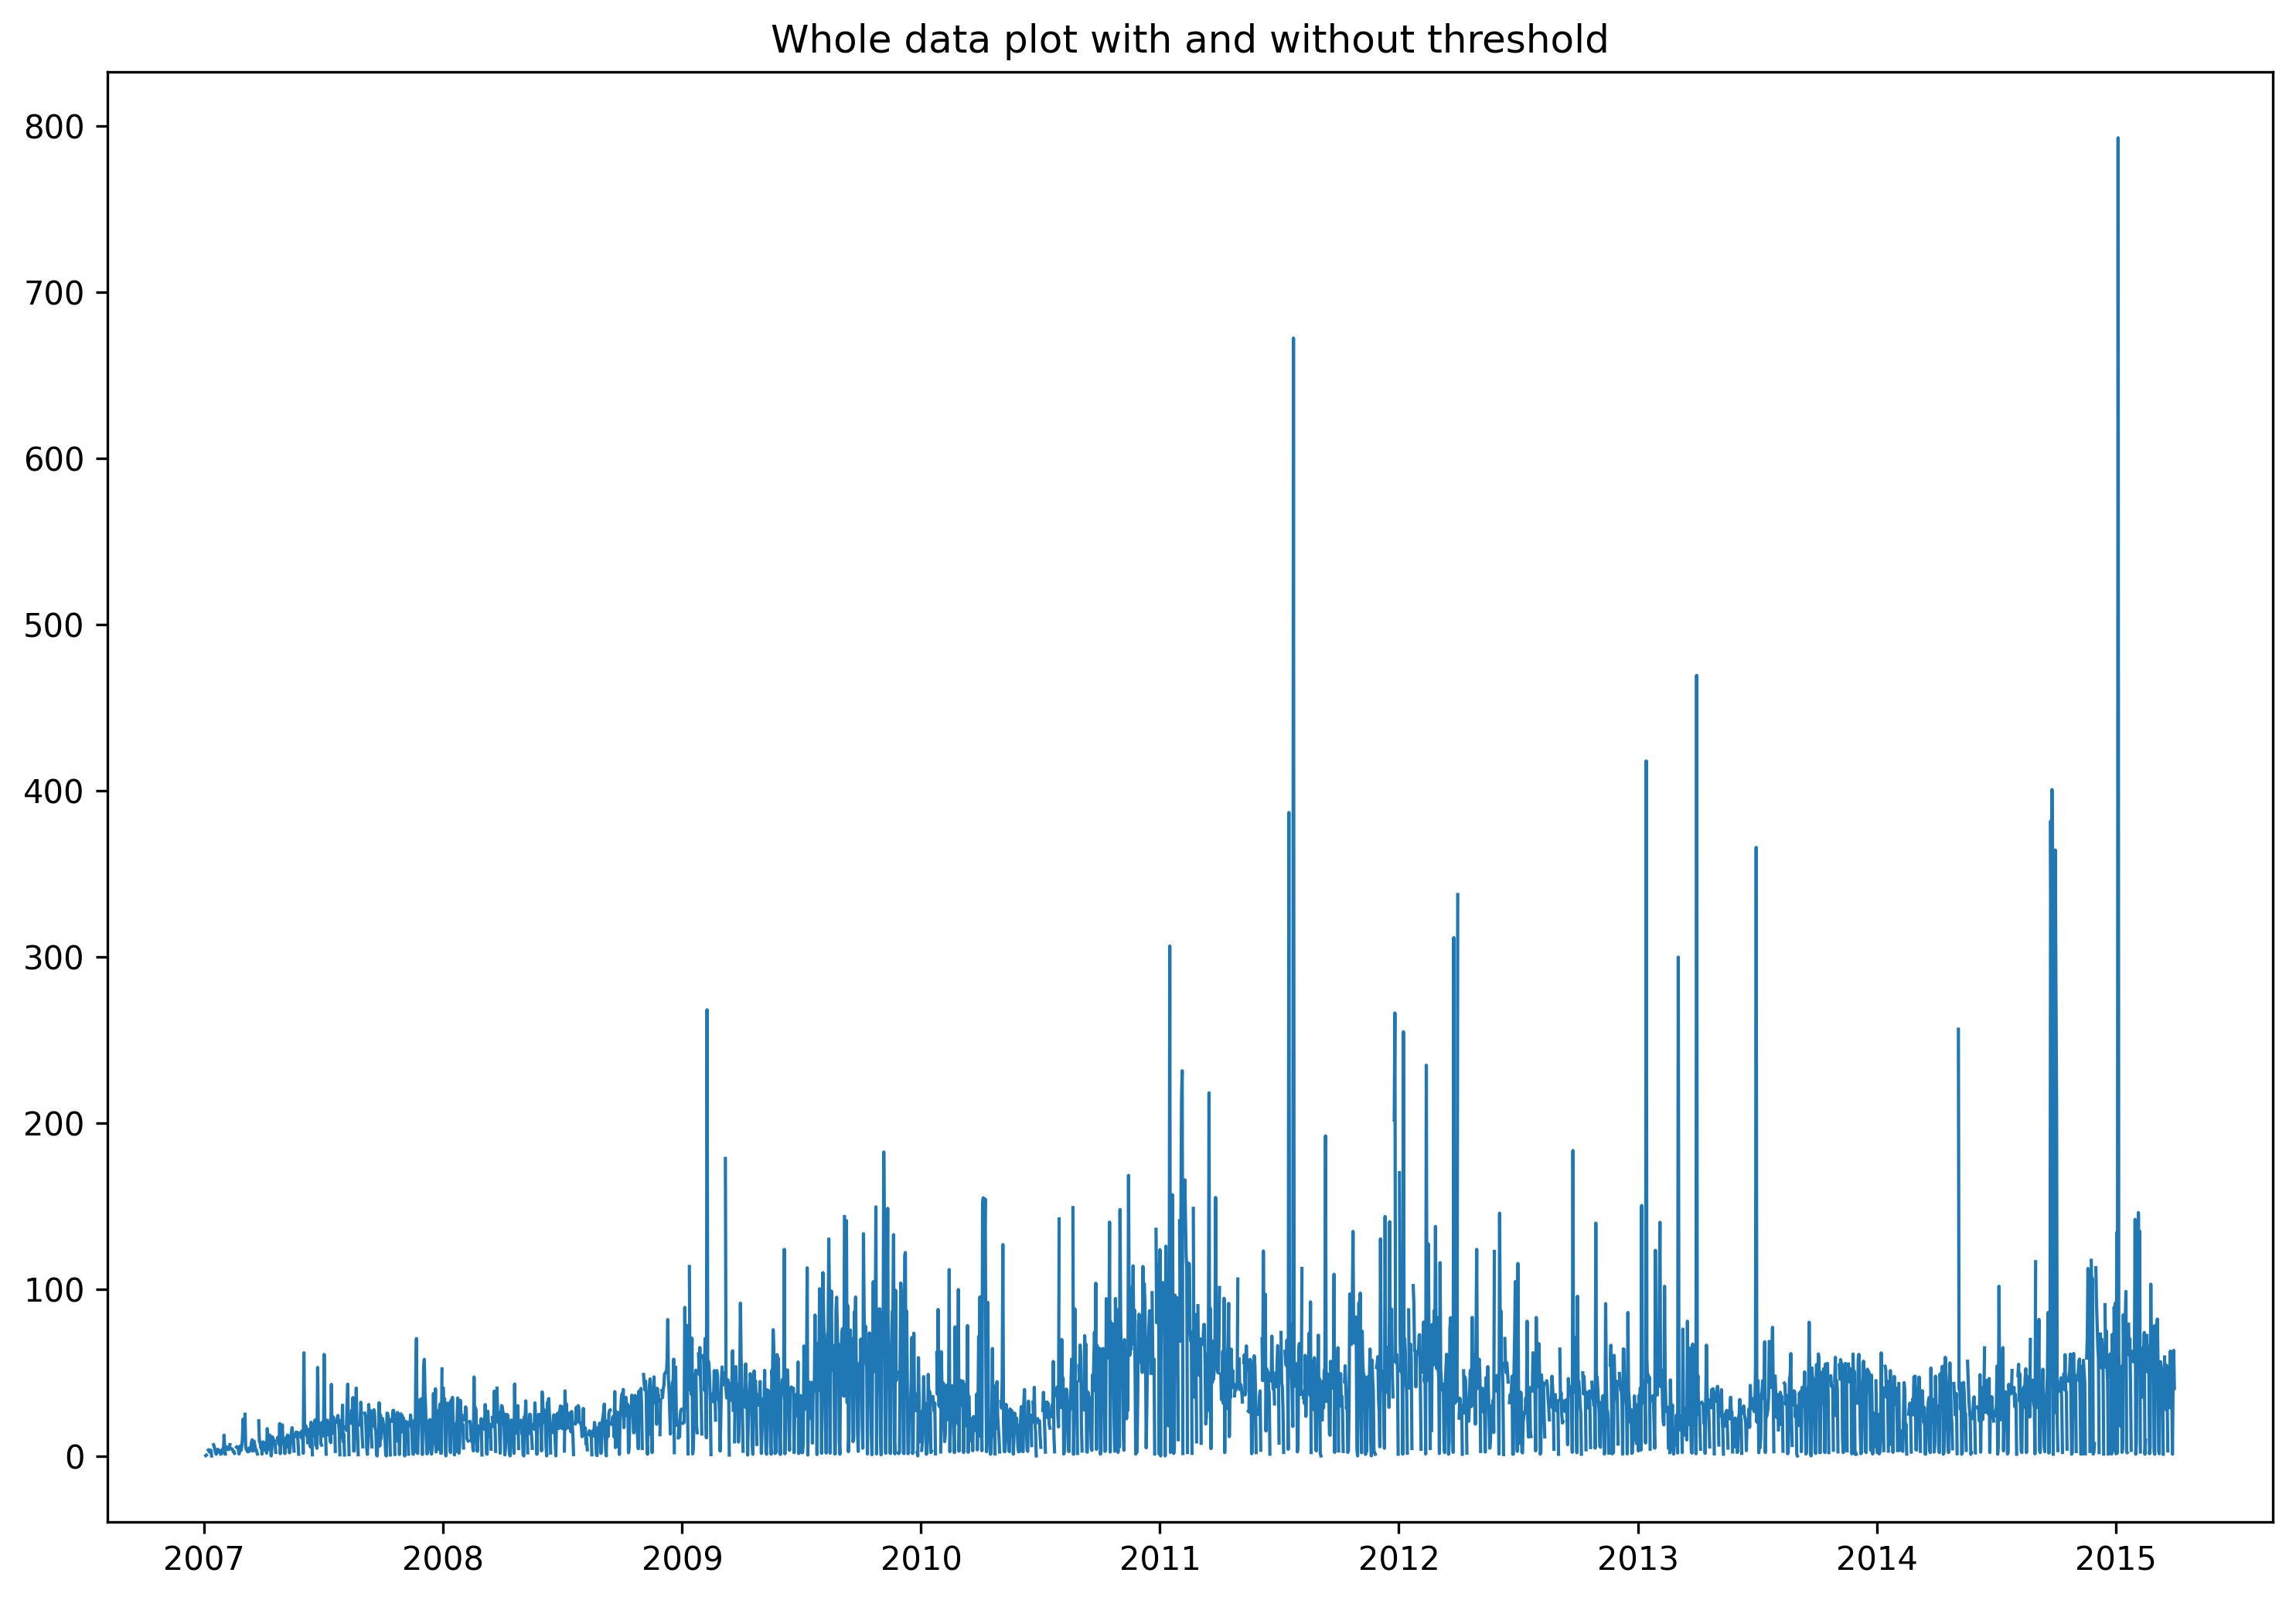

In [ ]:
plt.hist(ts)
plt.show()

plt.plot(ts_original, linewidth=1, label="Whole data plot") # Changed here to add label
plt.title("Whole data plot with and without threshold") # Changed here to set title for the figure

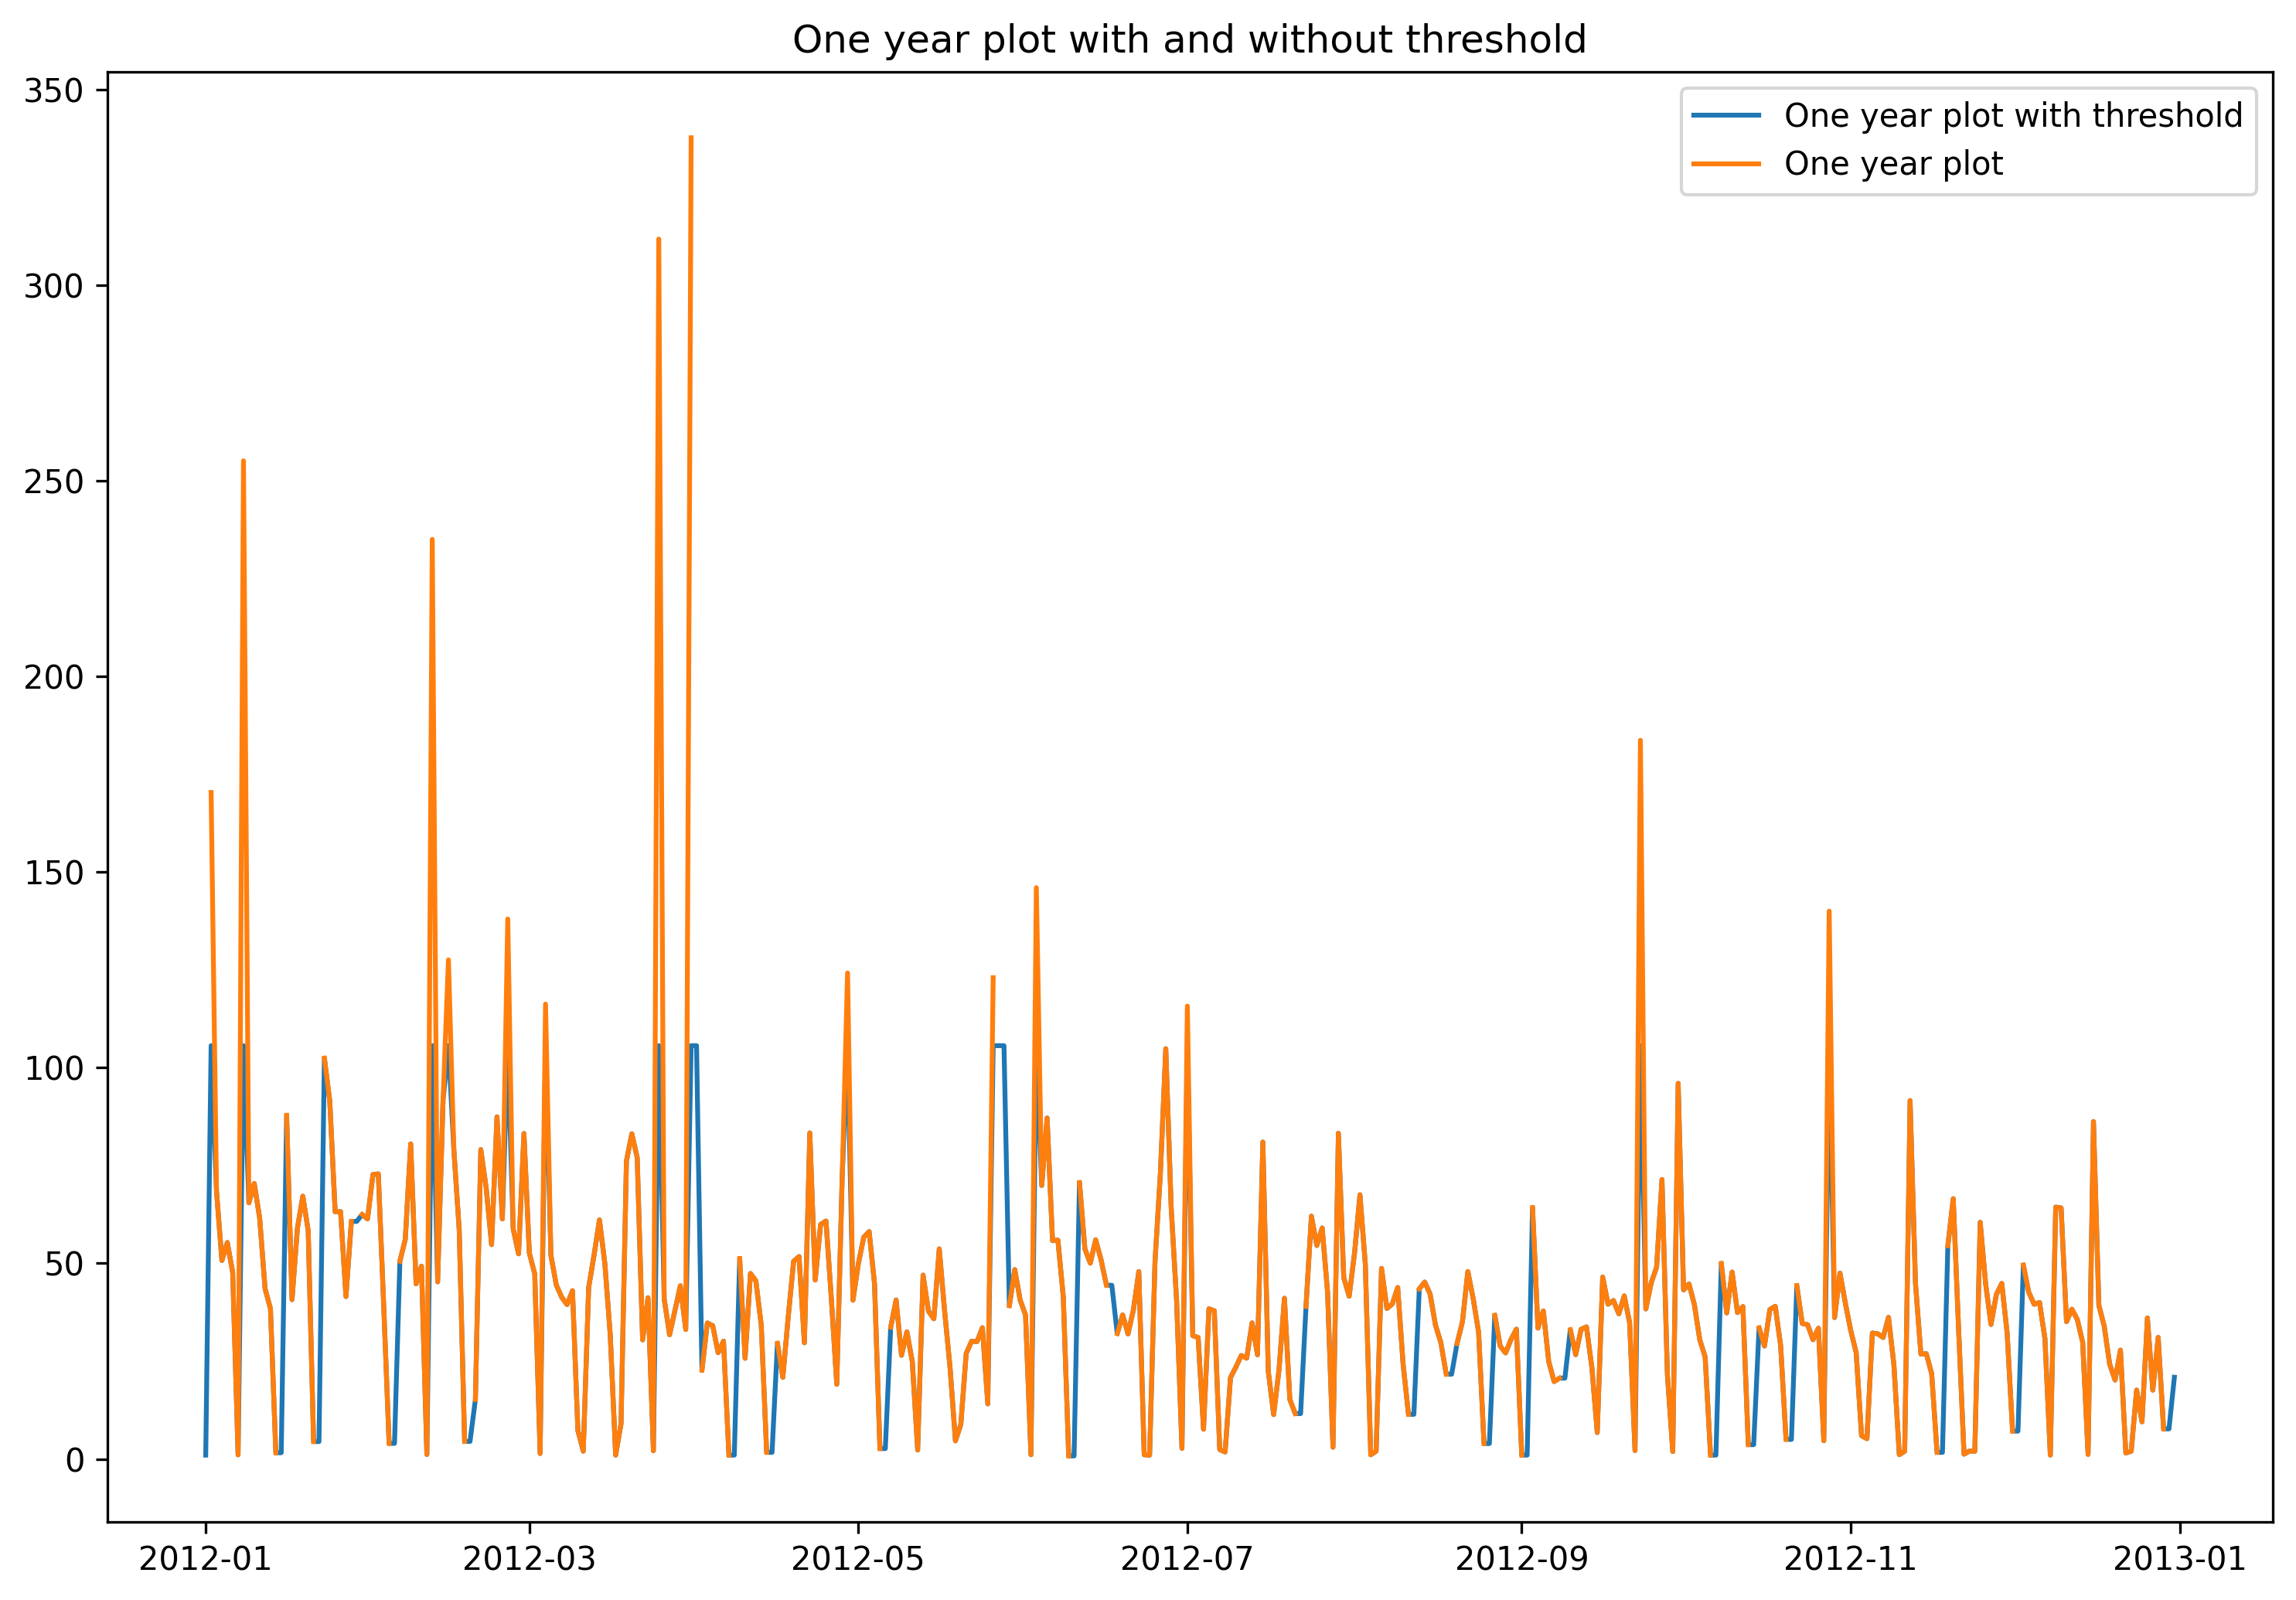

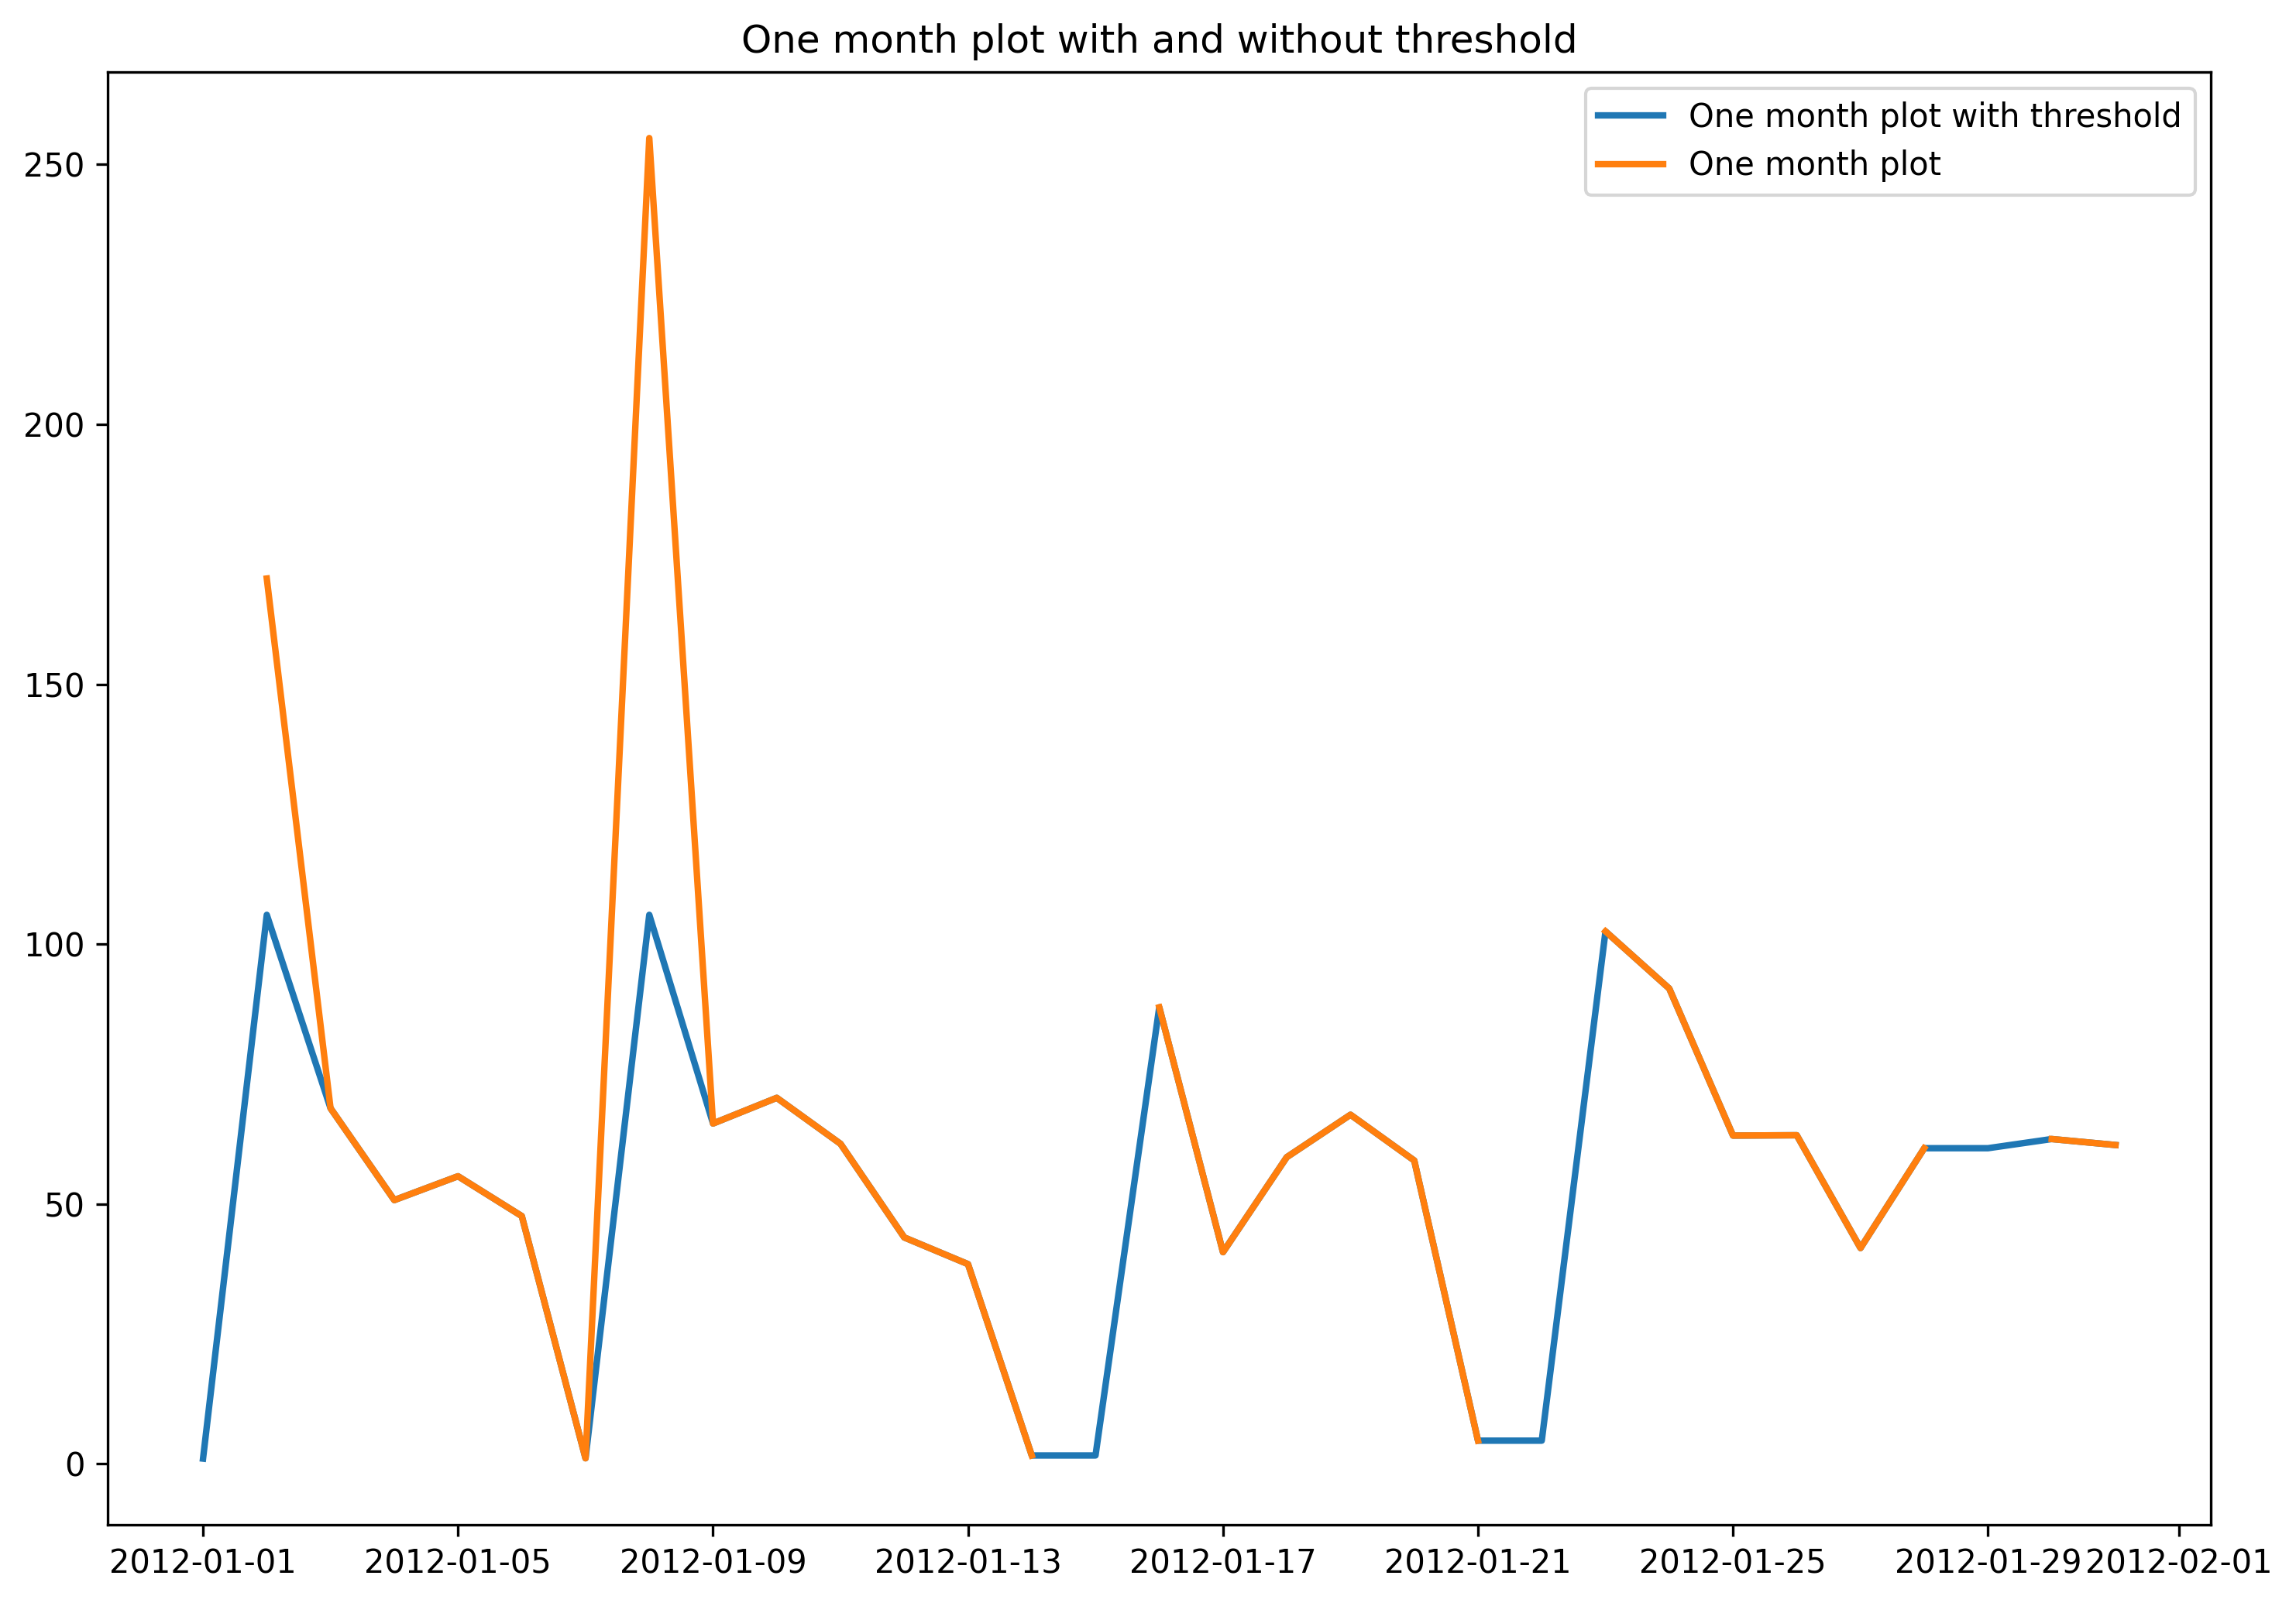

In [ ]:
# Seasonality
# Seasonality
plt.plot(ts["2012-01-01":"2012-12-31"], linewidth=1.5, label="One year plot with threshold")
plt.plot(ts_original["2012-01-01":"2012-12-31"], linewidth=1.5, label="One year plot")
plt.title("One year plot with and without threshold") # Setting title for the plot
plt.legend() # Show legend to distinguish lines
plt.show() # Display the first plot

plt.plot(ts["2012-01-01":"2012-01-31"], linewidth=2, label="One month plot with threshold")
plt.plot(ts_original["2012-01-01":"2012-01-31"], linewidth=2, label="One month plot")
plt.title("One month plot with and without threshold") # Setting title for the plot
plt.legend() # Show legend to distinguish lines
plt.show() # Display the second plot

Text(0.5, 1.0, 'One year plot of weekly medians')

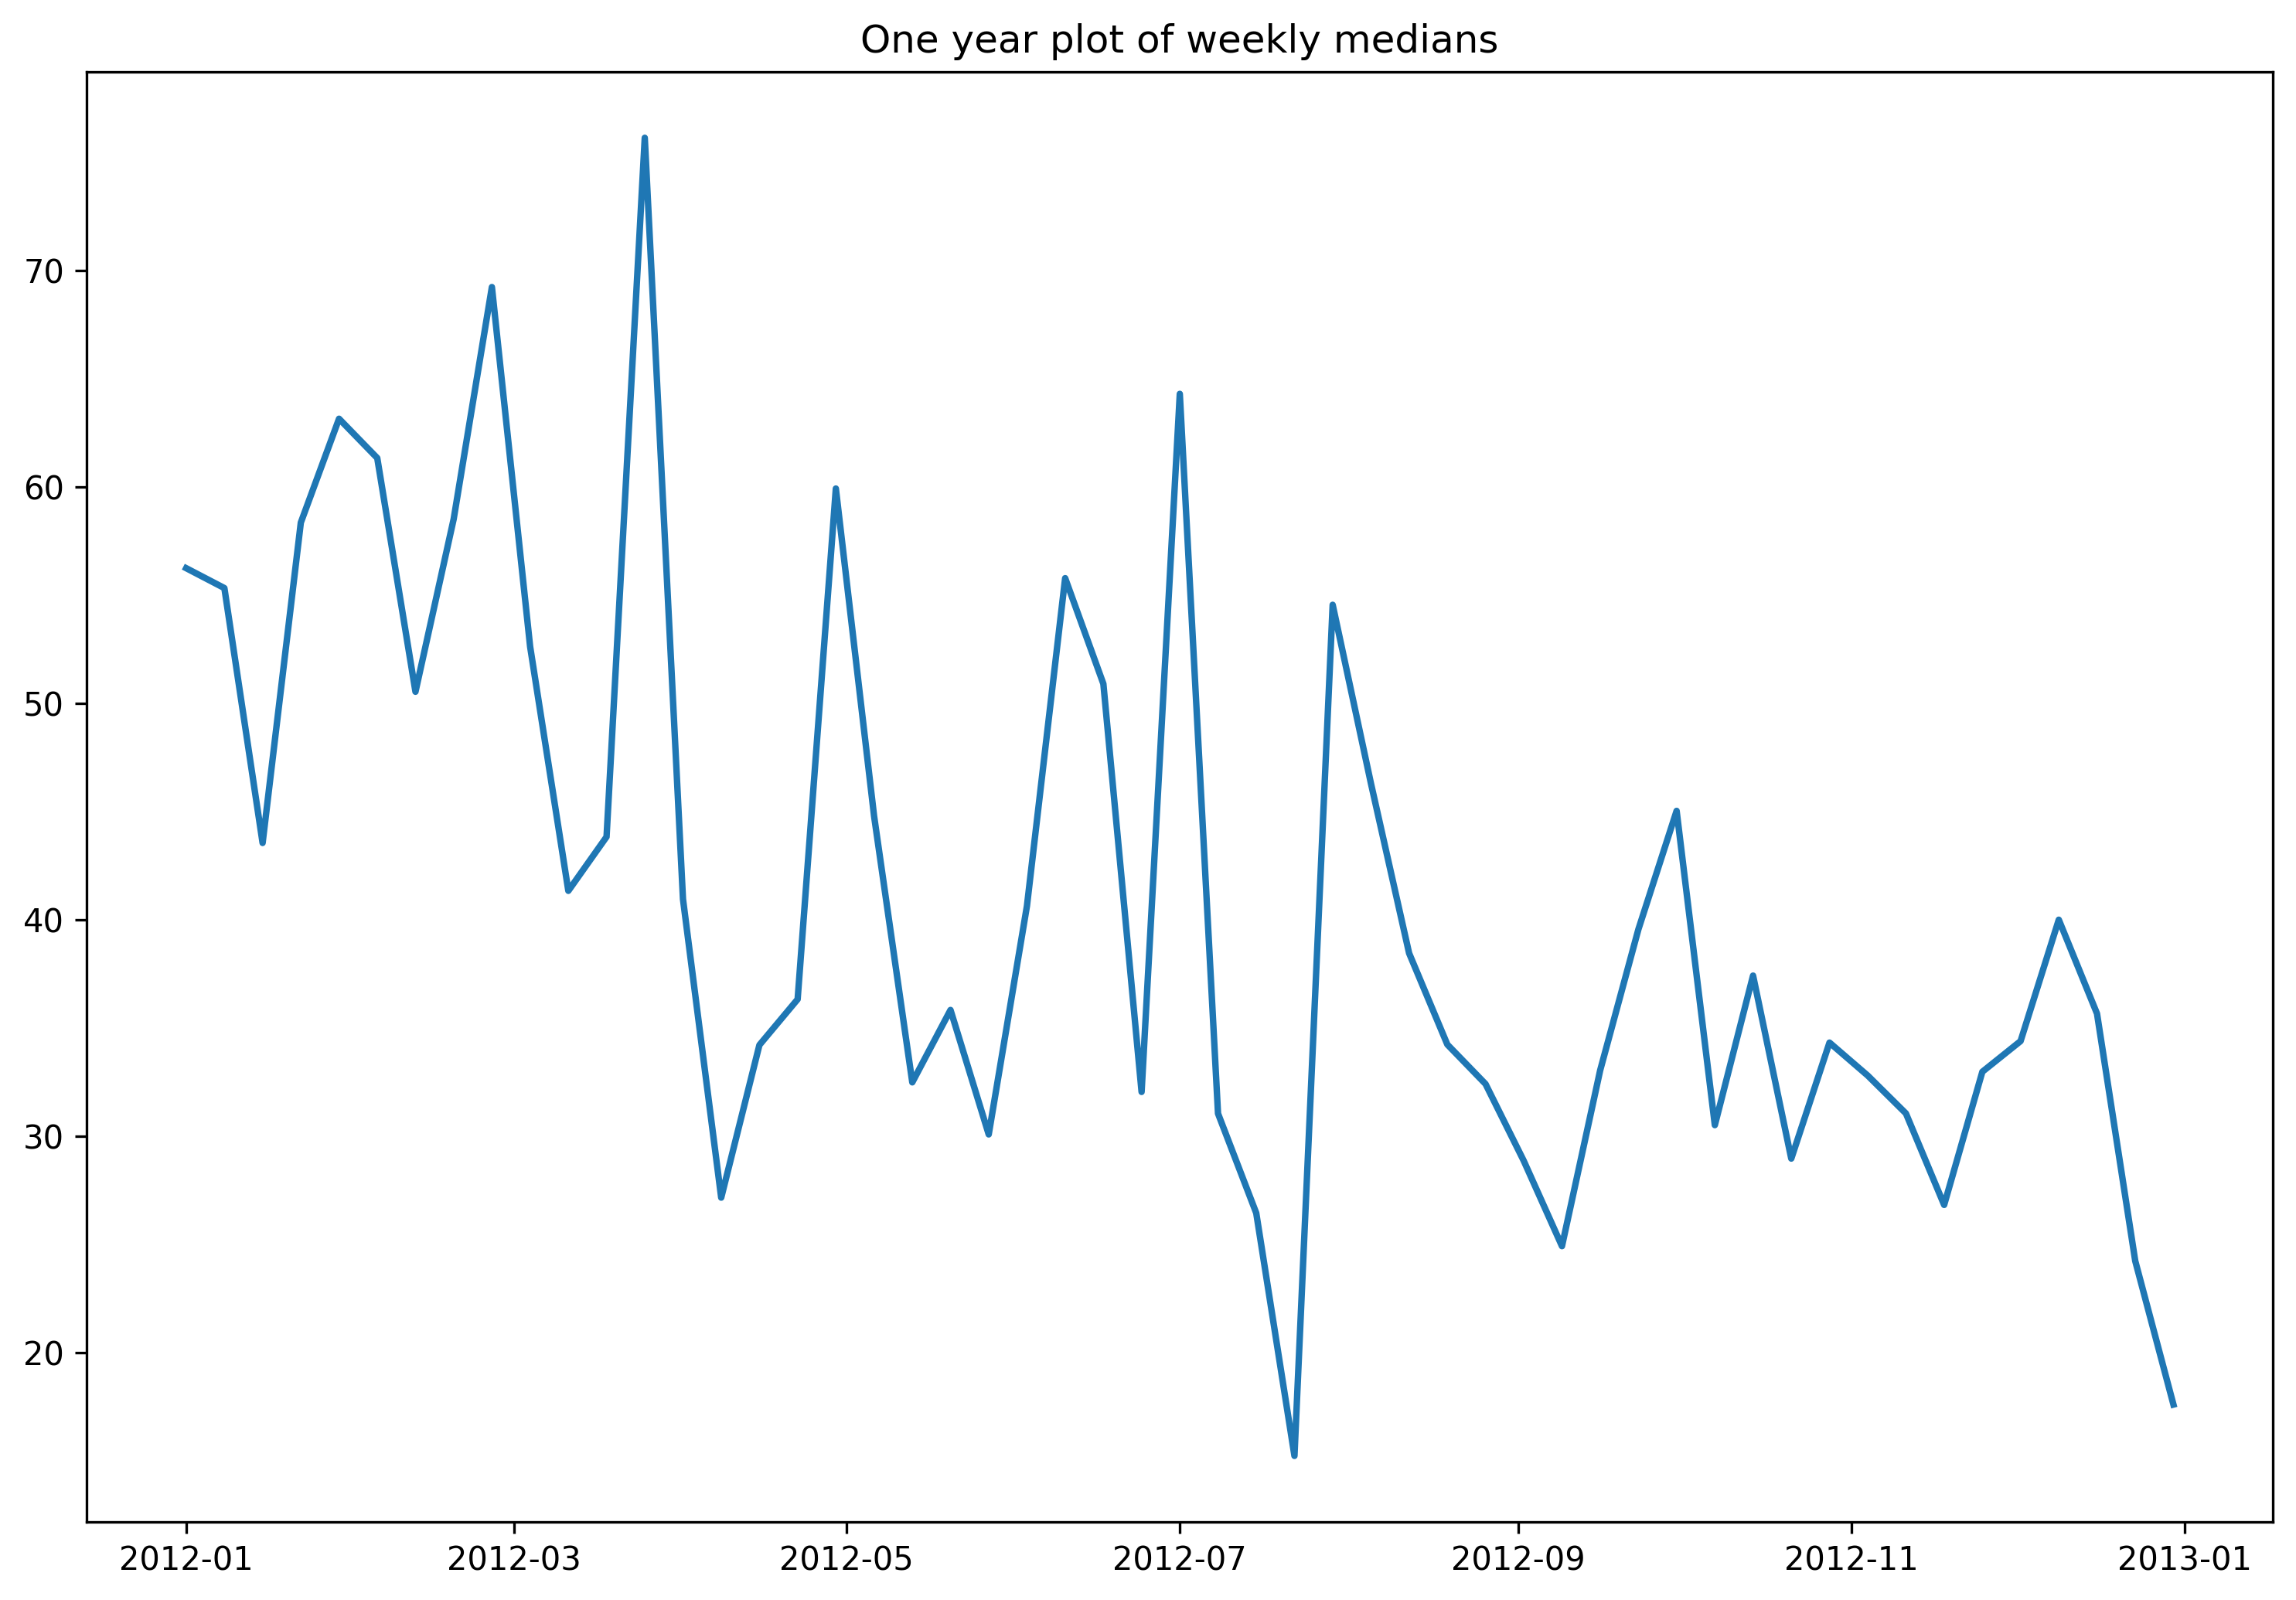

In [ ]:
# Aggregate the data by week using the median
ts_by_week_list = ts.resample('W').median()
ts_by_week = pd.Series(ts_by_week_list.values, index=ts_by_week_list.index)

# Aggregate the data by week using the median
ts_by_week_list = ts.resample('W').median()
ts_by_week = pd.Series(ts_by_week_list.values, index=ts_by_week_list.index)

# Changed here: 'title' is moved outside of plt.plot()
# plt.plot(ts_by_week, linewidth=1.5)
# plt.title("Whole data plot of weekly medians")

# Changed here: 'title' is moved outside of plt.plot()
plt.plot(ts_by_week["2012-01-01":"2012-12-31"], linewidth=2)
plt.title("One year plot of weekly medians")

In [ ]:
# Stationarity
result = adfuller(ts)
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -3.771724181110665
p-value: 0.0032102302503606442


<ipython-input-22-28b76c385ec6>:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  means = ts.resample('M').mean()
<ipython-input-22-28b76c385ec6>:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  stdevs = ts.resample('M').std()


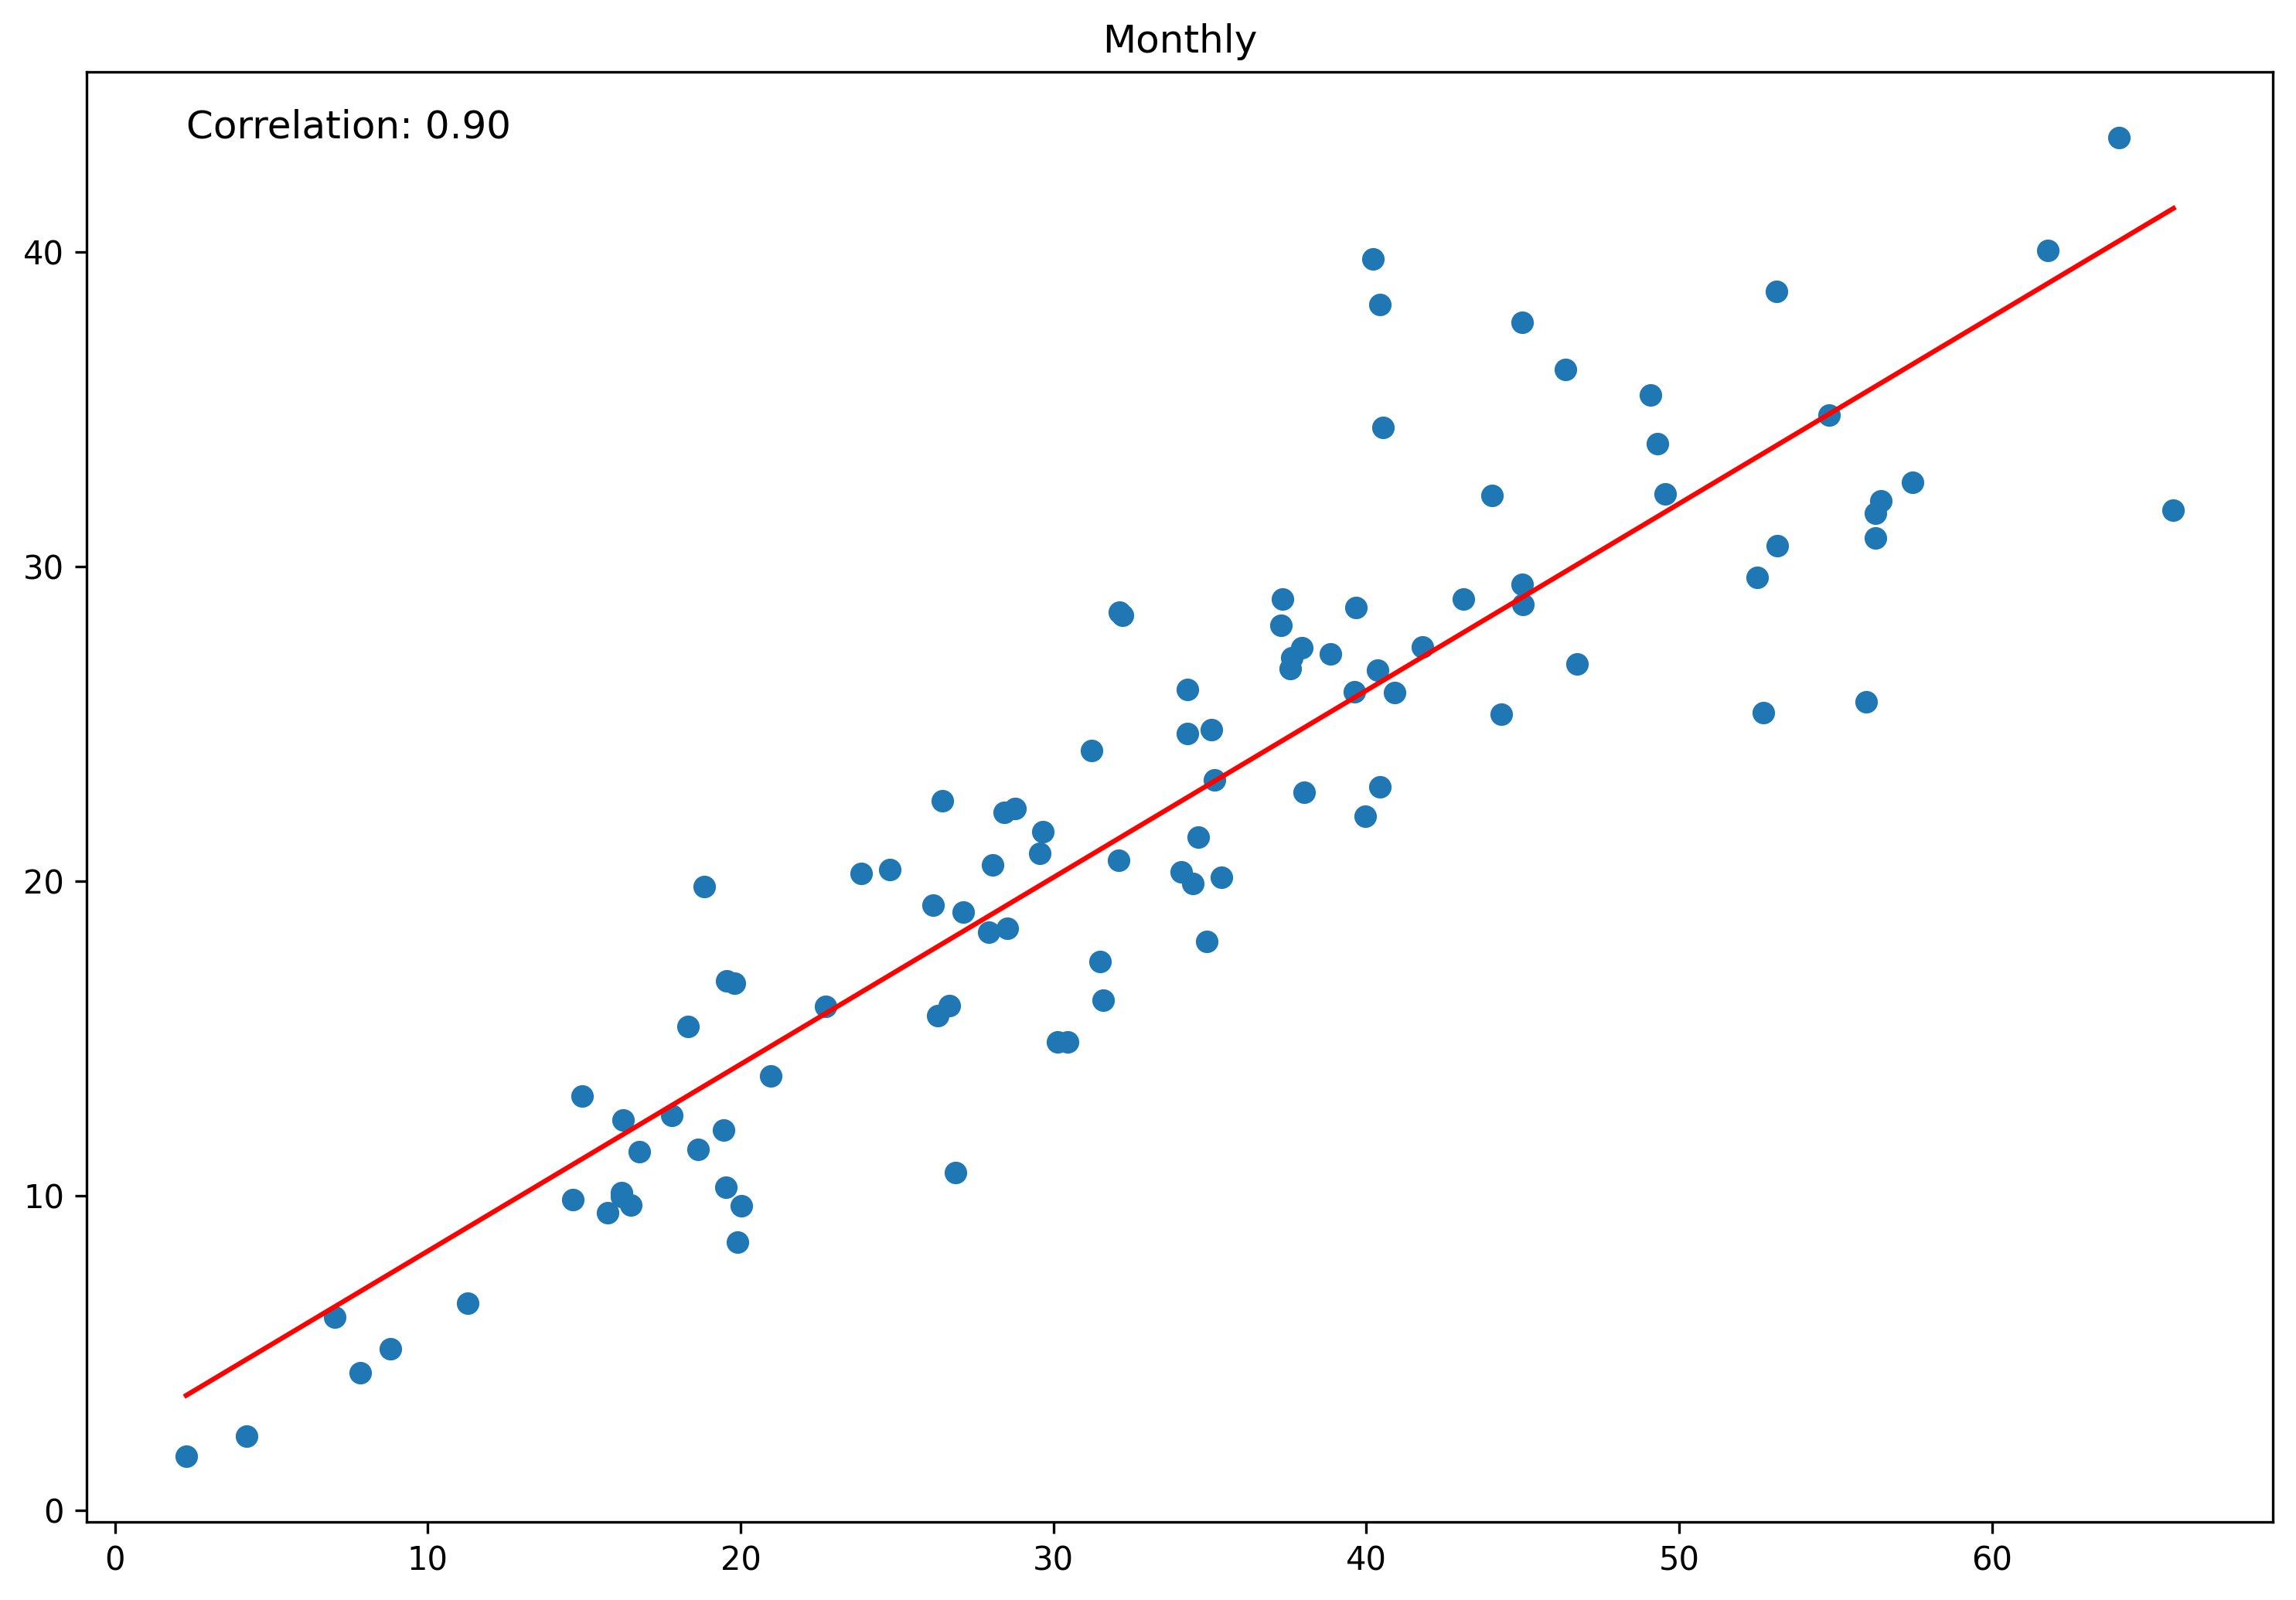

In [ ]:
# Mean-standard deviation graph
means = ts.resample('M').mean()
stdevs = ts.resample('M').std()

# Calculate the correlation coefficient
correlation = np.corrcoef(means, stdevs)[0, 1]

plt.scatter(means, stdevs)
plt.title("Monthly")

# Changed here: Calculate abline using OLS regression
data = pd.DataFrame({'x': means, 'y': stdevs})
model = ols("y ~ x", data=data).fit()
intercept, slope = model.params

# Generate y-values for the abline
x_range = np.array([means.min(), means.max()])  # Use min and max of means for x-range
y_range = intercept + slope * x_range

# Plot the abline
plt.plot(x_range, y_range, color='red')

# Add the correlation coefficient to the plot
plt.text(means.min(), stdevs.max(), f'Correlation: {correlation:.2f}', color='black', fontsize=12)

plt.show()

<ipython-input-23-dbf62f00d9d5>:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  means = bc_series.resample('M').mean()
<ipython-input-23-dbf62f00d9d5>:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  stdevs = bc_series.resample('M').std()


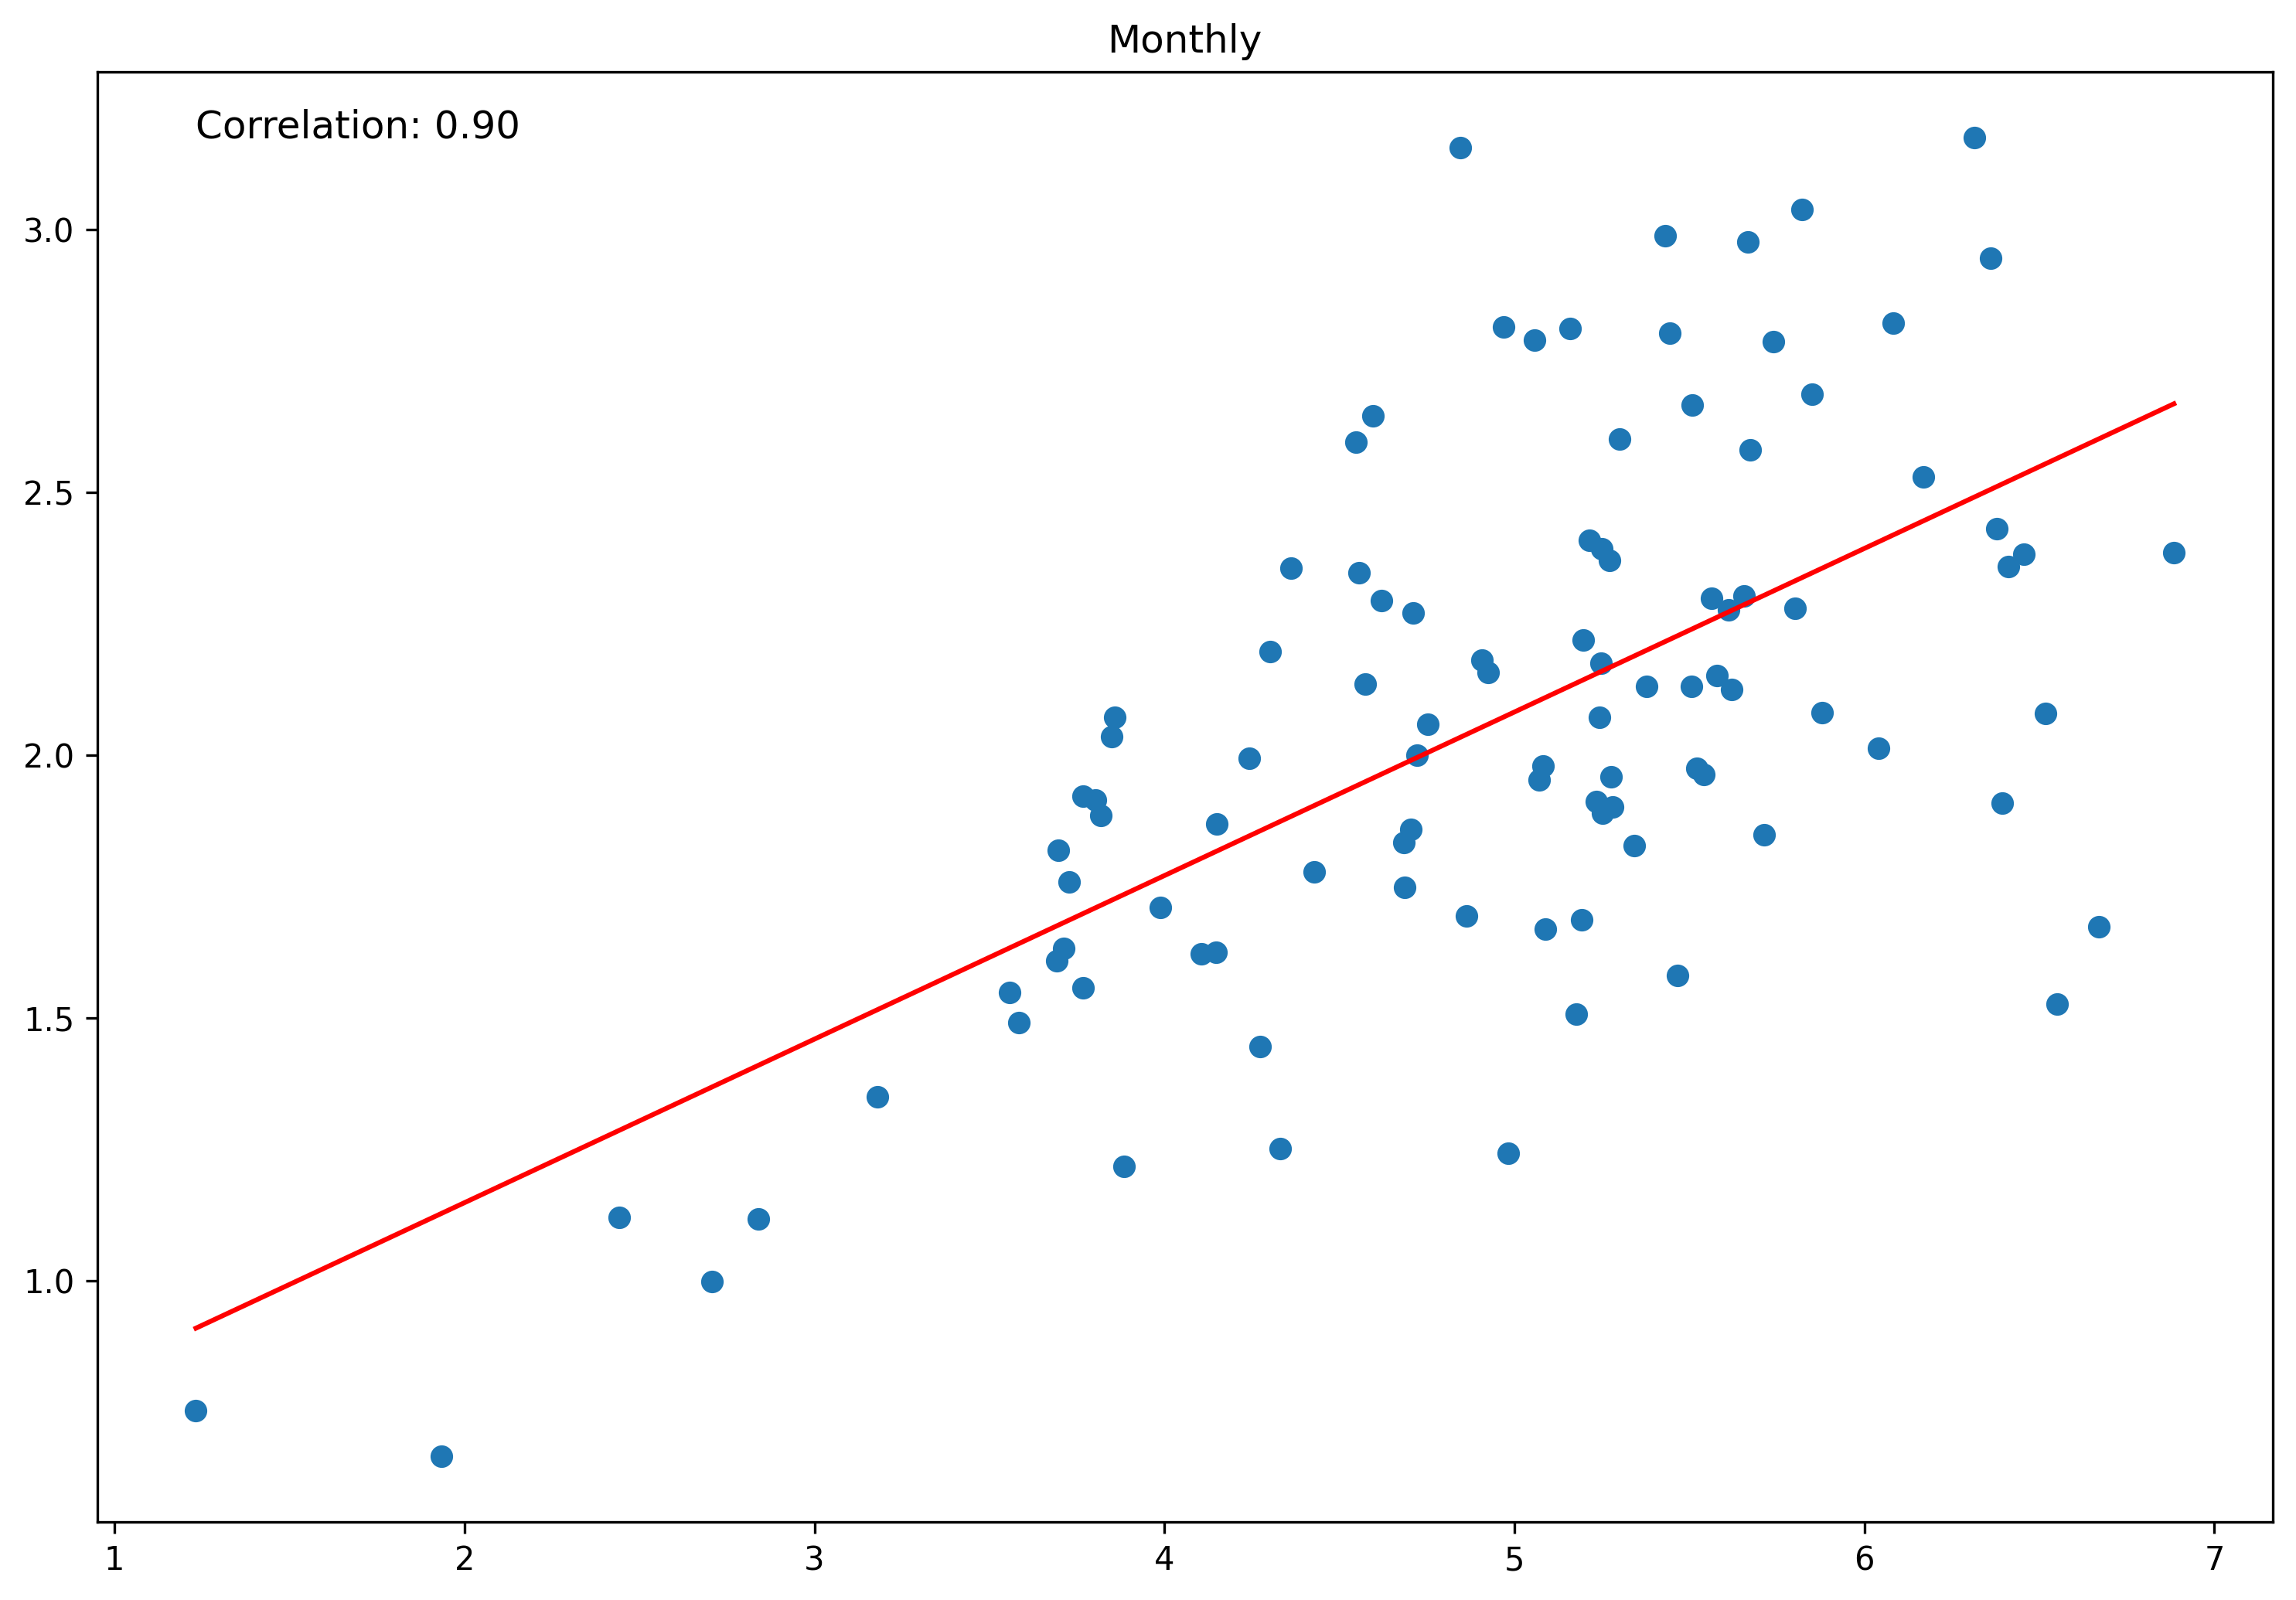

In [ ]:
bc_lambda = 0.25
# Adding 1 to avoid log(0) and preserving the DatetimeIndex
bc = boxcox(ts + 1, lmbda=bc_lambda)
# Convert the boxcox result back to a pandas Series with the original index
bc_series = pd.Series(bc, index=ts.index)

# Now you can resample using the DatetimeIndex
means = bc_series.resample('M').mean()
stdevs = bc_series.resample('M').std()

plt.scatter(means, stdevs) # Remove title argument from scatter function
plt.title("Monthly") # Set the title using plt.title()

data = pd.DataFrame({'x': means, 'y': stdevs})
model = ols("y ~ x", data=data).fit()
intercept, slope = model.params
# Generate y-values for the abline
x_range = np.array([means.min(), means.max()])  # Use min and max of means for x-range
y_range = intercept + slope * x_range

# Plot the abline
plt.plot(x_range, y_range, color='red')

# Add the correlation coefficient to the plot
plt.text(means.min(), stdevs.max(), f'Correlation: {correlation:.2f}', color='black', fontsize=12)

plt.show()

TypeError: slice indices must be integers or None or have an __index__ method

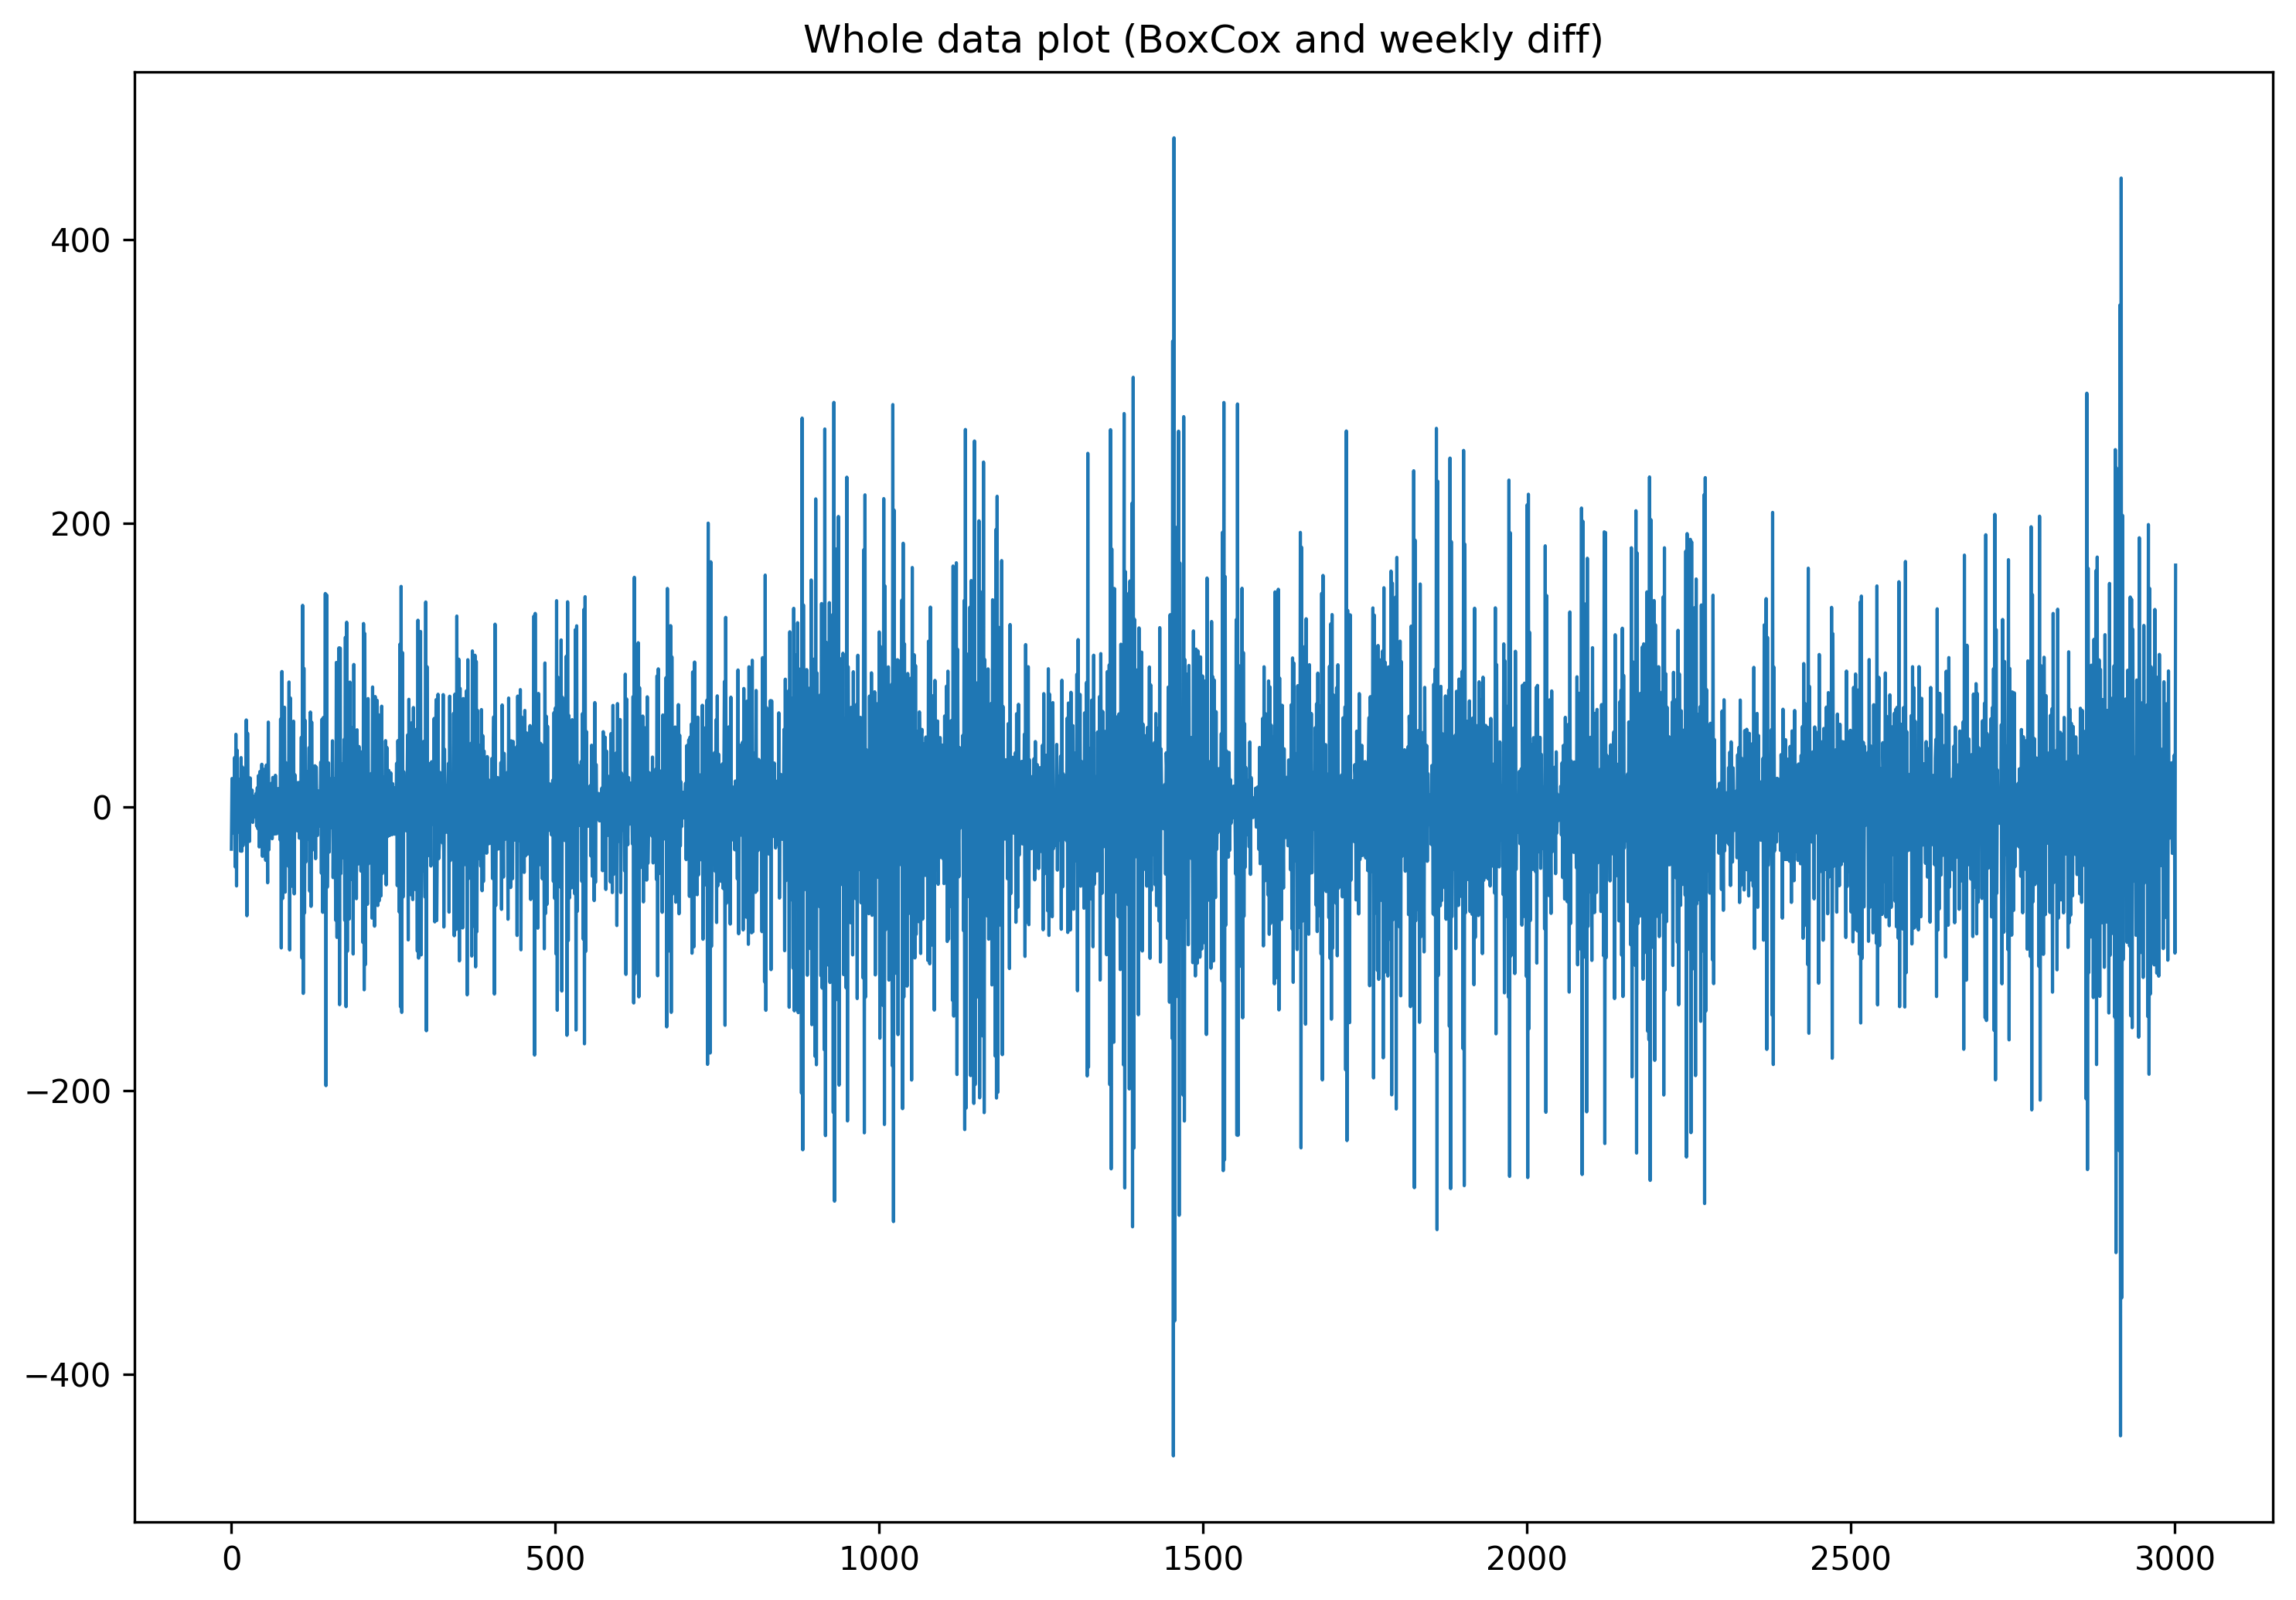

In [ ]:
# ARIMA model identification
bc_w = np.diff(bc, n=7)

plt.plot(bc_w, linewidth=1)
plt.title("Whole data plot (BoxCox and weekly diff)")  # Set title using plt.title()

plt.plot(bc_w["2012-01-01":"2012-12-31"], linewidth=1.5)
plt.title("One year plot (BoxCox and weekly diff)")  # Set title using plt.title()

plt.plot(bc_w["2012-01-01":"2012-01-31"], linewidth=2)
plt.title("One month plot (BoxCox and weekly diff)")  # Set title using plt.title()

### ISMAIL

In [ ]:
def acf_pacf(y, lags):
    """
    Plot of acf e pacf, 0-lag not included
    """
    fig, ax = plt.subplots(1, 2, figsize=(20,8))
    plot_acf(y, lags=lags, ax=ax[0], zero=False, auto_ylims=True, alpha=.05)
    plot_pacf(y, lags=lags, ax=ax[1], zero=False, auto_ylims=True, alpha=.05)
    plt.show()

In [ ]:
# Compute variance of original data
# Exclude the 'date' column and any other non-numeric columns
variance_original = df_train.select_dtypes(include=np.number).var()
print("Variance of original data:", variance_original)

# Apply log transformation
df_train['log_ave_days'] = df_train.apply(lambda x: 0 if x['ave_days'] == 0 else np.log(x['ave_days']), axis=1)

# Compute variance of transformed data
variance_transformed = df_train['log_ave_days'].var()
print("Variance of log-transformed data:", variance_transformed)

Variance of original data: ave_days             1544.793578
ave_days_original    1525.107782
dtype: float64
Variance of log-transformed data: 3.748371578653626


In [ ]:
# Compute variance of original data
variance_original = df_test.select_dtypes(include=np.number).var()
print("Variance of original data:", variance_original)

# Apply log transformation
df_test['log_ave_days'] = df_test['ave_days'].apply(lambda x: 0 if x == 0 else np.log(x))

# Compute variance of transformed data
variance_transformed = df_test['log_ave_days'].var()
print("Variance of log-transformed data:", variance_transformed)

Variance of original data: ave_days             2715.075037
ave_days_original    2835.331230
dtype: float64
Variance of log-transformed data: 2.785795047542921


In [ ]:
logtrain_arima =df_train['log_ave_days']
logtest_arima = df_test['log_ave_days']

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


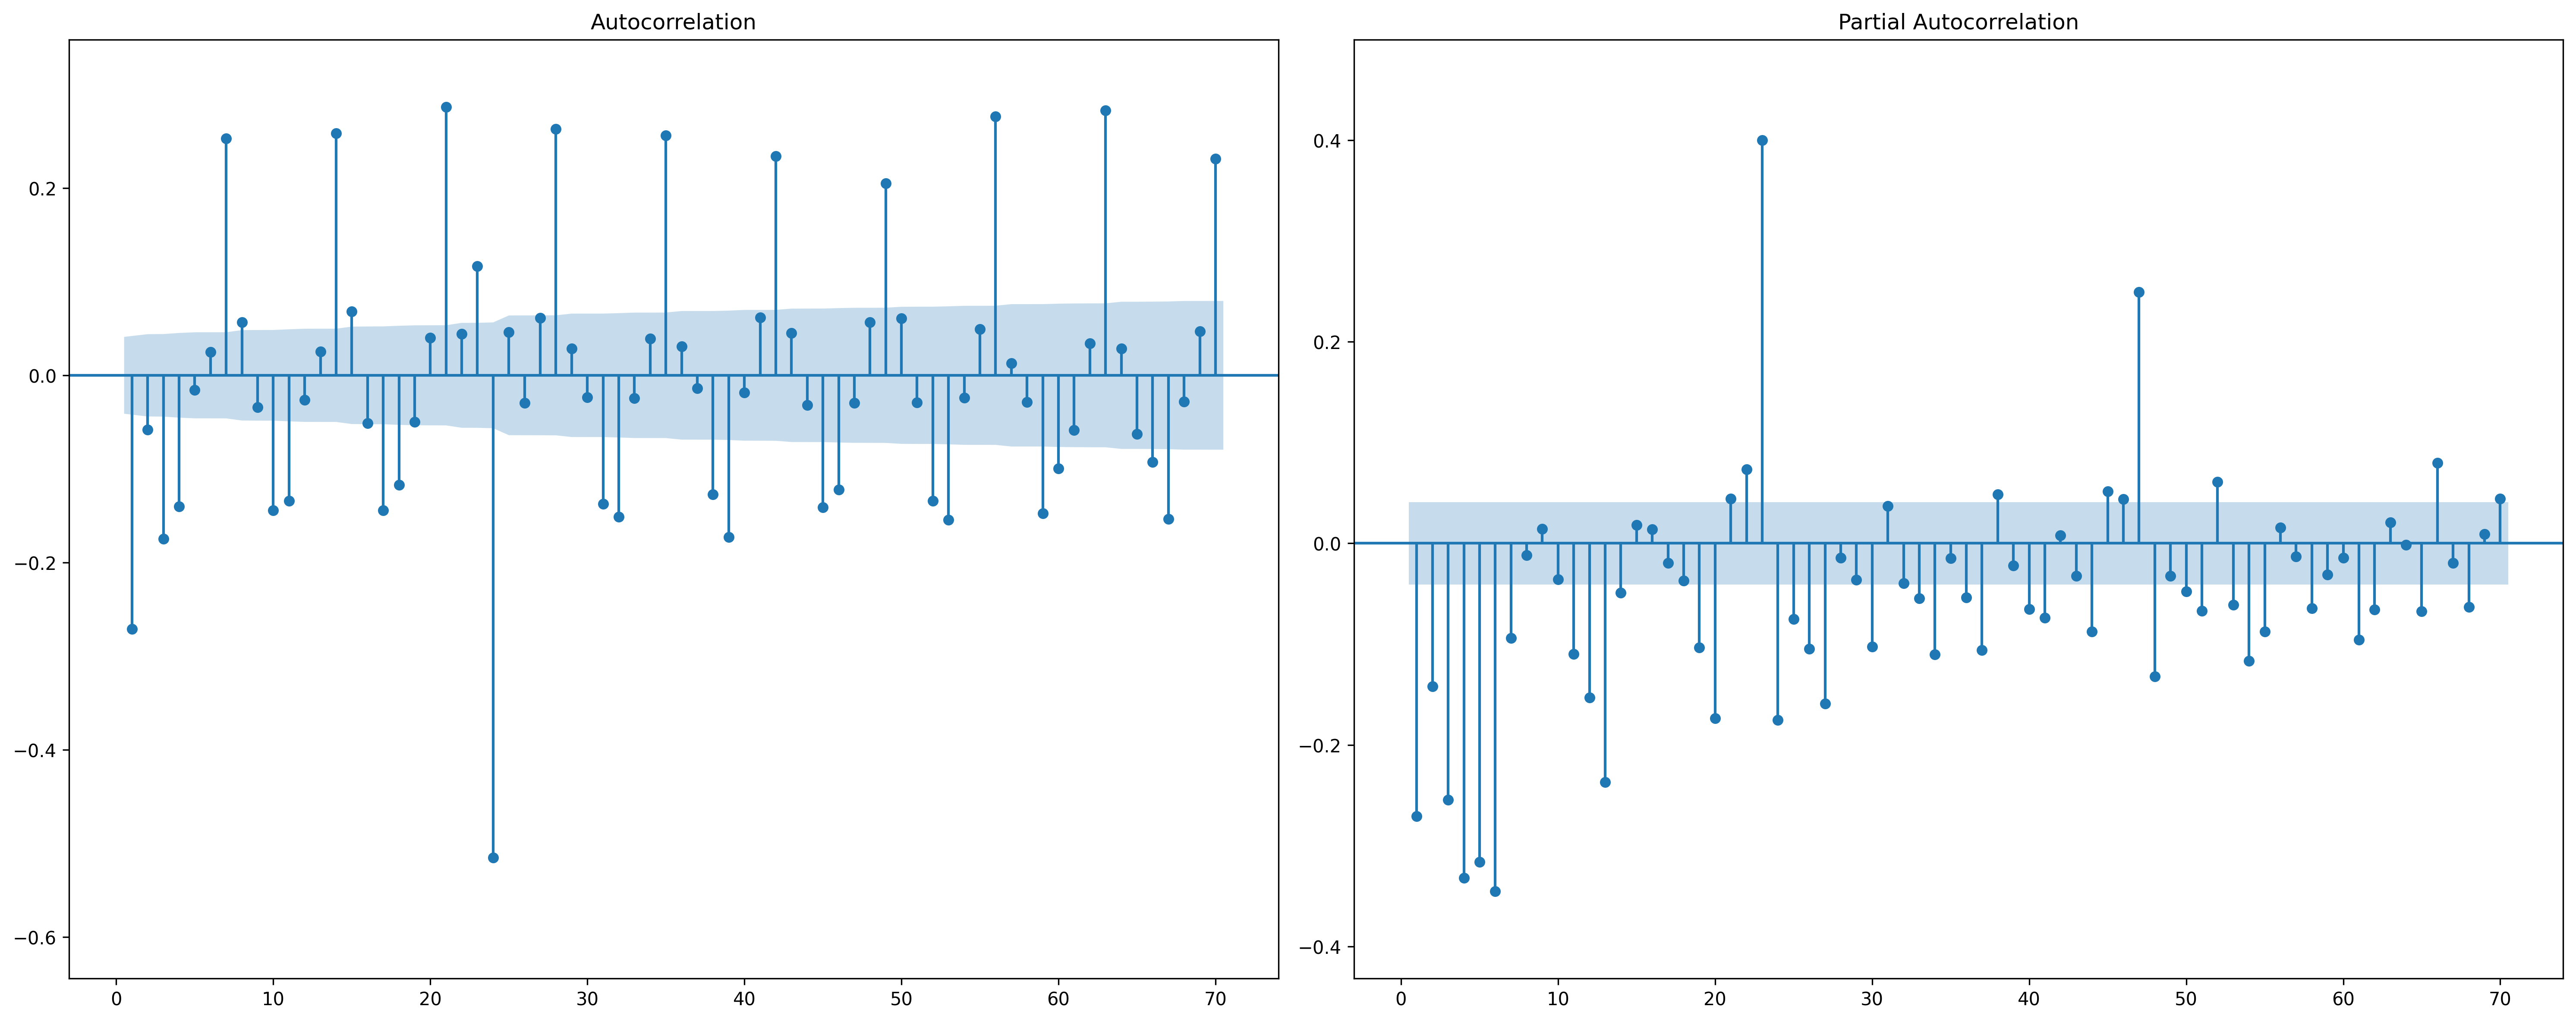

In [ ]:
# Model Fit
mod1 = ARIMA(logtrain_arima,
             order=(0, 1, 0),
             seasonal_order=(0, 1, 0, 24))
mod1 = mod1.fit()

# acf pacf
acf_pacf(mod1.resid, 70)


In [ ]:
aic1 = mod1.aic
prediction01= mod1.get_prediction(start=logtest_arima.index[0], end=logtest_arima.index[-1]).predicted_mean
prediction01 = pd.Series(prediction01, index=logtest_arima.index)
# Instead of:
# mae = mae(logtest_arima,prediction01)

# Use a different variable name, like 'mae_value' or 'current_mae':
mae_value = error_func(logtest_arima,prediction01)  # Assuming 'error_func' is still mae from sklearn.metrics

# Then print using the new variable name:
print('MAE: ', int(mae_value))#mape=calculate_mape(logtest_arima.avg_,prediction01)
print('AIC: ', int(aic1))


MAE:  45
AIC:  11722


### MIO

In [ ]:
# ARIMA model fitting
mod_arima_1 = ARIMA(ts.iloc[train_start_idx:train_end_idx], order=(0, 1, 2))
mod_arima_1_fit = mod_arima_1.fit()
print(mod_arima_1_fit.summary())

mod_arima_1_pre = mod_arima_1_fit.forecast(steps=pred_window)

# Adjust the periods to match the length of the test set
mod_arima_1_pre_values = pd.Series(mod_arima_1_pre, index=pd.date_range(start=test_start, periods=len(ts.iloc[test_start_idx:test_end_idx])))

mod_arima_1_pre_err = error_func(ts.iloc[test_start_idx:test_end_idx], mod_arima_1_pre_values)
print(mod_arima_1_pre_err)

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2643
Model:                 ARIMA(0, 1, 2)   Log Likelihood              -12013.920
Date:                Tue, 07 Jan 2025   AIC                          24033.841
Time:                        10:29:21   BIC                          24051.479
Sample:                    01-04-2007   HQIC                         24040.226
                         - 03-30-2014                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7290      0.015    -48.739      0.000      -0.758      -0.700
ma.L2         -0.2254      0.015    -15.277      0.000      -0.254      -0.196
sigma2       521.0399     11.415     45.645      0.0

In [ ]:
# In cell ipython-input-90-ac40dadefb6e:

# Instead of:
# mae_value = error_func(ts.iloc[train_start_idx:train_end_idx],mod_arima_1_pre_values)

# Use the test set for comparison:
mae_value = error_func(ts.iloc[test_start_idx:test_end_idx], mod_arima_1_pre_values)
# 'ts.iloc[test_start_idx:test_end_idx]' should have the same length as 'mod_arima_1_pre_values' (220)

# Then print using the new variable name:
print('MAE: ', int(mae_value))

MAE:  20


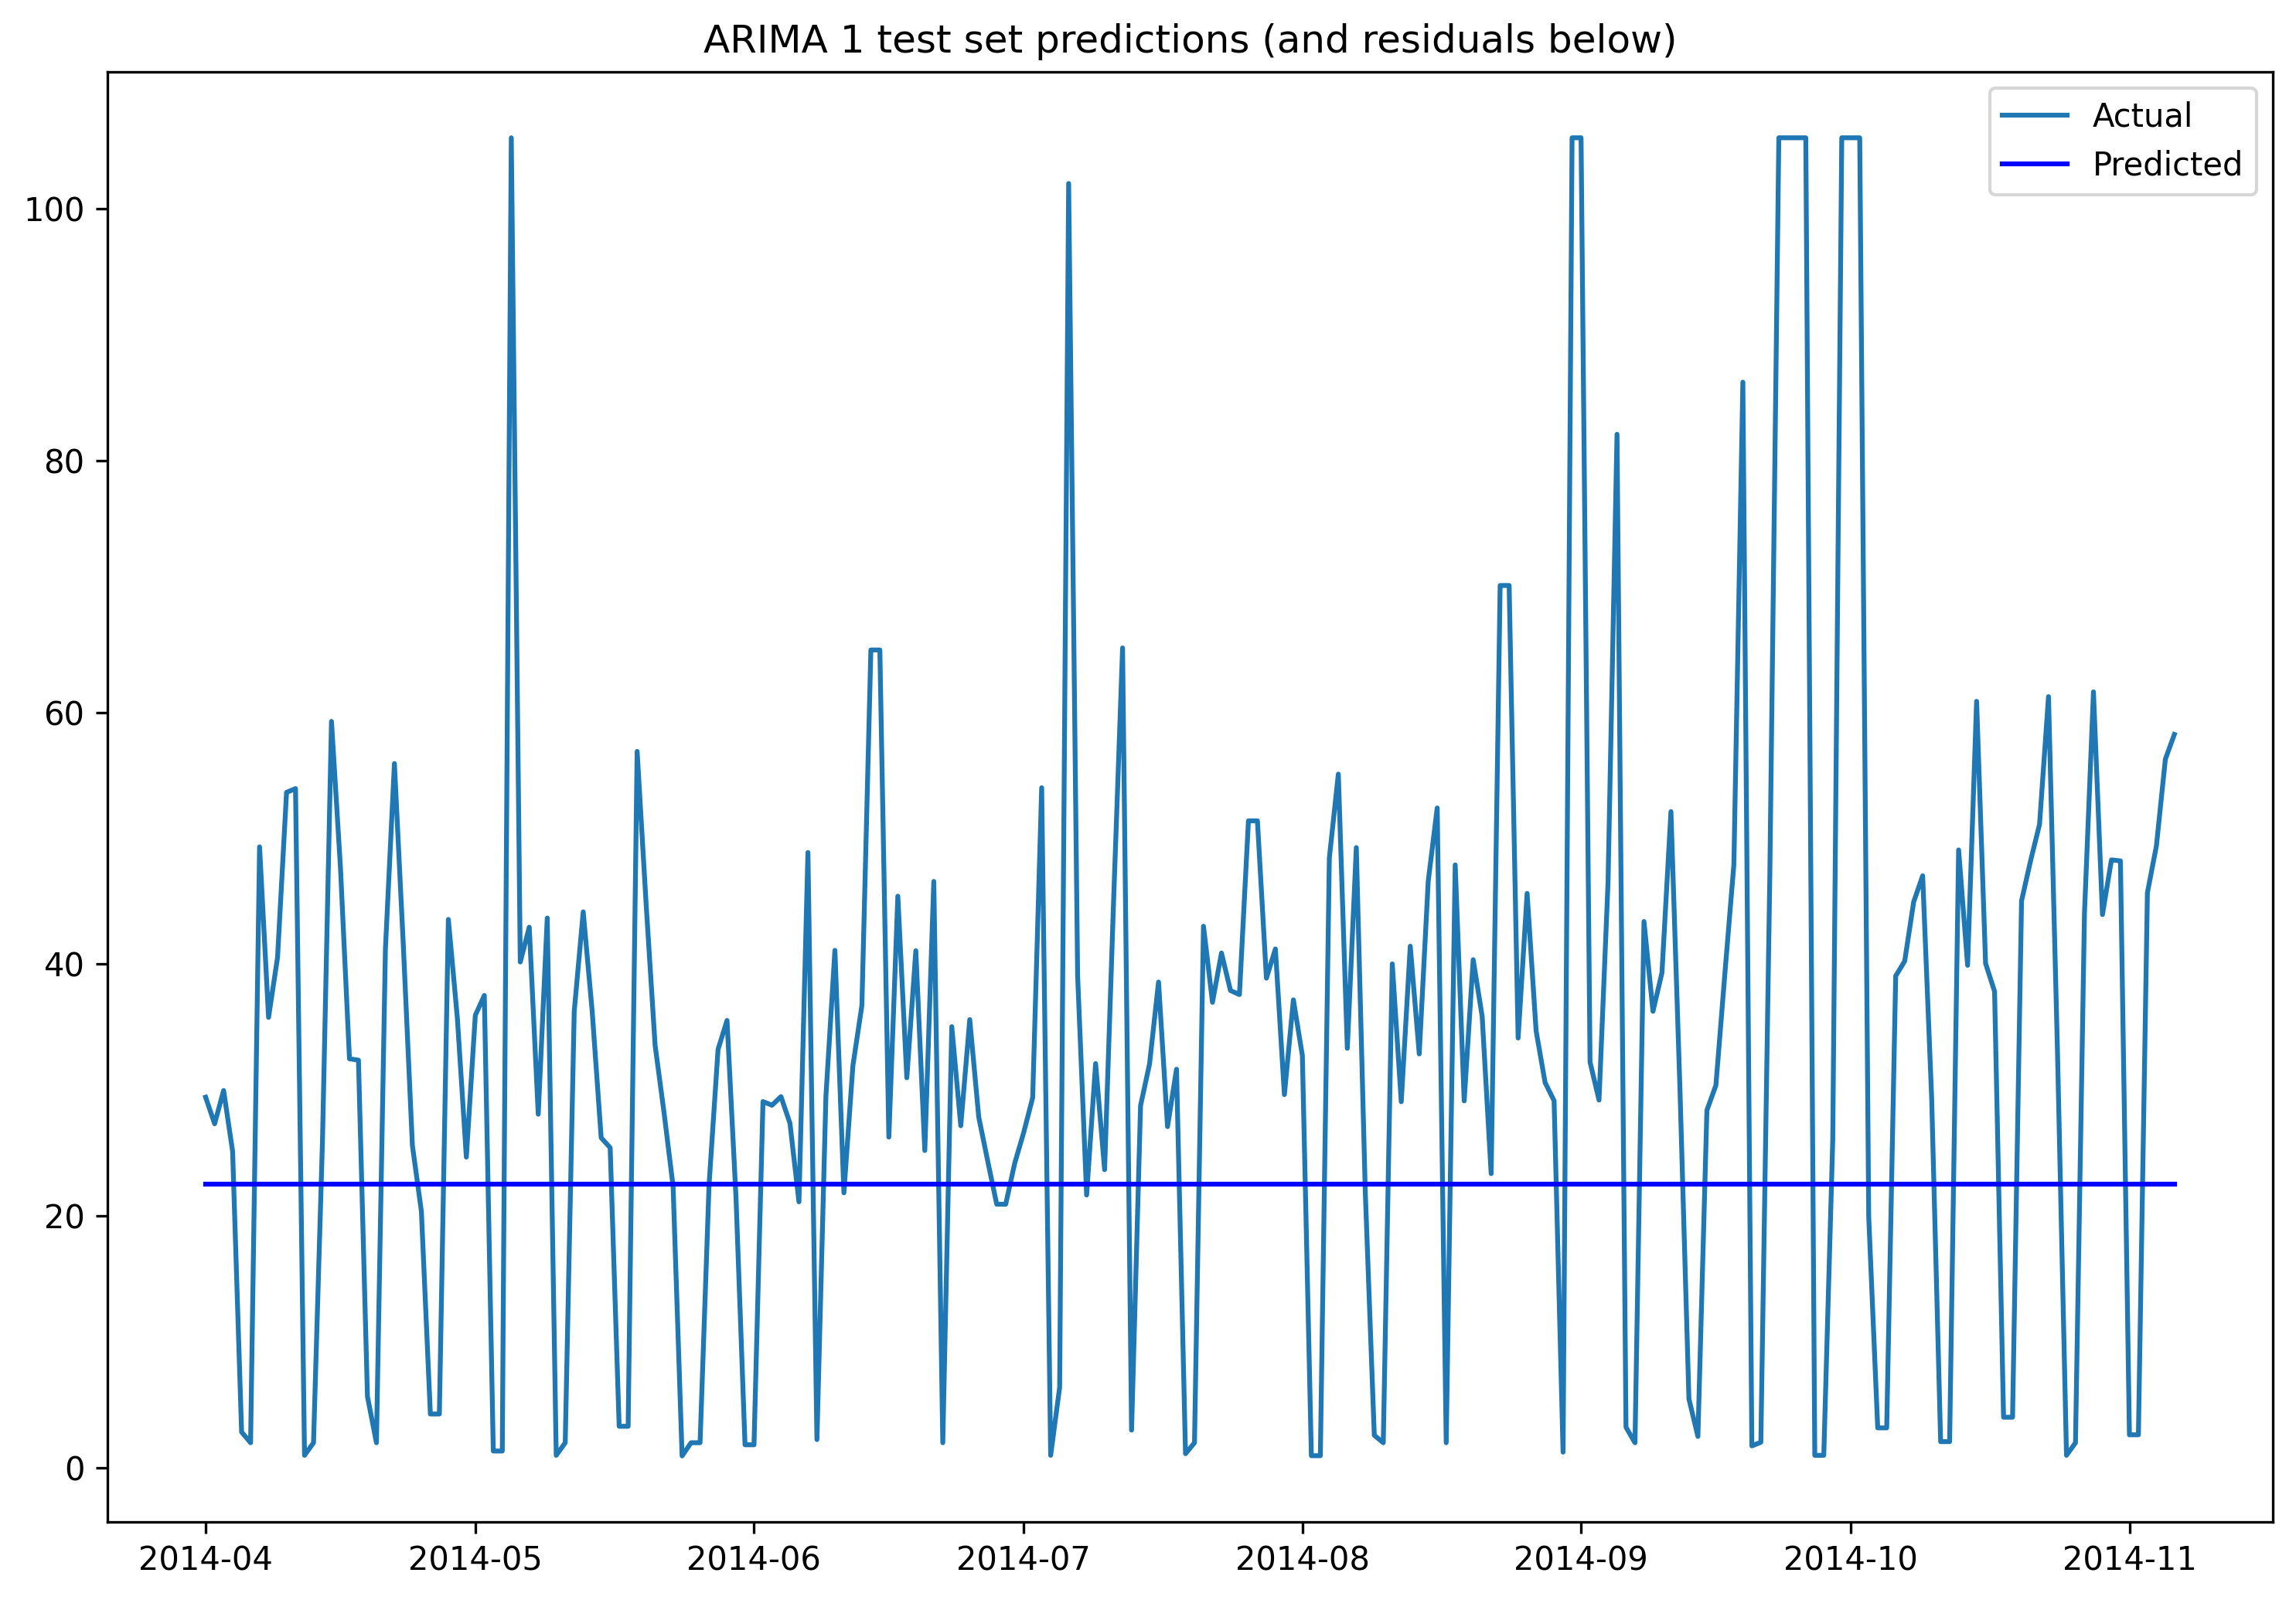

In [ ]:
# Prediction and residuals plot
plt.plot(ts.iloc[test_start_idx:test_end_idx], label='Actual', linewidth=1.5)
plt.plot(mod_arima_1_pre_values, label='Predicted', color='blue', linewidth=1.5)
plt.title("ARIMA 1 test set predictions (and residuals below)")
plt.legend()
plt.show()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


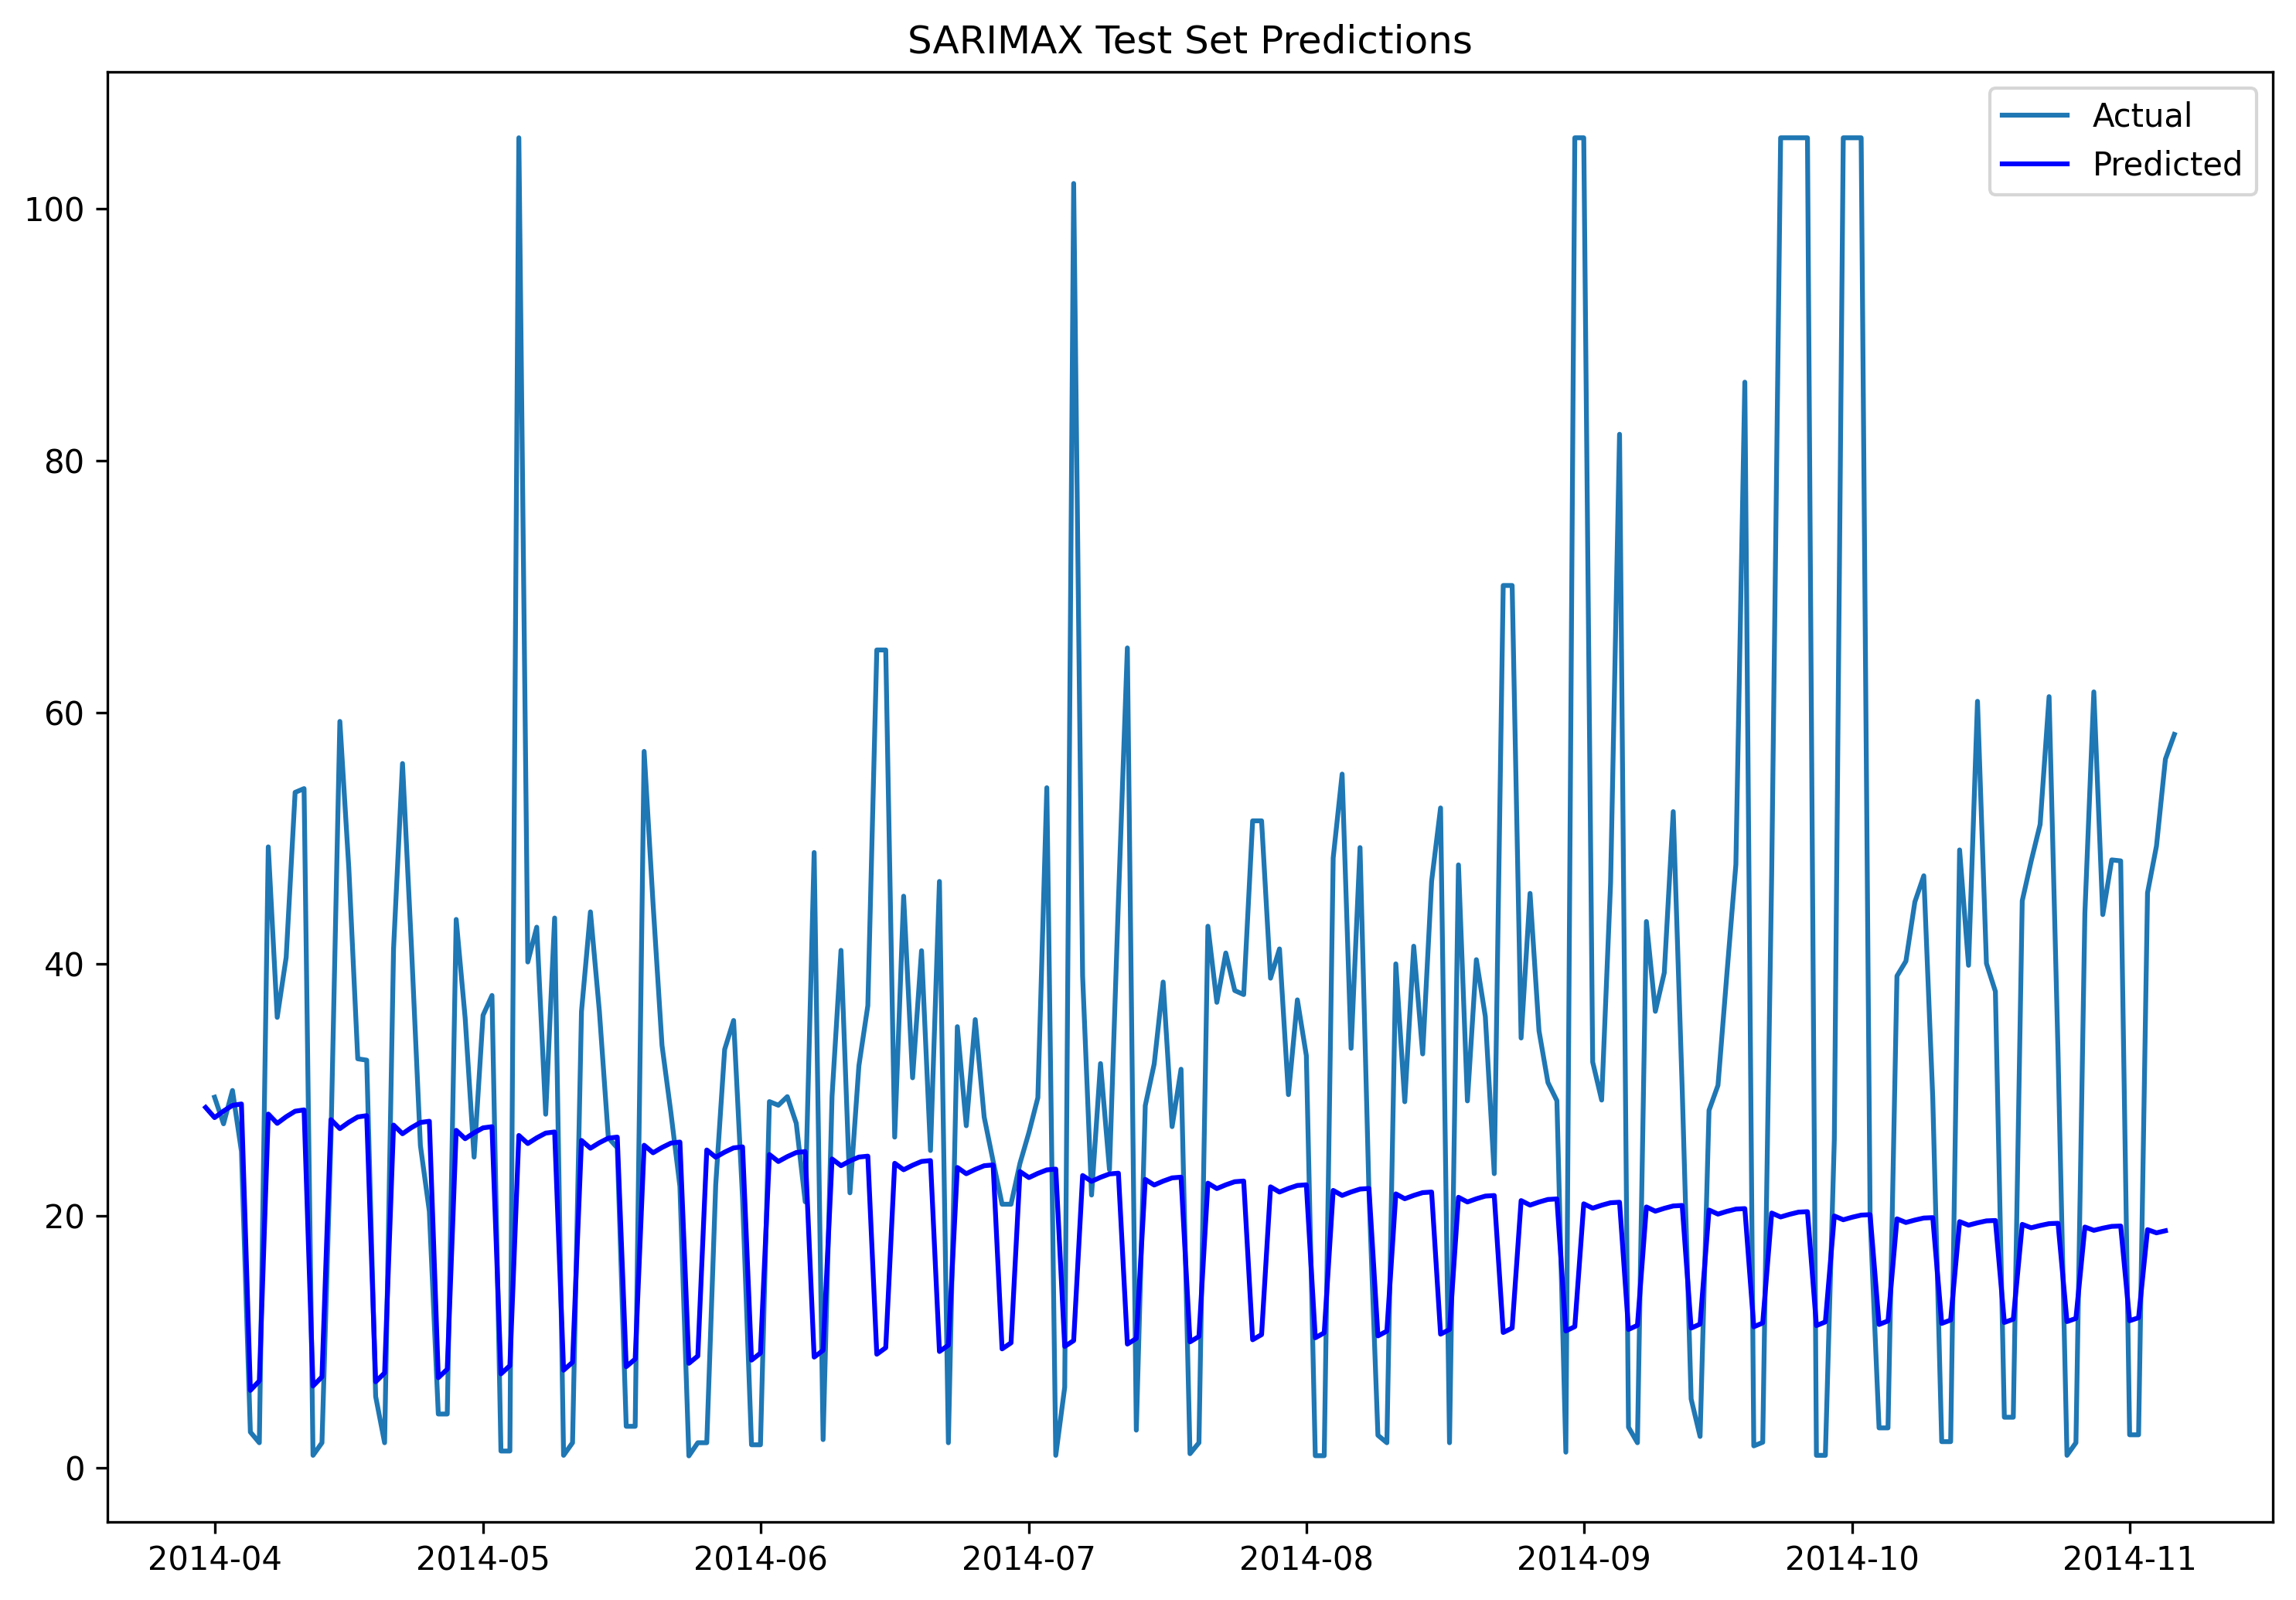

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with seasonal components
sarimax_model = SARIMAX(ts.iloc[train_start_idx:train_end_idx],
                        order=(1, 1, 1), seasonal_order=(2, 0, 1, 7), trend='c')
sarimax_results = sarimax_model.fit()

# Forecast for test set
sarimax_forecast = sarimax_results.get_forecast(steps=len(ts.iloc[test_start_idx:test_end_idx]))
forecast_mean = sarimax_forecast.predicted_mean
# Adjust the periods to match the length of the test set
sarimax_pre_values = pd.Series(forecast_mean, index=pd.date_range(start=test_start, periods=len(ts.iloc[test_start_idx:test_end_idx])))

# Plot actual vs predicted
plt.plot(ts.iloc[test_start_idx:test_end_idx], label='Actual', linewidth=1.5)
plt.plot(forecast_mean, label='Predicted', color='blue', linewidth=1.5)
plt.title("SARIMAX Test Set Predictions")
plt.legend()
plt.show()


In [ ]:
print(sarimax_results.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                 2643
Model:             SARIMAX(1, 1, 1)x(2, 0, 1, 7)   Log Likelihood              -11732.694
Date:                           Tue, 07 Jan 2025   AIC                          23479.388
Time:                                   15:12:37   BIC                          23520.543
Sample:                               01-04-2007   HQIC                         23494.288
                                    - 03-30-2014                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0003      0.001     -0.233      0.815      -0.003       0.003
ar.L1          0.2146      0.014     14.870

In [ ]:
# In cell ipython-input-90-ac40dadefb6e:

# Instead of:
# mae_value = error_func(ts.iloc[train_start_idx:train_end_idx],mod_arima_1_pre_values)

# Use the test set for comparison:
mae_value = error_func(ts.iloc[test_start_idx:test_end_idx], sarimax_pre_values)
# 'ts.iloc[test_start_idx:test_end_idx]' should have the same length as 'mod_arima_1_pre_values' (220)

# Then print using the new variable name:
print('MAE: ', int(mae_value))

MAE:  18


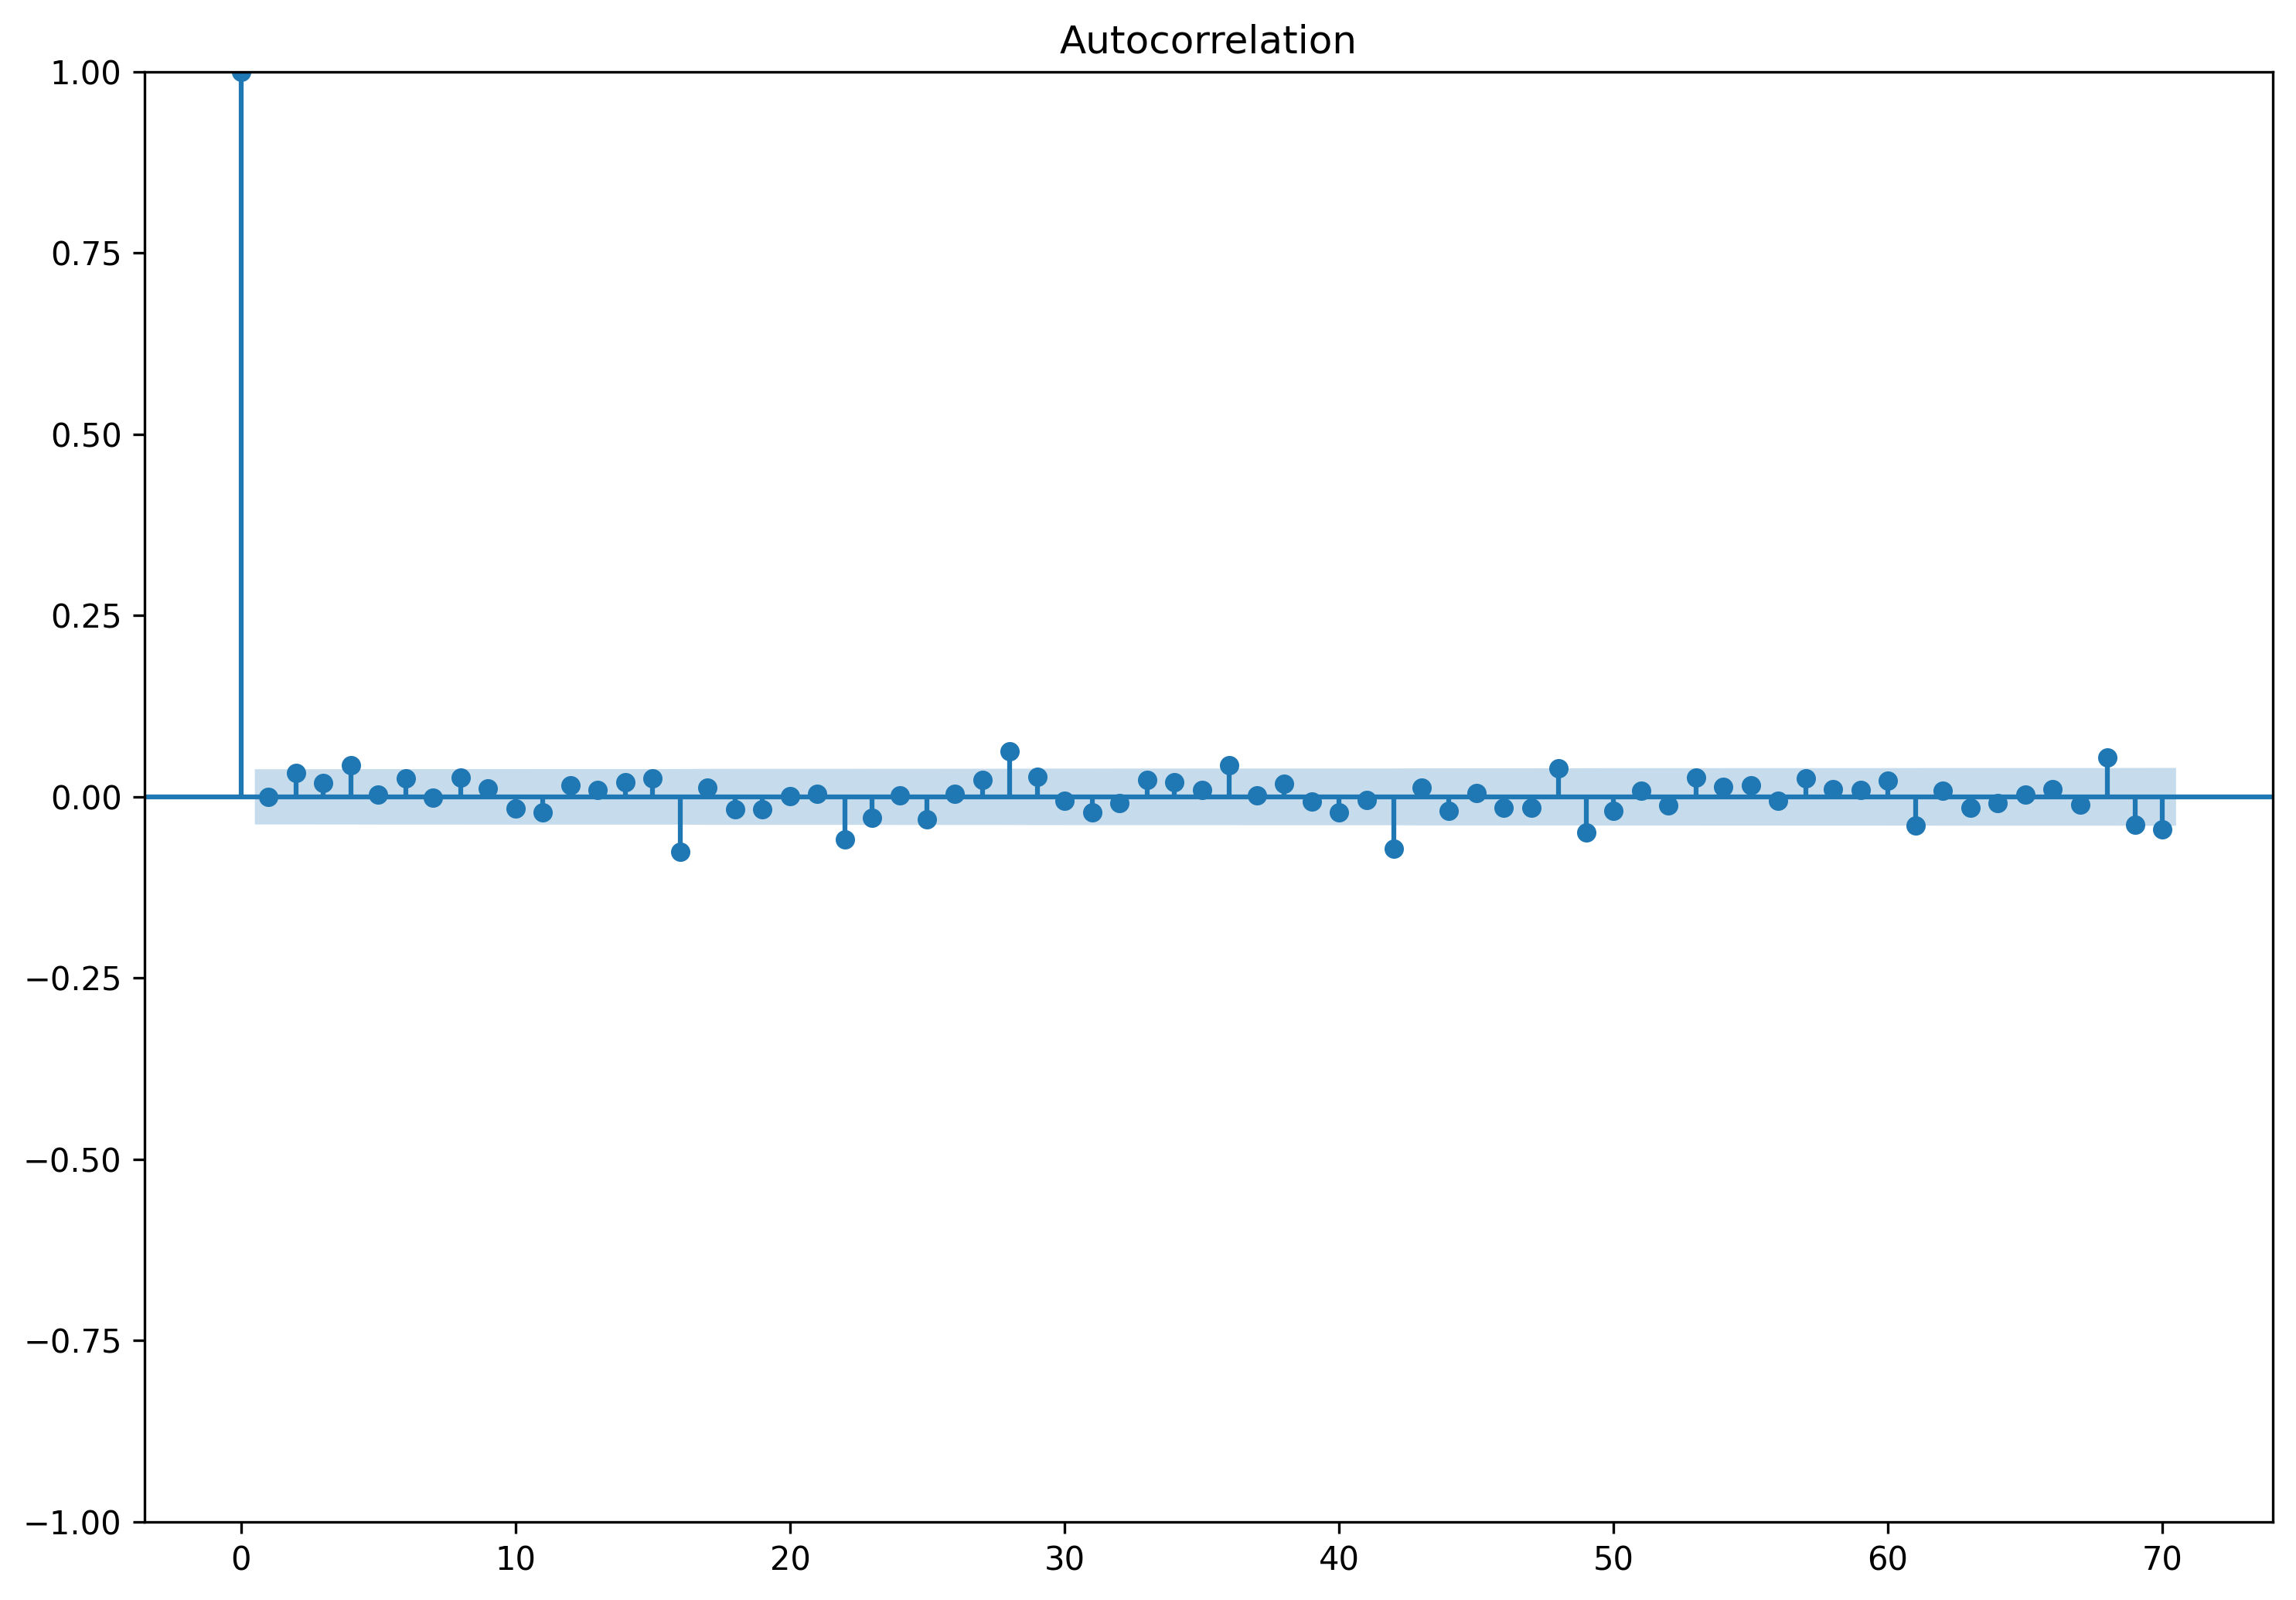

In [ ]:
plot_acf(sarimax_results.resid, lags=70)
plt.show()

###CHATGPT

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.api import ExponentialSmoothing, SARIMAX
from scipy.stats import boxcox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
# Replace 'ts_data' with your time series data as a pandas Series
# Assuming 'ts_data' is indexed by date
ts_data = ts

# ADF test
def adf_test(series):
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    for key, value in result[4].items():
        print(f"Critical Value ({key}): {value}")

adf_test(ts_data)

ADF Statistic: -3.771724181110665
p-value: 0.0032102302503606442
Critical Value (1%): -3.432545551806462
Critical Value (5%): -2.8625100519404665
Critical Value (10%): -2.5672863845358074


<ipython-input-29-bbe2cf4b333e>:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_means = ts_data.resample('M').mean()
<ipython-input-29-bbe2cf4b333e>:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_stdevs = ts_data.resample('M').std()


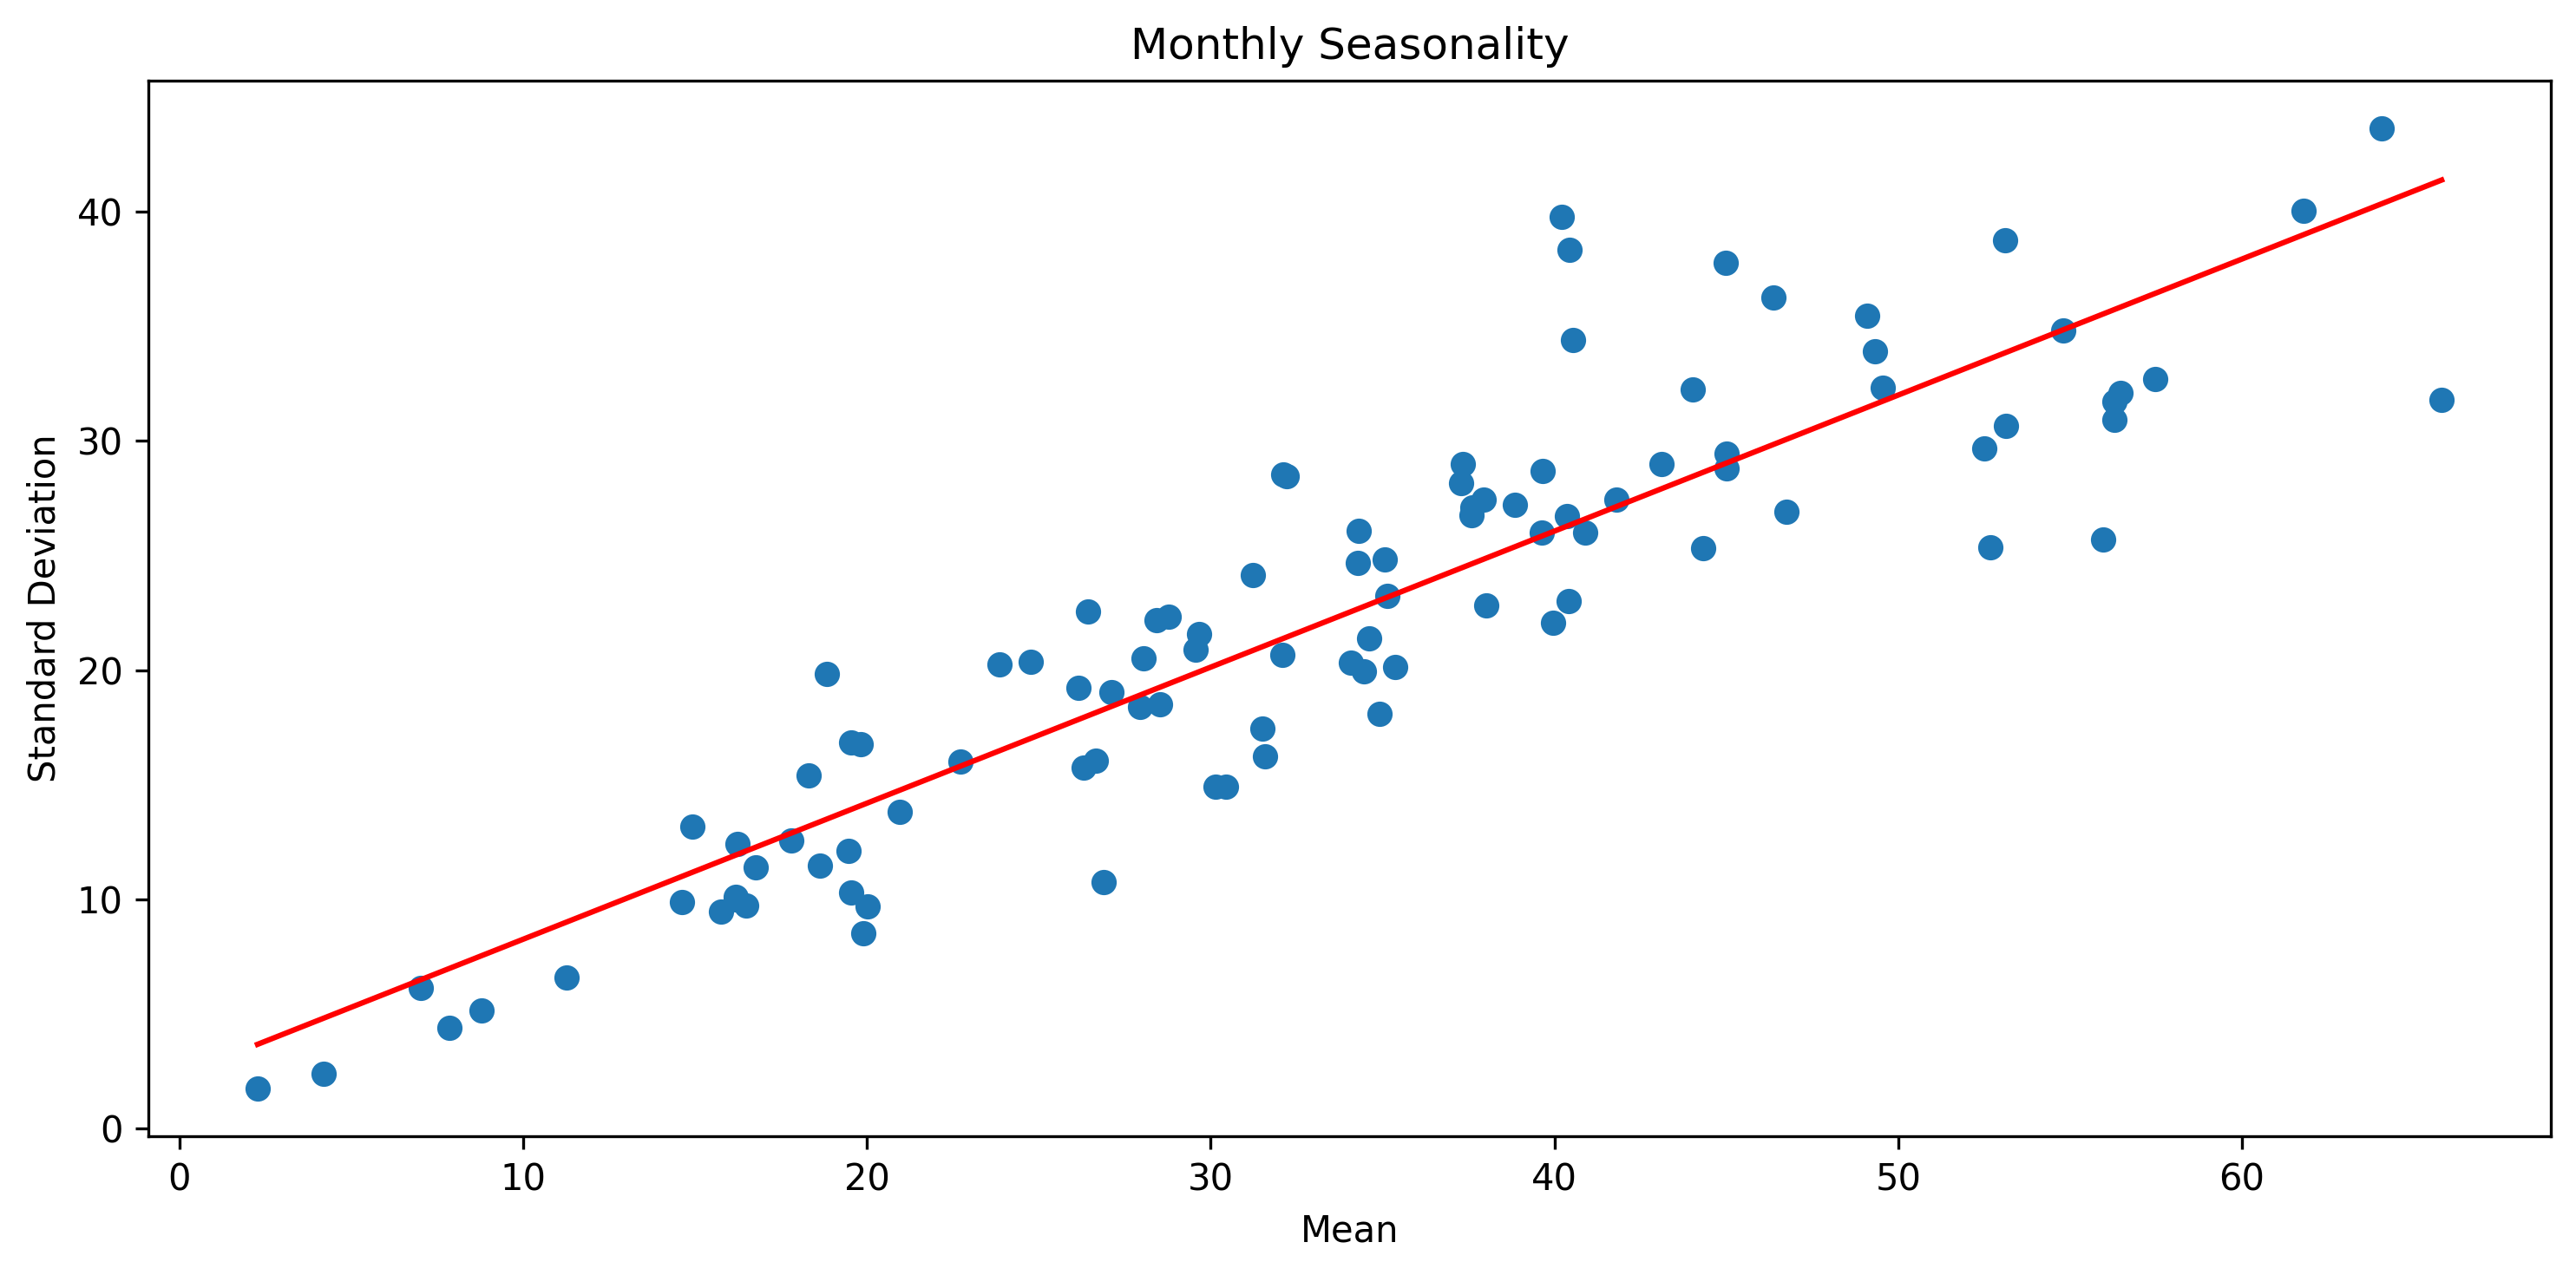

In [ ]:
# Monthly statistics
monthly_means = ts_data.resample('M').mean()
monthly_stdevs = ts_data.resample('M').std()

plt.figure(figsize=(10, 5))
plt.scatter(monthly_means, monthly_stdevs)
plt.title("Monthly Seasonality")
plt.xlabel("Mean")
plt.ylabel("Standard Deviation")
plt.plot(np.unique(monthly_means), np.poly1d(np.polyfit(monthly_means, monthly_stdevs, 1))(np.unique(monthly_means)), color='red')
plt.show()

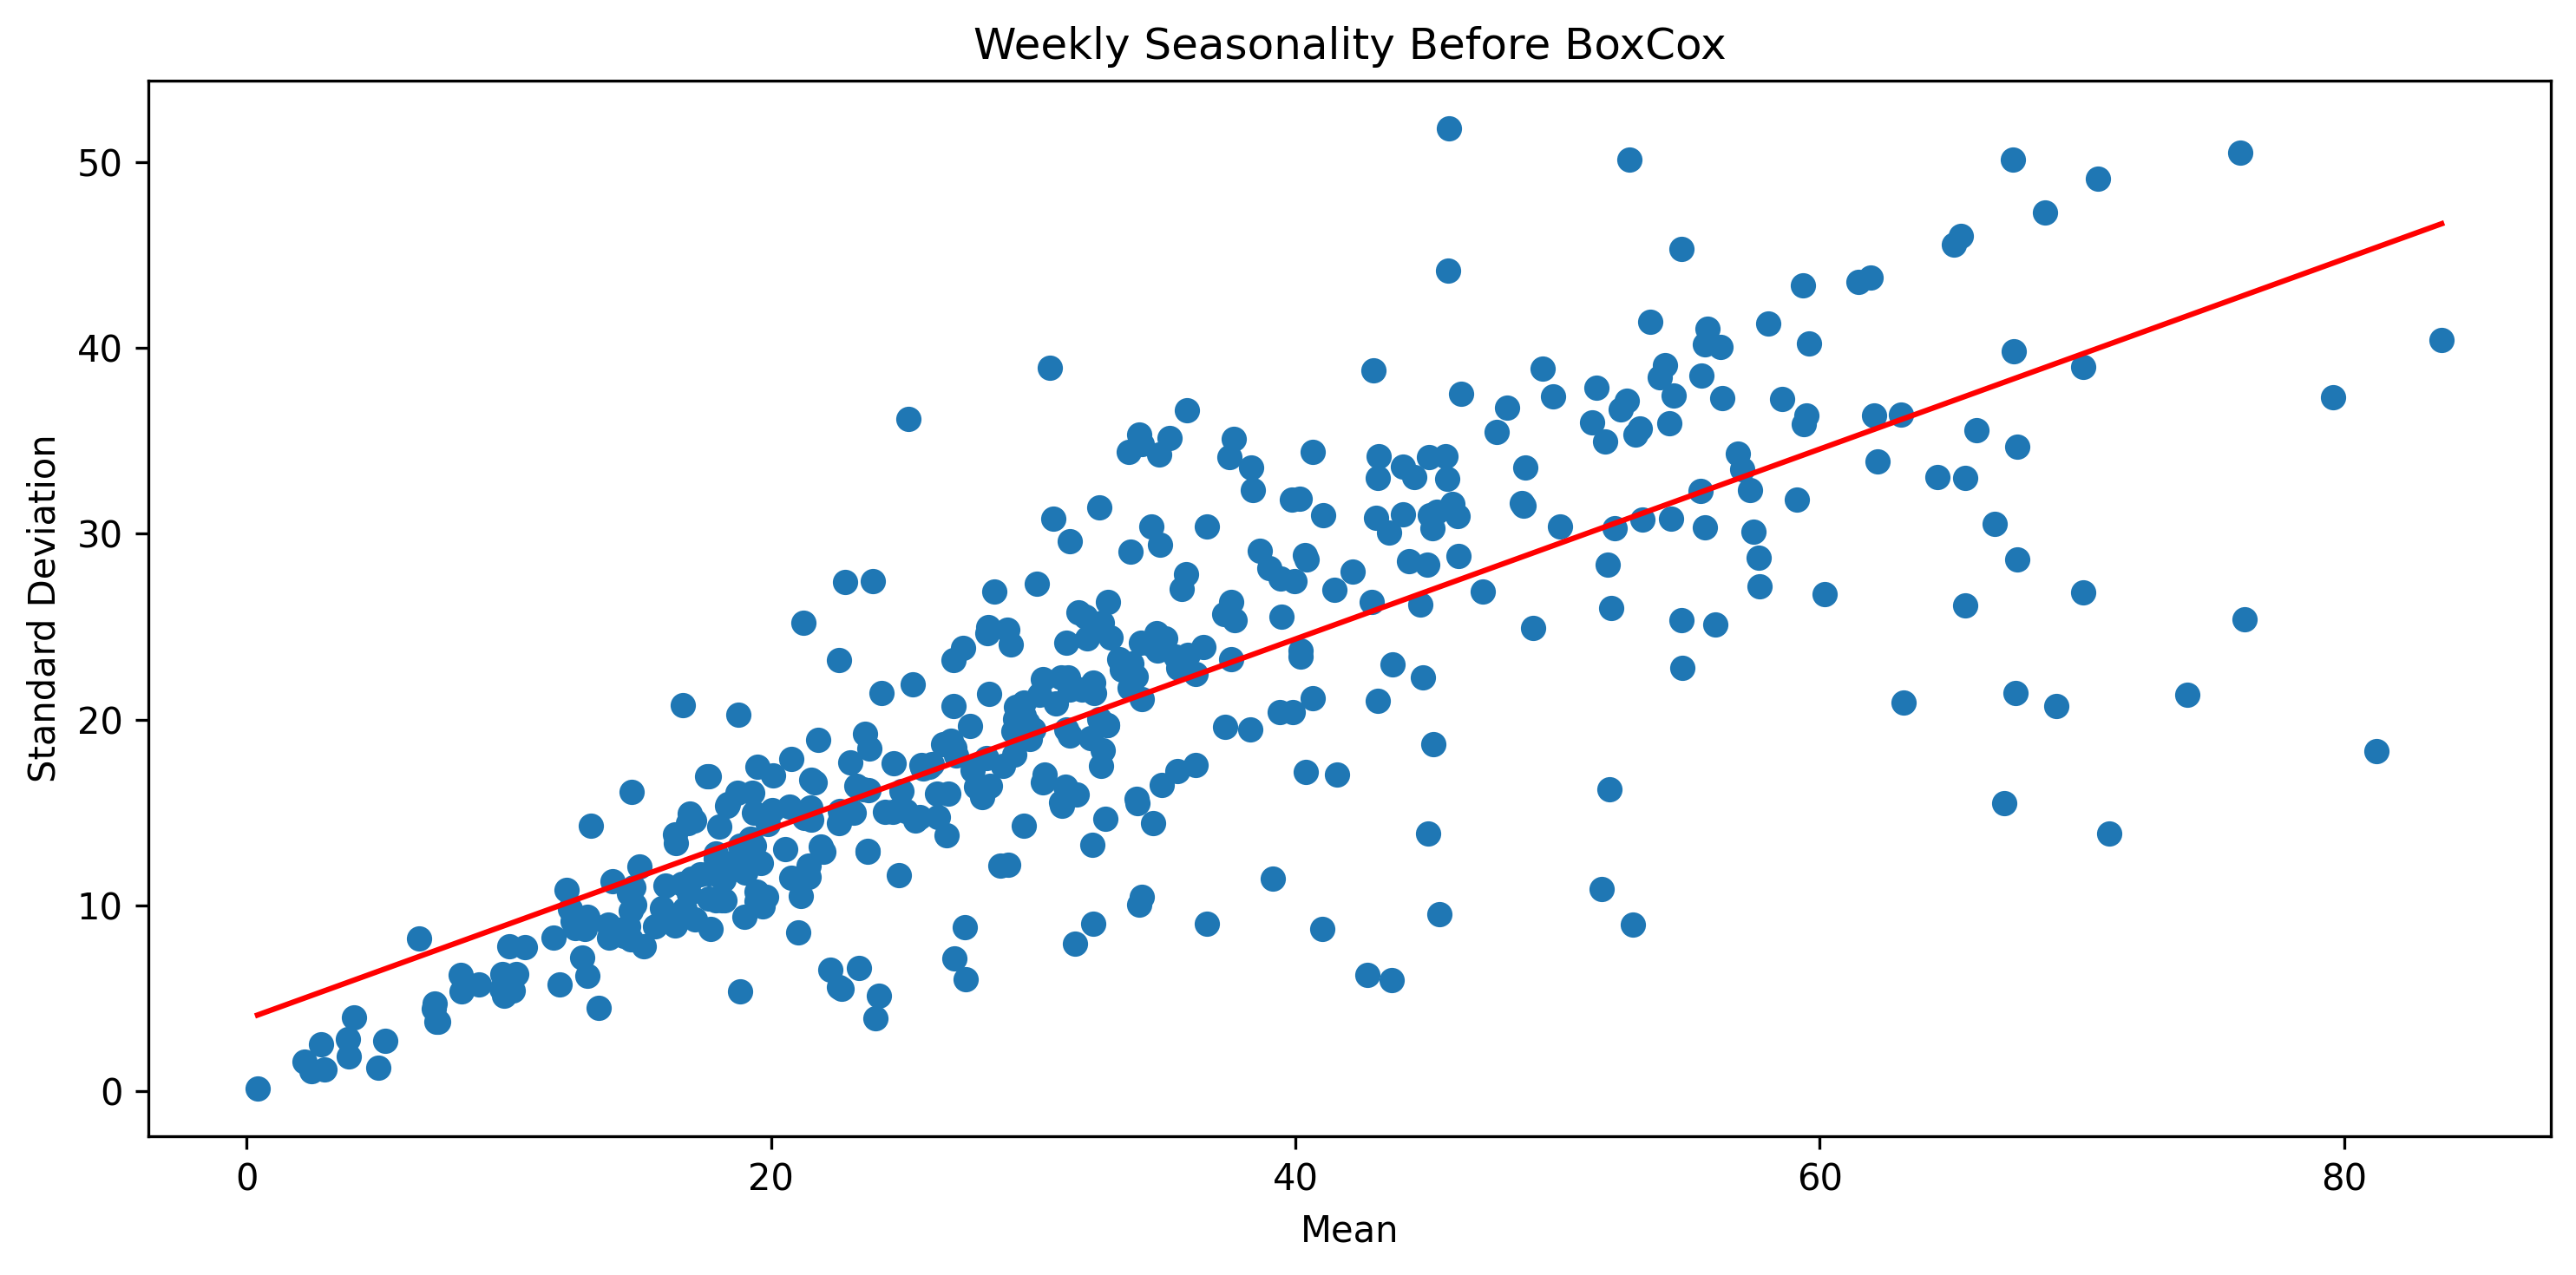

In [ ]:
# Weekly statistics
weekly_means = ts_data.resample('W').mean()
weekly_stdevs = ts_data.resample('W').std()

plt.figure(figsize=(10, 5))
plt.scatter(weekly_means, weekly_stdevs)
plt.title("Weekly Seasonality Before BoxCox")
plt.xlabel("Mean")
plt.ylabel("Standard Deviation")
plt.plot(np.unique(weekly_means), np.poly1d(np.polyfit(weekly_means, weekly_stdevs, 1))(np.unique(weekly_means)), color='red')
plt.show()

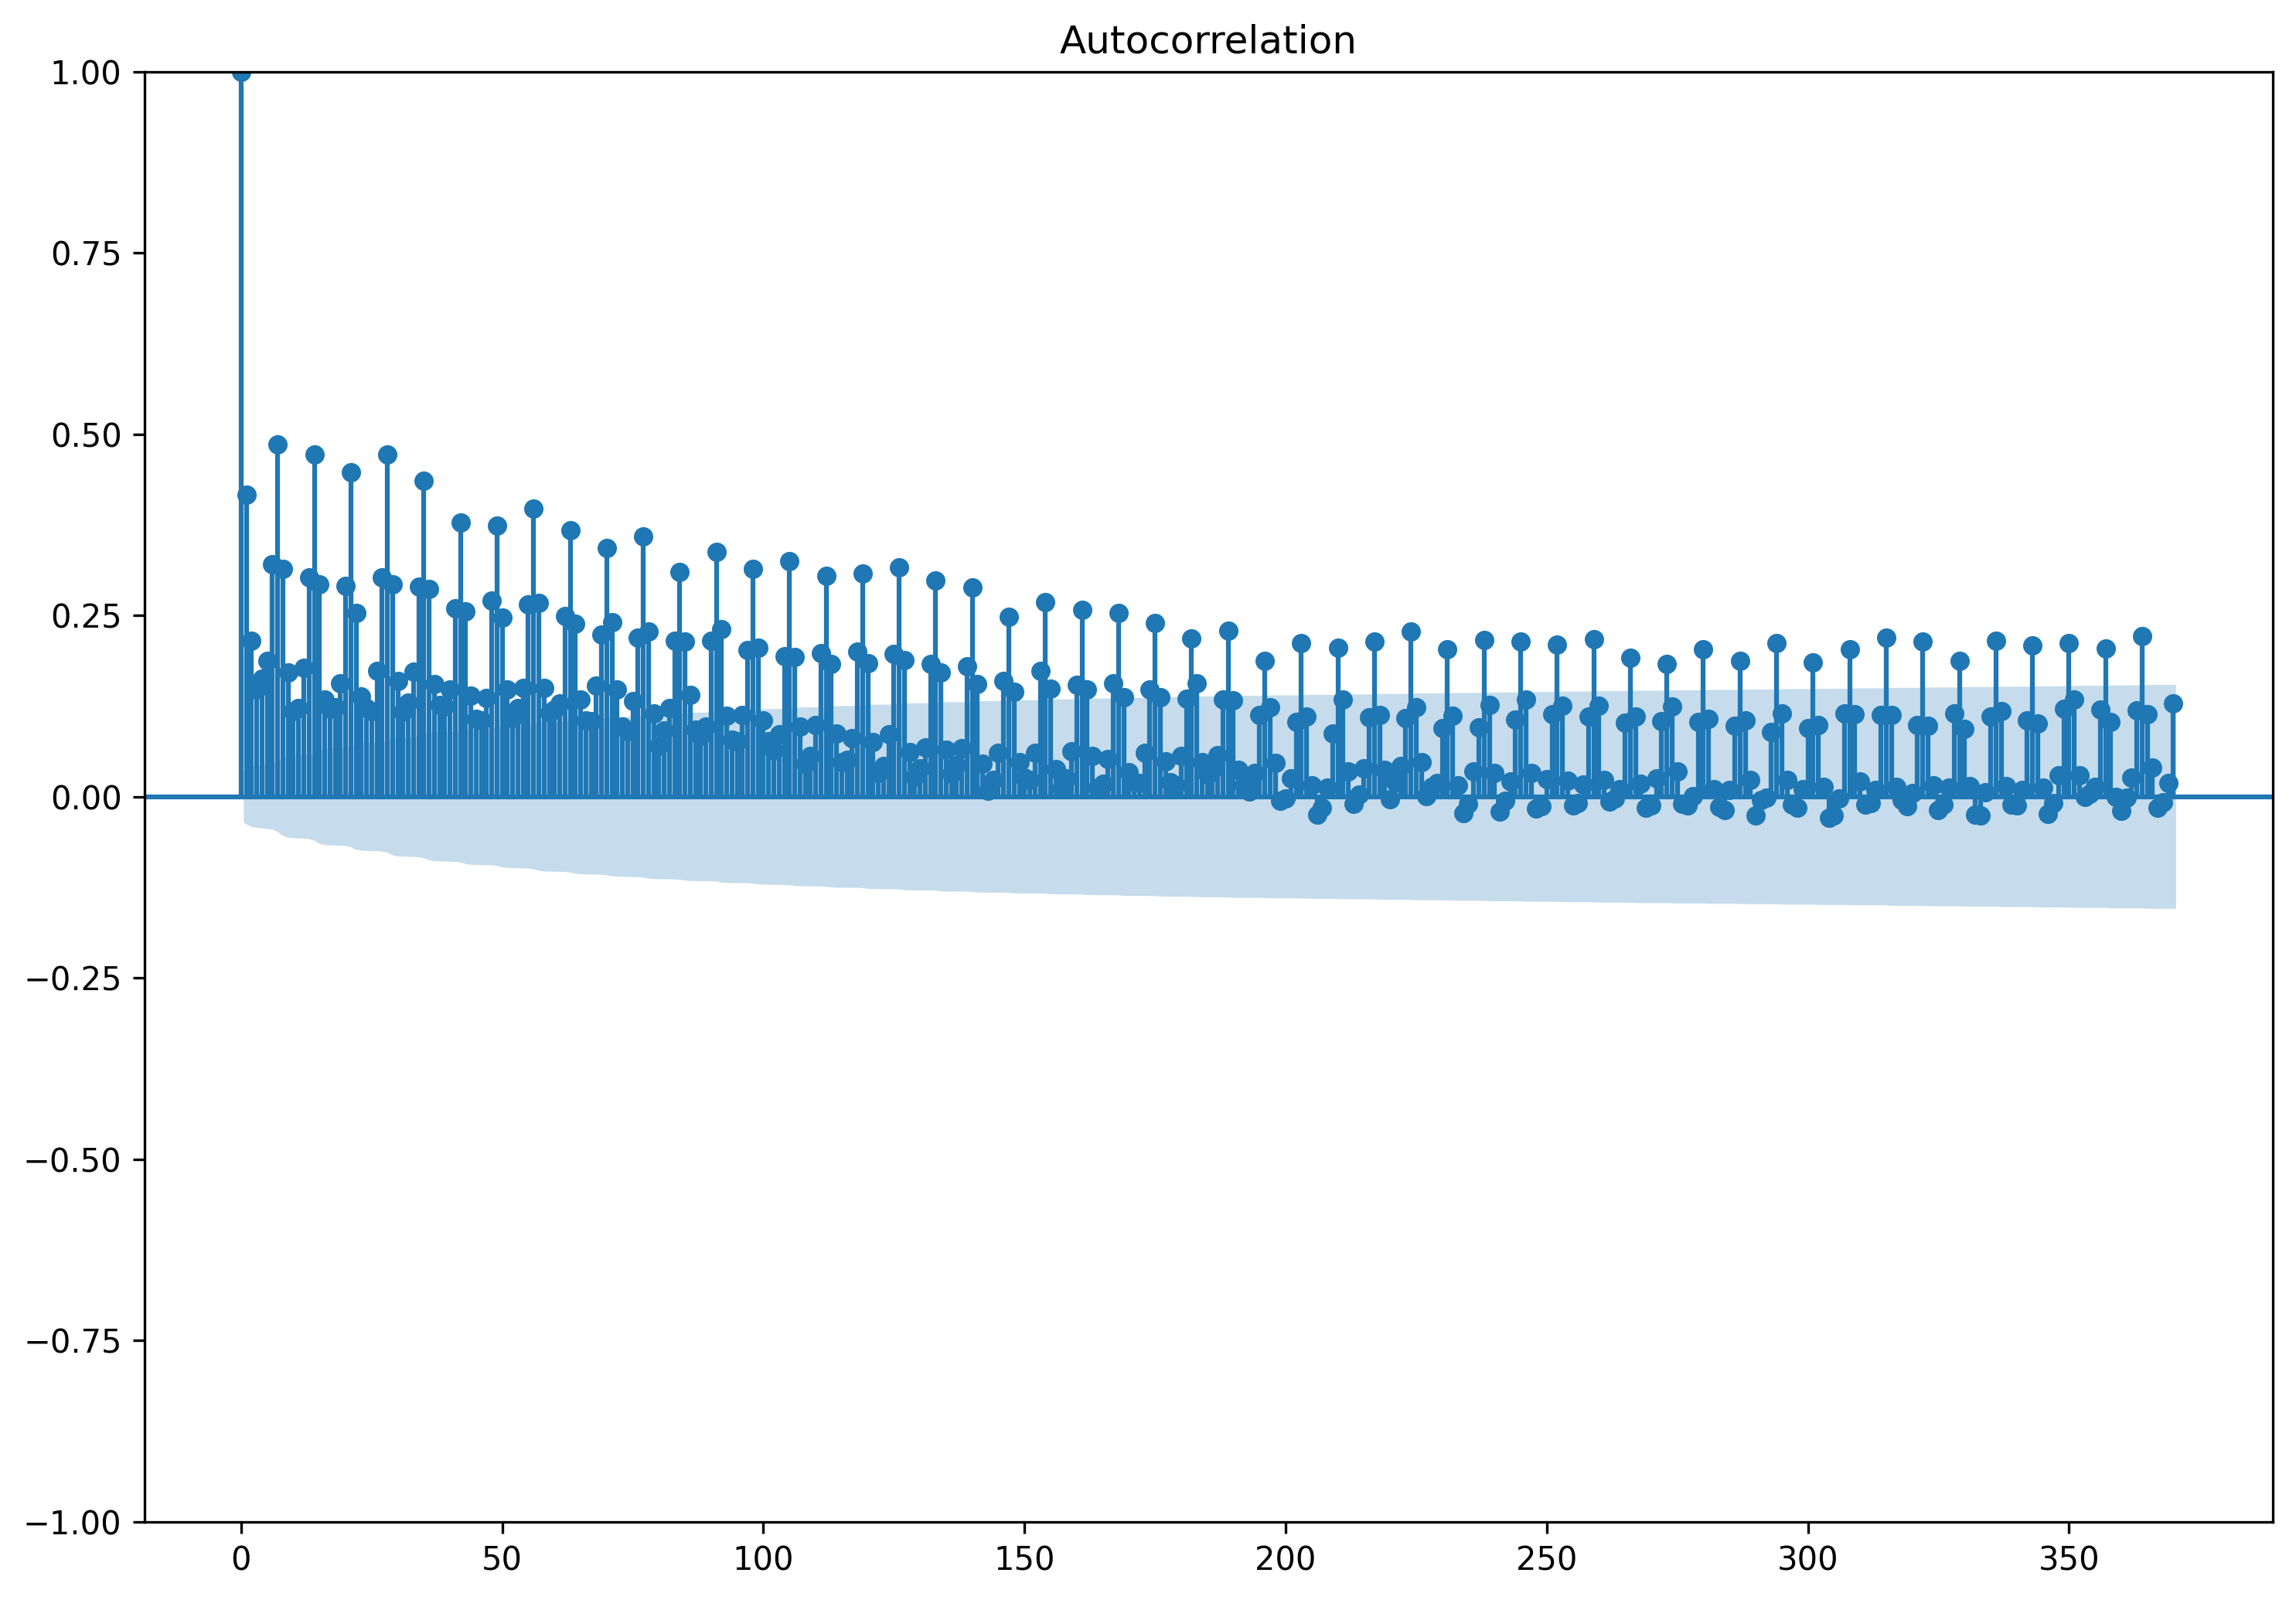

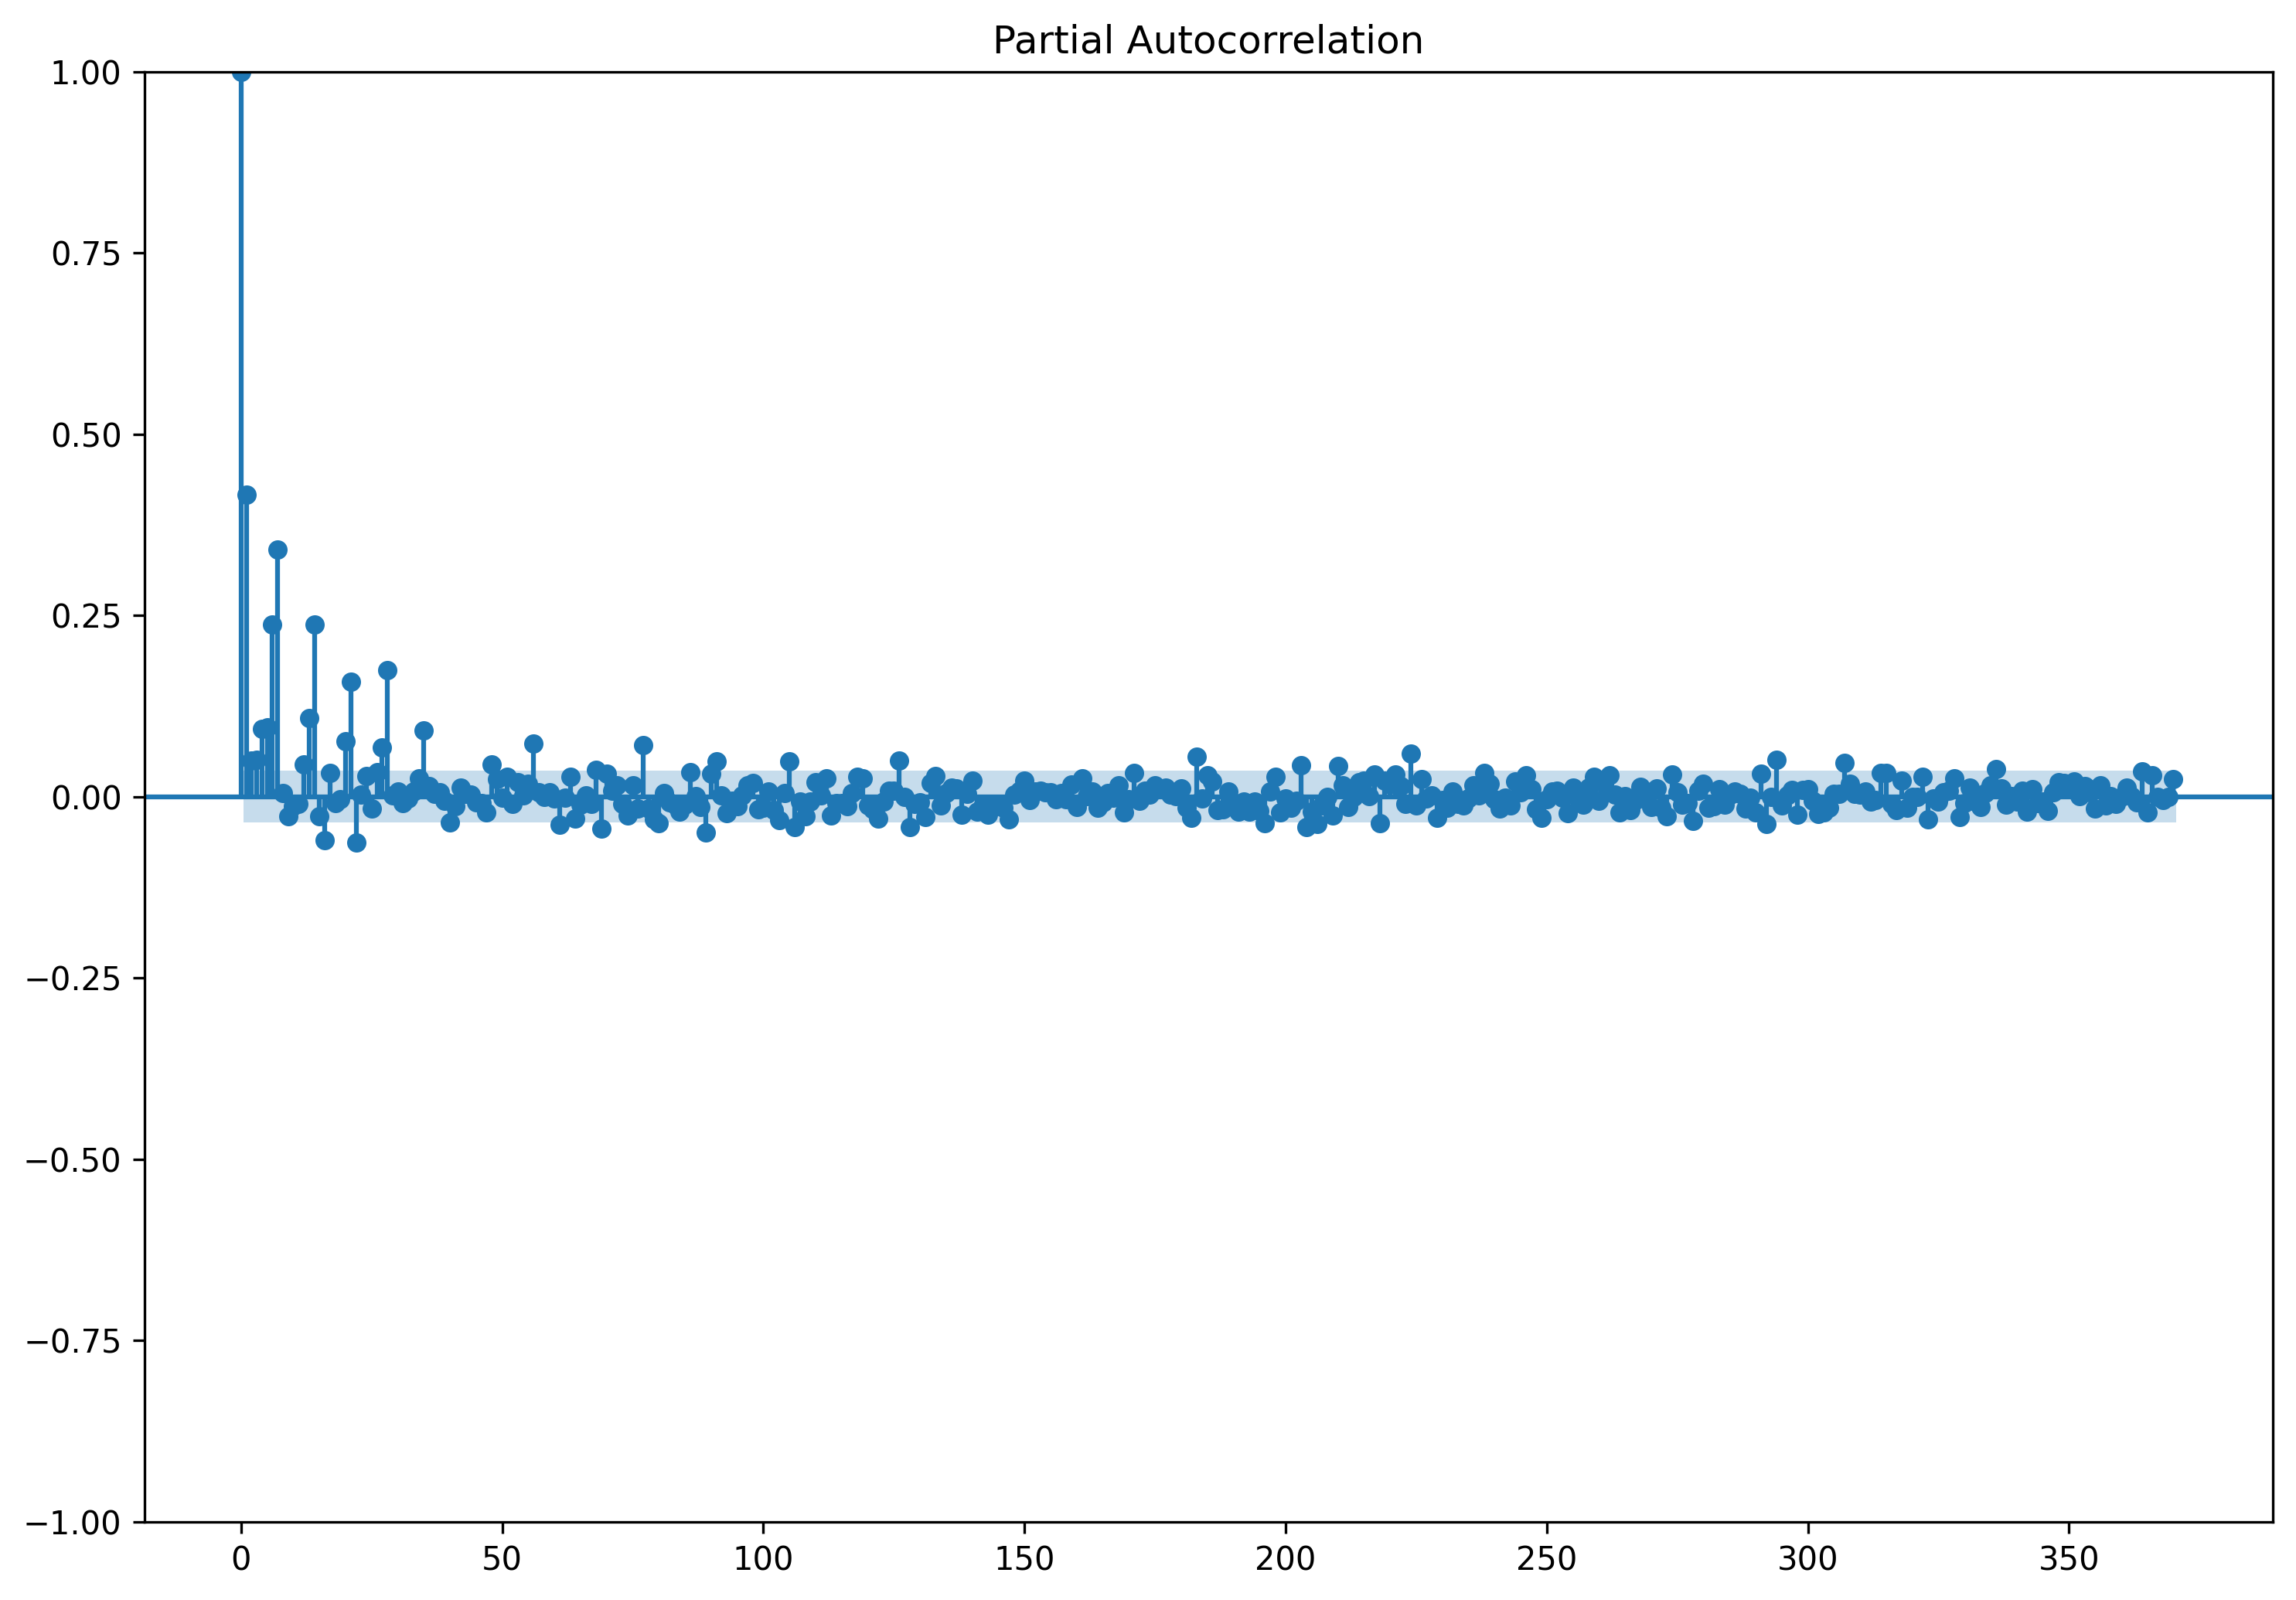

In [ ]:
# ACF and PACF plots
plot_acf(ts_data, lags=370)
plt.show()
plot_pacf(ts_data, lags=370)
plt.show()

##ARIMA

In [ ]:
# Box-Cox Transformation
bc_lambda = 0.25
bc_transformed = boxcox(ts_data, lmbda=bc_lambda)

<ipython-input-33-b1644df7d143>:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  bc_monthly_means = bc_series.resample('M').mean()
<ipython-input-33-b1644df7d143>:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  bc_monthly_stdevs = bc_series.resample('M').std()


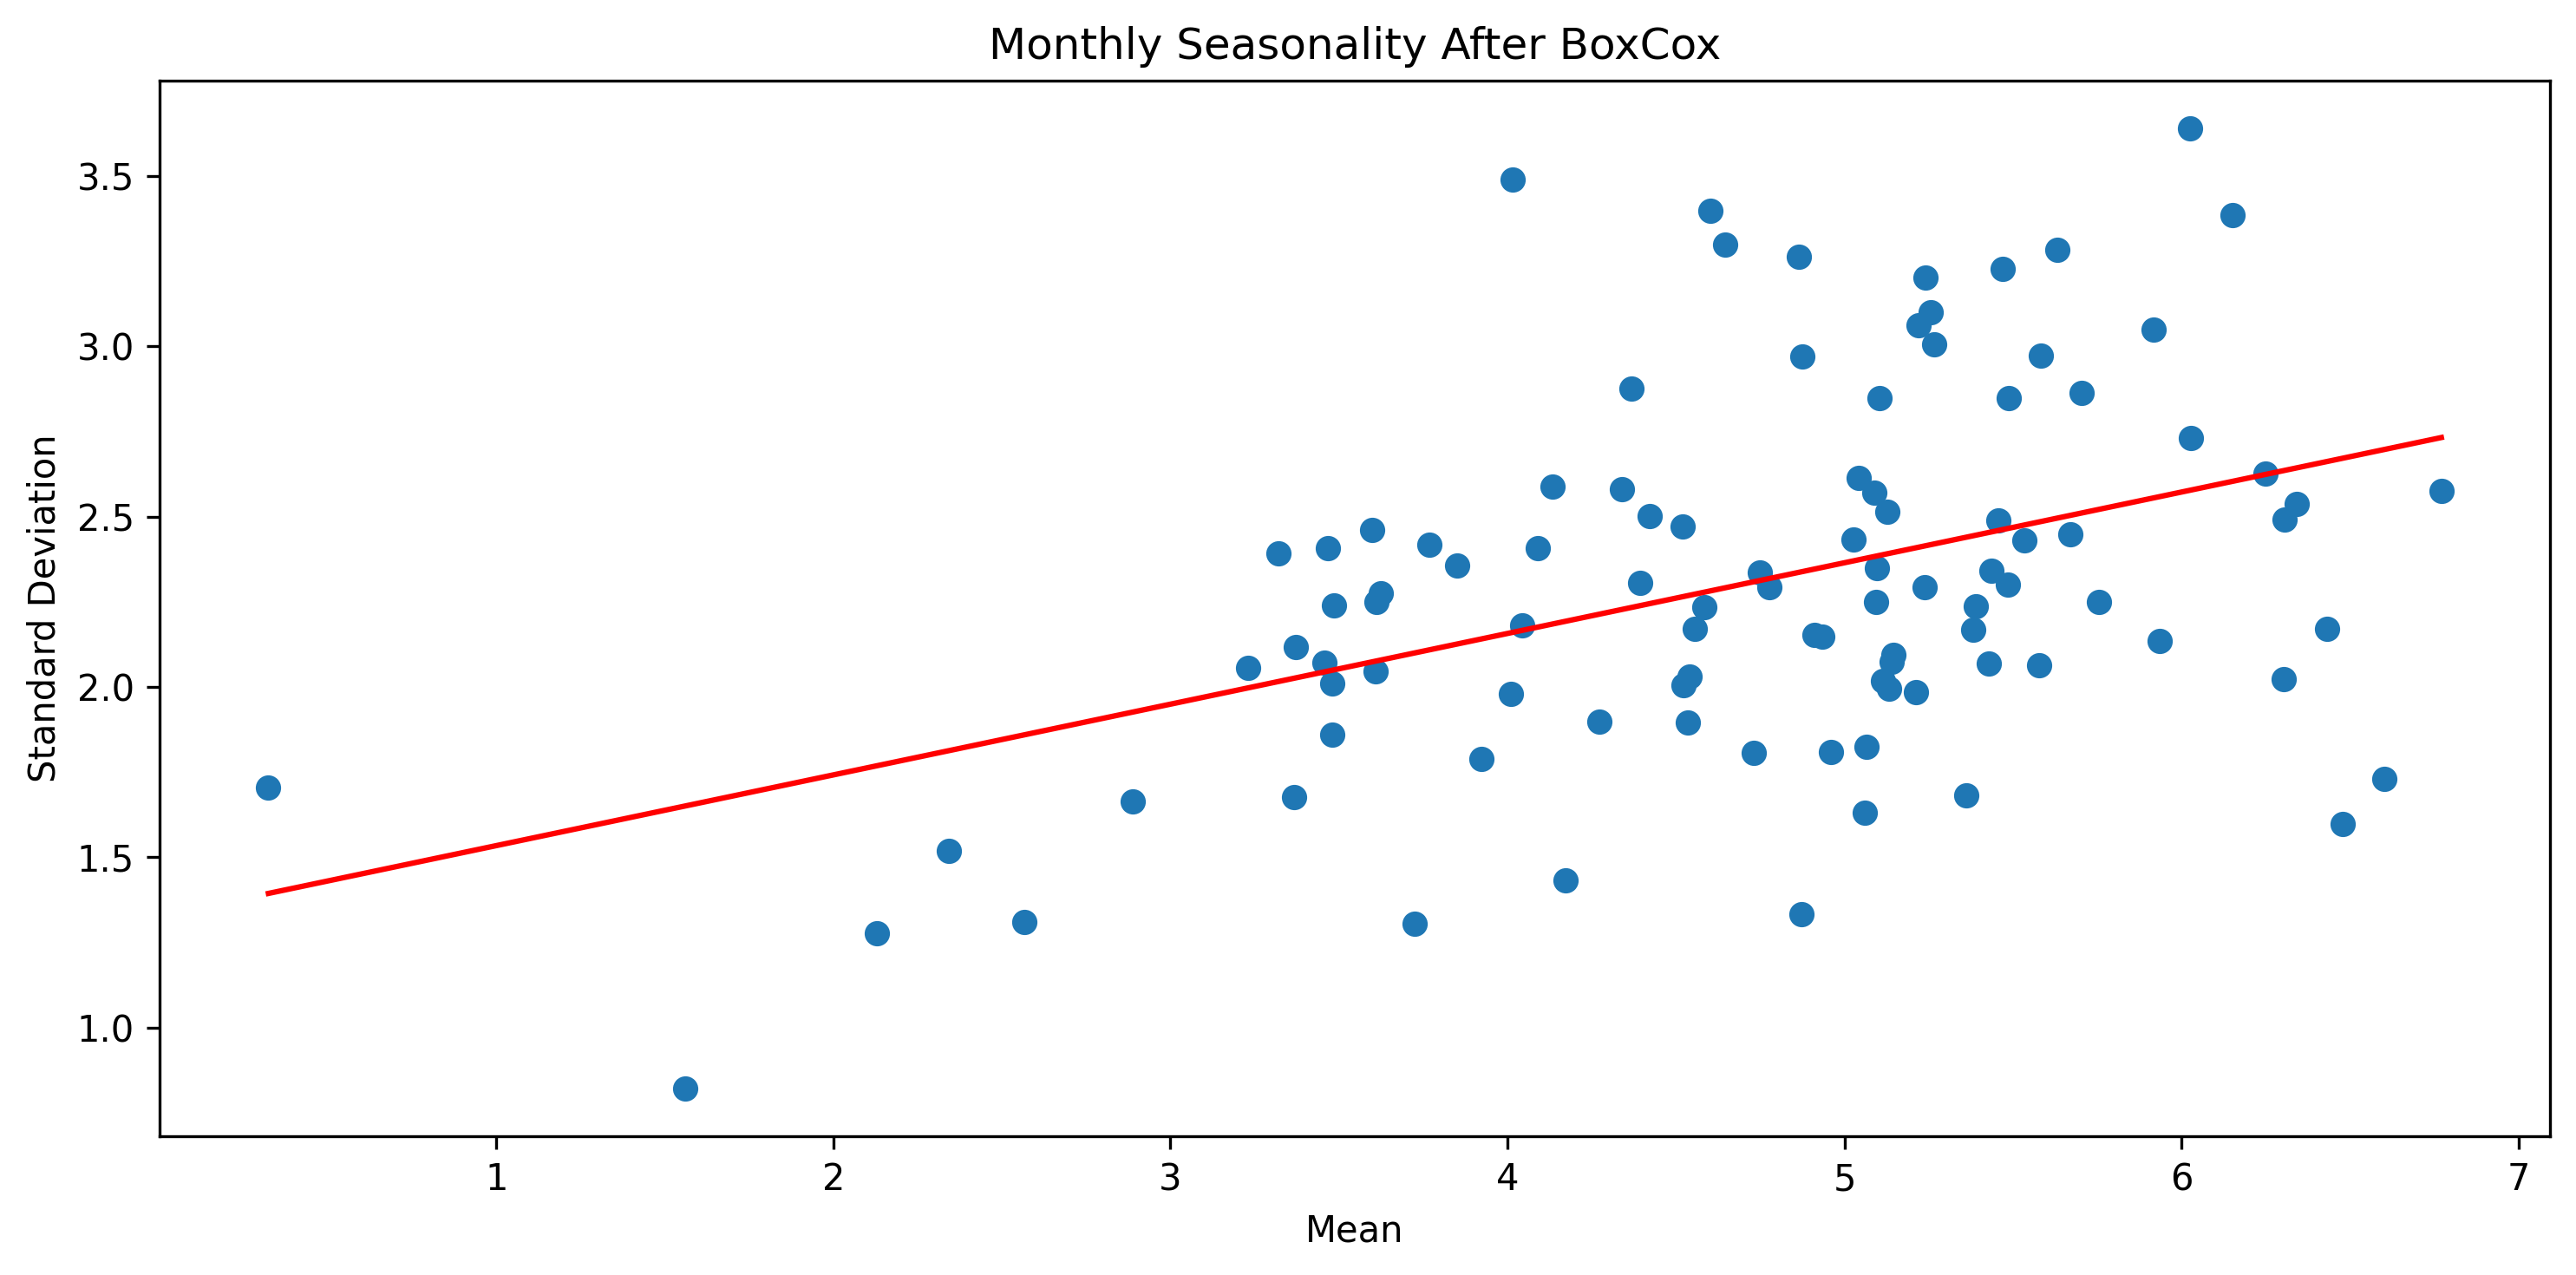

In [ ]:
# Monthly and weekly statistics after Box-Cox
bc_series = pd.Series(bc_transformed, index=ts_data.index)
bc_monthly_means = bc_series.resample('M').mean()
bc_monthly_stdevs = bc_series.resample('M').std()

plt.figure(figsize=(10, 5))
plt.scatter(bc_monthly_means, bc_monthly_stdevs)
plt.title("Monthly Seasonality After BoxCox")
plt.xlabel("Mean")
plt.ylabel("Standard Deviation")
plt.plot(np.unique(bc_monthly_means), np.poly1d(np.polyfit(bc_monthly_means, bc_monthly_stdevs, 1))(np.unique(bc_monthly_means)), color='red')
plt.show()

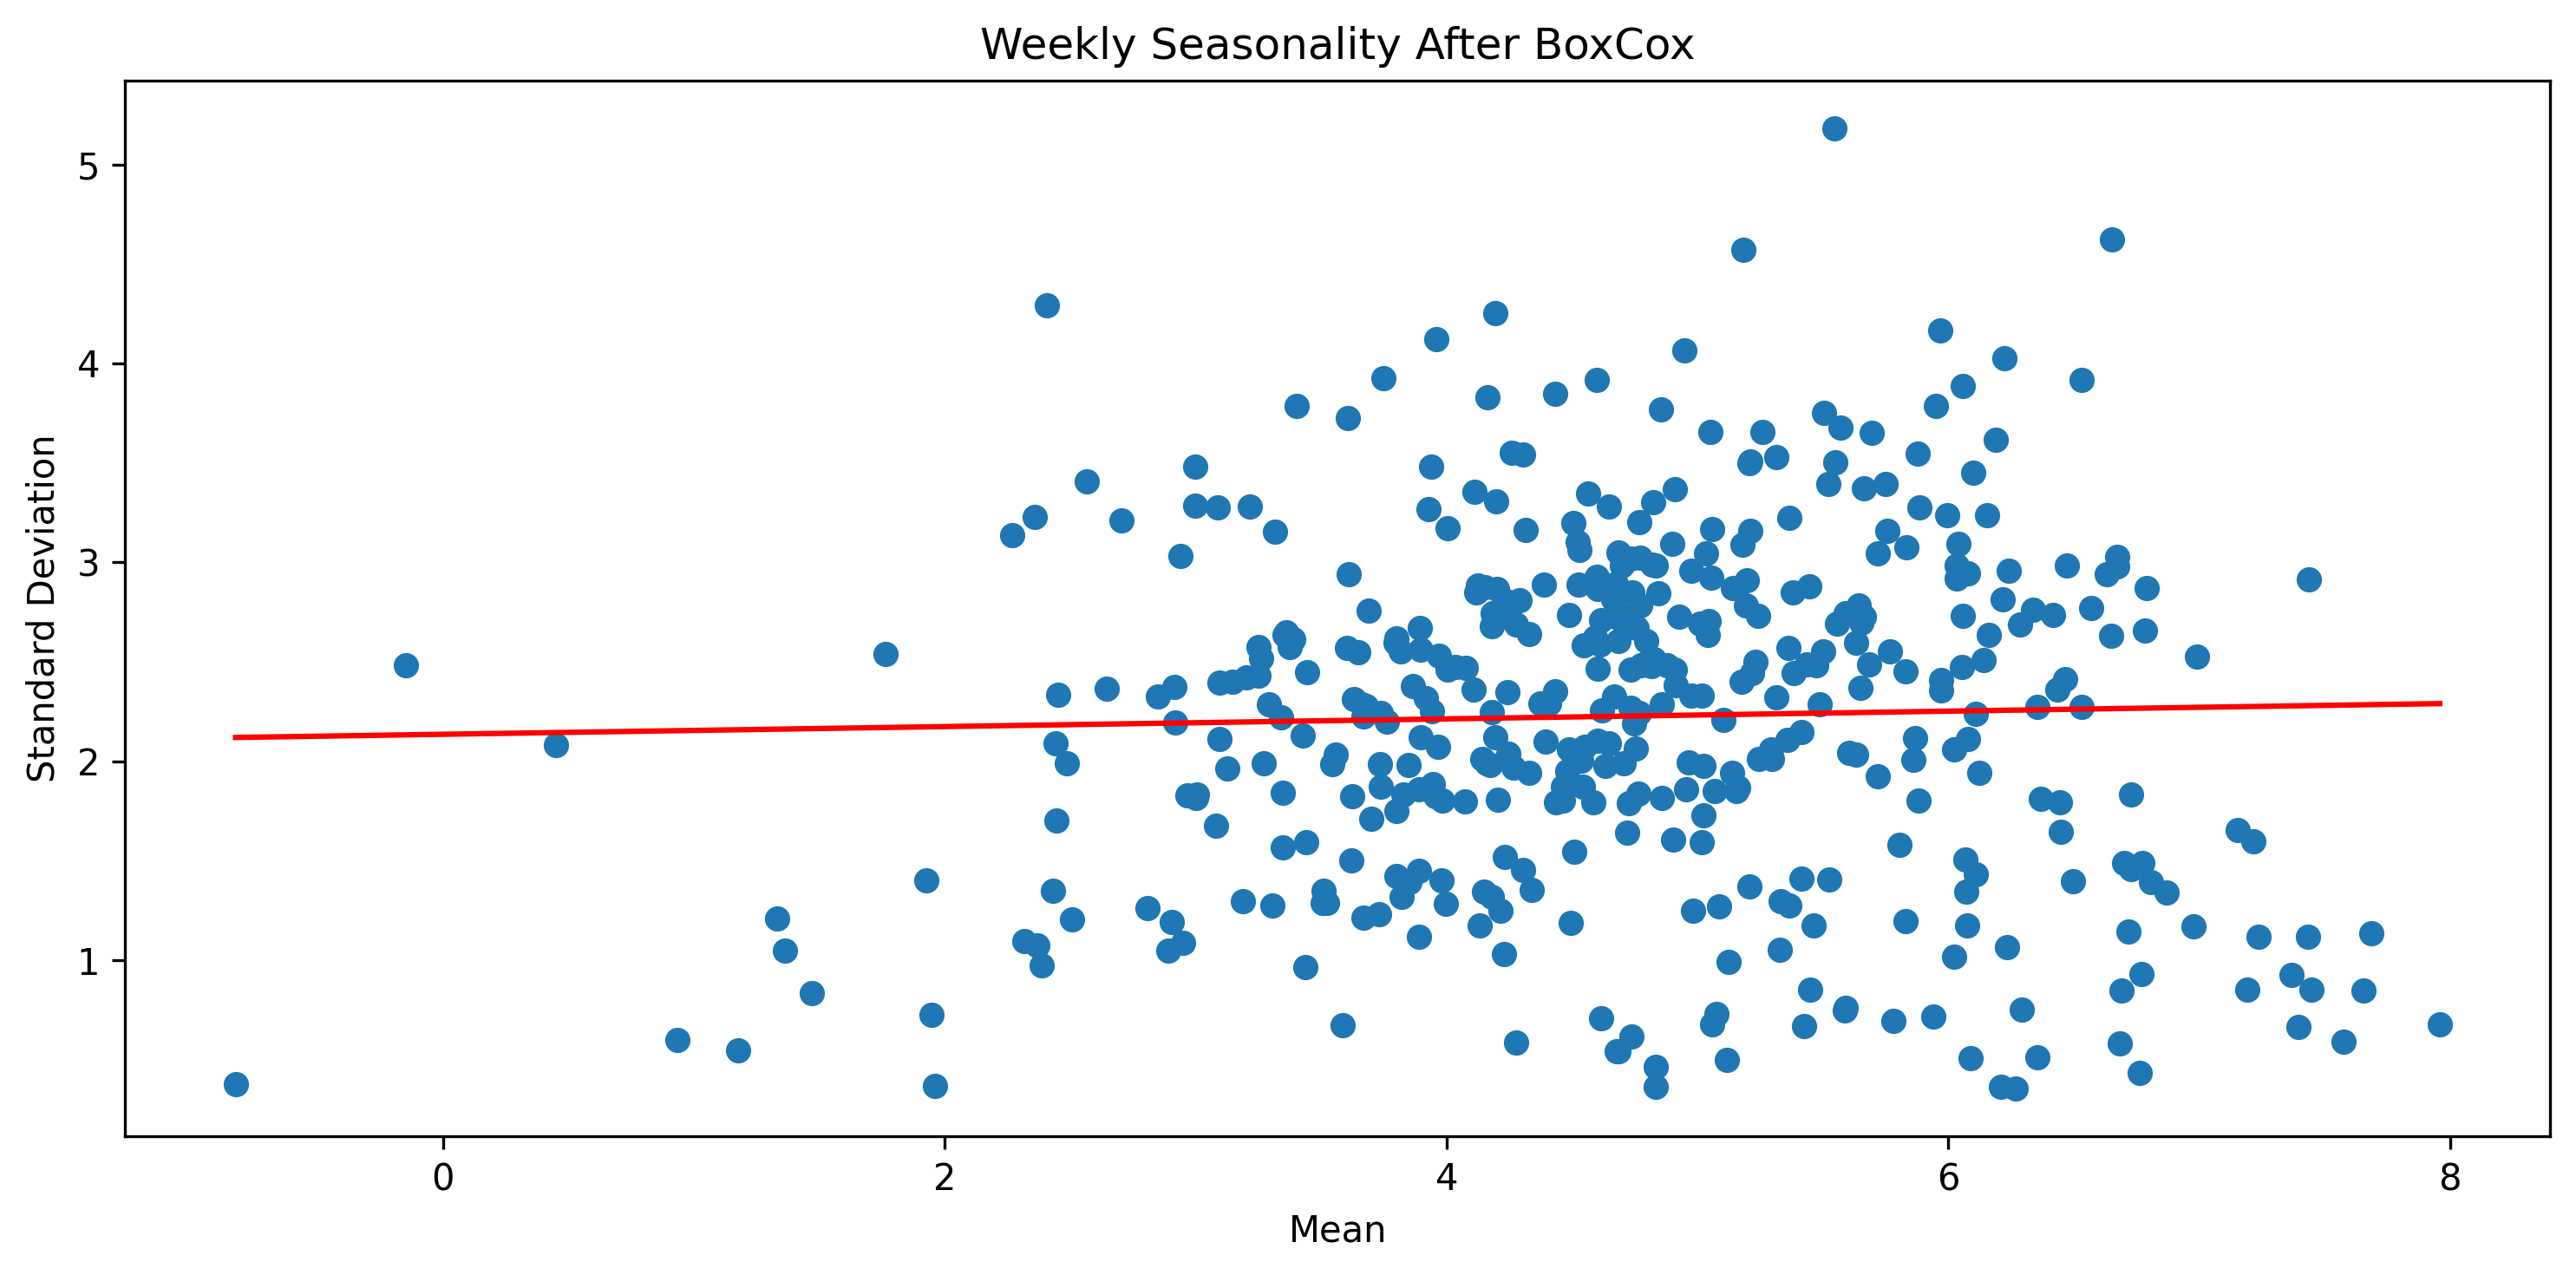

In [ ]:
bc_weekly_means = bc_series.resample('W').mean()
bc_weekly_stdevs = bc_series.resample('W').std()

plt.figure(figsize=(10, 5))
plt.scatter(bc_weekly_means, bc_weekly_stdevs)
plt.title("Weekly Seasonality After BoxCox")
plt.xlabel("Mean")
plt.ylabel("Standard Deviation")
plt.plot(np.unique(bc_weekly_means), np.poly1d(np.polyfit(bc_weekly_means, bc_weekly_stdevs, 1))(np.unique(bc_weekly_means)), color='red')
plt.show()

In [ ]:
adf_test(bc_series)

ADF Statistic: -4.553491660536052
p-value: 0.0001572151153943709
Critical Value (1%): -3.4325462892049194
Critical Value (5%): -2.8625103776222067
Critical Value (10%): -2.5672865579253186


ADF Statistic: -17.556965262285306
p-value: 4.1150266572862584e-30
Critical Value (1%): -3.4325507240185105
Critical Value (5%): -2.862512336314338
Critical Value (10%): -2.5672876007125645


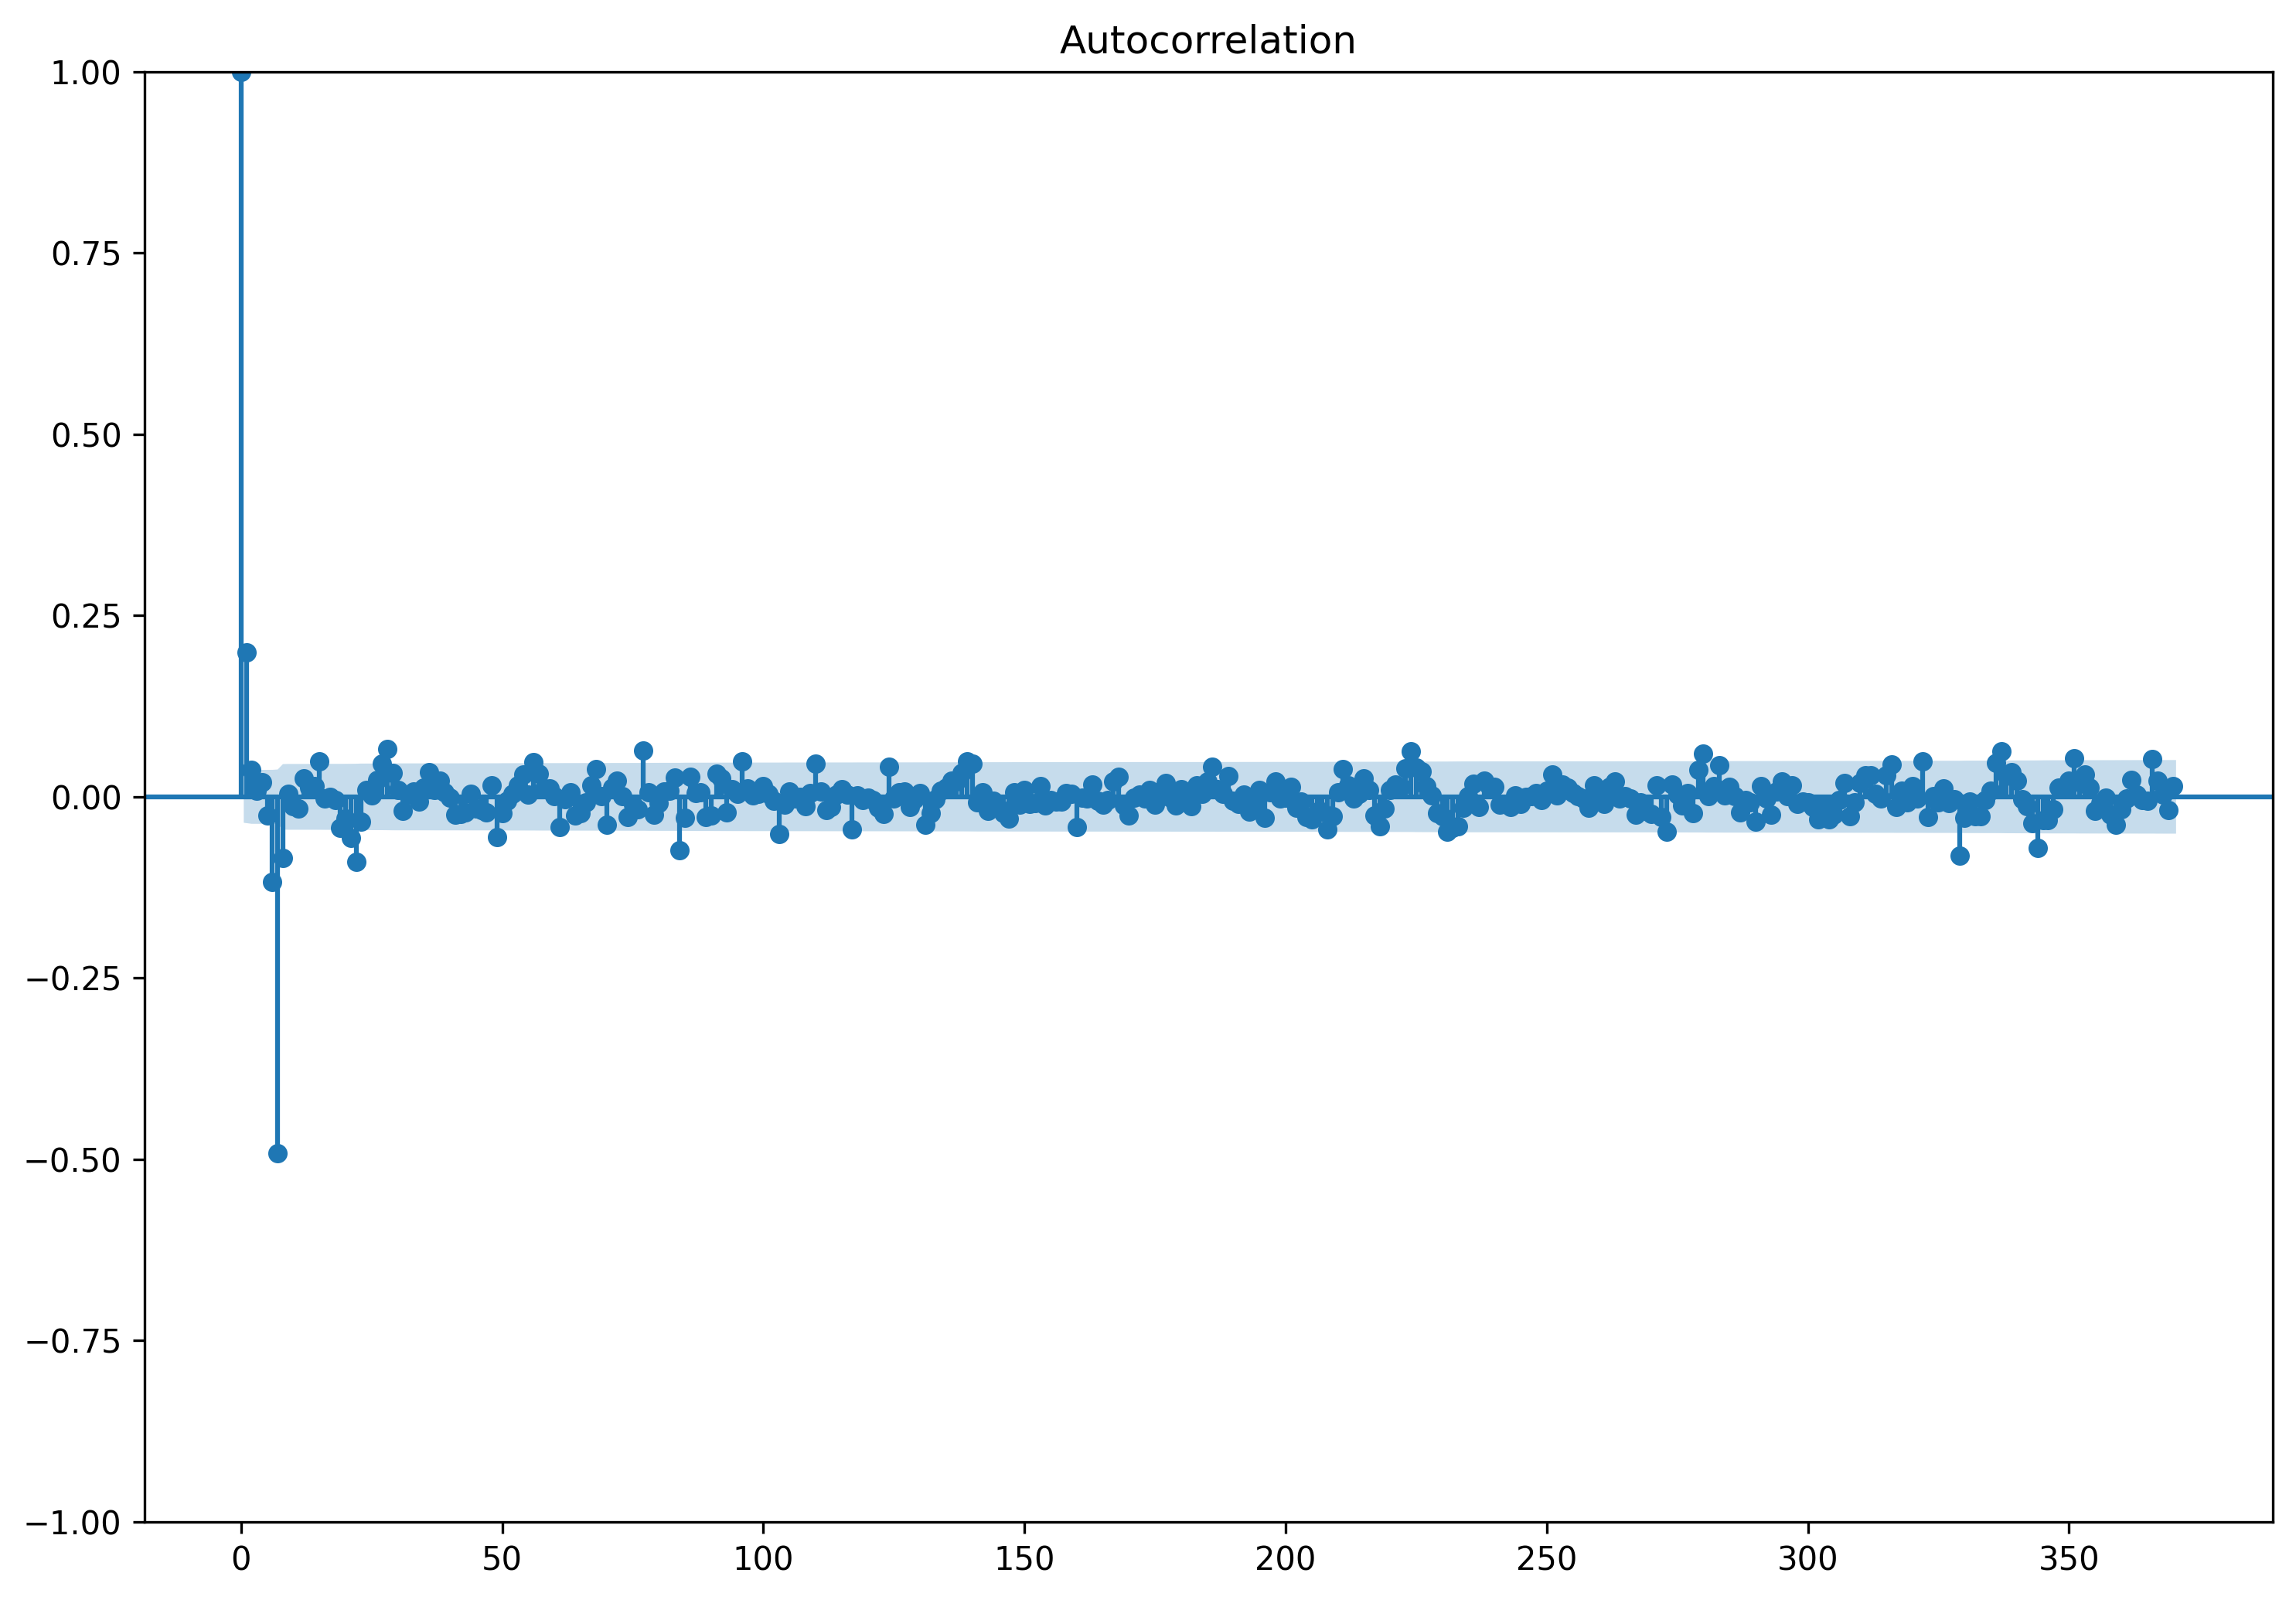

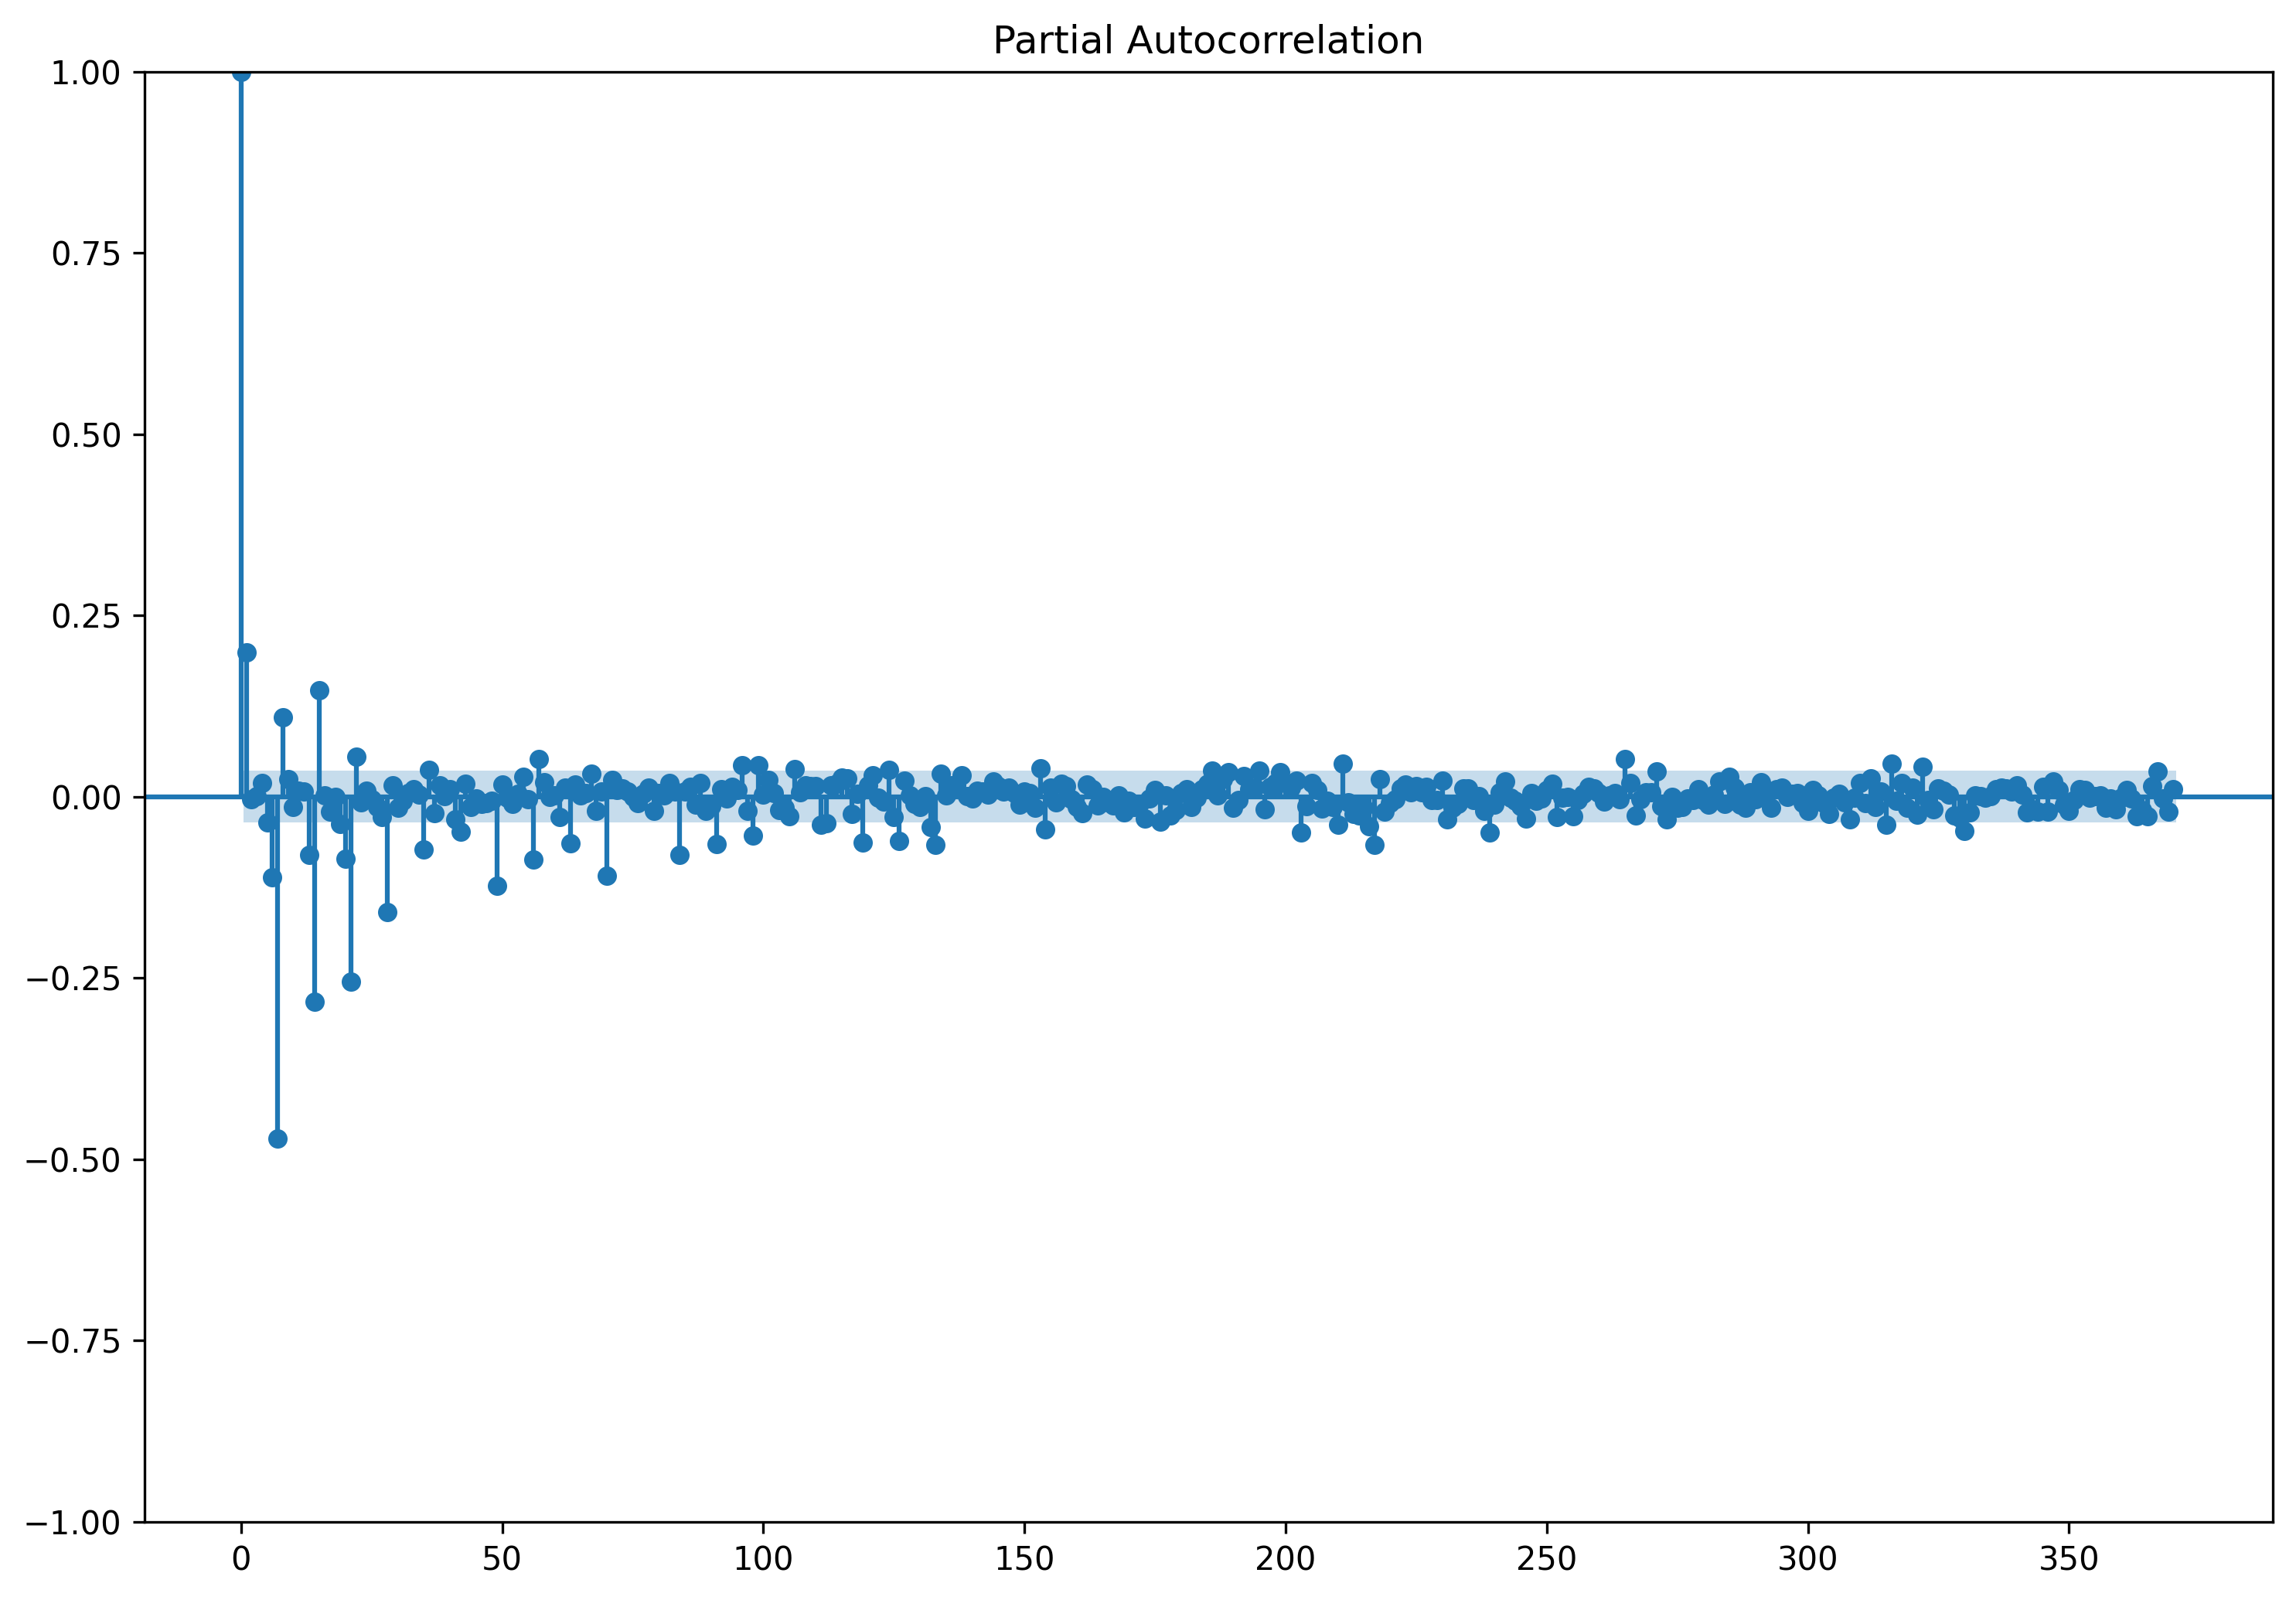

In [ ]:
# Differencing by 7 days
bc_weekly_diff = bc_series.diff(periods=7).dropna()
adf_test(bc_weekly_diff.loc['2007-01-11':])

plot_acf(bc_weekly_diff.dropna(), lags=370)
plt.show()
plot_pacf(bc_weekly_diff.dropna(), lags=370)
plt.show()

## Model 1

In [ ]:
# ARIMA model
train_start_idx, train_end_idx = 0, len(ts_data) - 1  # Replace with actual indices
test_start_idx, test_end_idx = len(ts_data), len(ts_data) + 30  # Example test range
pred_window = 30

mod_arima_1 = SARIMAX(
    ts_data[train_start_idx:train_end_idx],
    order=(0, 0, 0),
    seasonal_order=(0, 1, 2, 7),
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False,
    initialization='approximate_diffuse',
    boxcox_lambda=bc_lambda
).fit()

print(mod_arima_1.summary())

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['boxcox_lambda']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


                                  SARIMAX Results                                   
Dep. Variable:                            y   No. Observations:                 3008
Model:             SARIMAX(0, 1, [1, 2], 7)   Log Likelihood              -13564.926
Date:                      Tue, 07 Jan 2025   AIC                          27137.851
Time:                              10:29:36   BIC                          27161.887
Sample:                          01-04-2007   HQIC                         27146.496
                               - 03-30-2015                                         
Covariance Type:                        opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0919      0.075      1.226      0.220      -0.055       0.239
ma.S.L7       -0.8099      0.012    -65.323      0.000      -0.834      -0.786
ma.S

In [ ]:
forecast_values = mod_arima_1.get_forecast(steps=pred_window)
pred_mean = forecast_values.predicted_mean

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['boxcox_lambda']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


In [ ]:
# # Replace test_start, test_end with actual date range
# # Get the last date in your original data
# last_date_in_data = ts_data.index[-1]

# # Create test_dates starting from the day after the last date in your data
# test_dates = pd.date_range(start=last_date_in_data + pd.DateOffset(days=1), periods=pred_window, freq='D')

# # Now proceed with creating predicted_series, actual_series, and plotting
# predicted_series = pd.Series(pred_mean, index=test_dates)

# # Create a combined index with both historical and prediction dates
# combined_index = ts_data.index.union(test_dates)

# # Reindex ts_data to include future dates with NaN values
# #actual_series = ts_data.reindex(combined_index)
# # residuals = actual_series - predicted_series
# # Now, plot both series:
# # ... (your existing code to create test_dates and predicted_series)

# # Extract actual data for the prediction period
# actual_series_pred_period = ts_data.loc[test_dates[0]:test_dates[-1]]

# # Now plot both series
# plt.figure(figsize=(12, 6))
# plt.plot(actual_series_pred_period, label='Actual', color='black')
# plt.plot(predicted_series, label='Forecast', color='blue')
# plt.title("ARIMA 1 Forecast vs. Actual")
# plt.legend()
# plt.show()

## Model 2

In [ ]:
ts_boxcox, lambda_used = boxcox(ts_data)
ts_boxcox_series = pd.Series(ts_boxcox, index=ts_data.index)

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 17.3 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=20.45 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=17081.917, Time=0.13 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=16102.978, Time=2.52 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=inf, Time=25.14 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,1)(2,0,1)[7]             : AIC=inf, Time=6.08 sec

Best model:  ARIMA(1,1,1)(2,0,1)[7] intercept
Total fit time: 299.474 seconds
                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                 3009
Model:             SARIMAX(1, 1, 1)x(2, 0, 1, 7)   Log Likelihood               -7170.540
Date:                           Tue, 07 Jan 2025   AIC                          14355.081
Time:                                   15:32:53   BIC                          14397.144
Sample:                               01-04-2007   HQIC                         14370.209
                                    - 03-31-2015                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


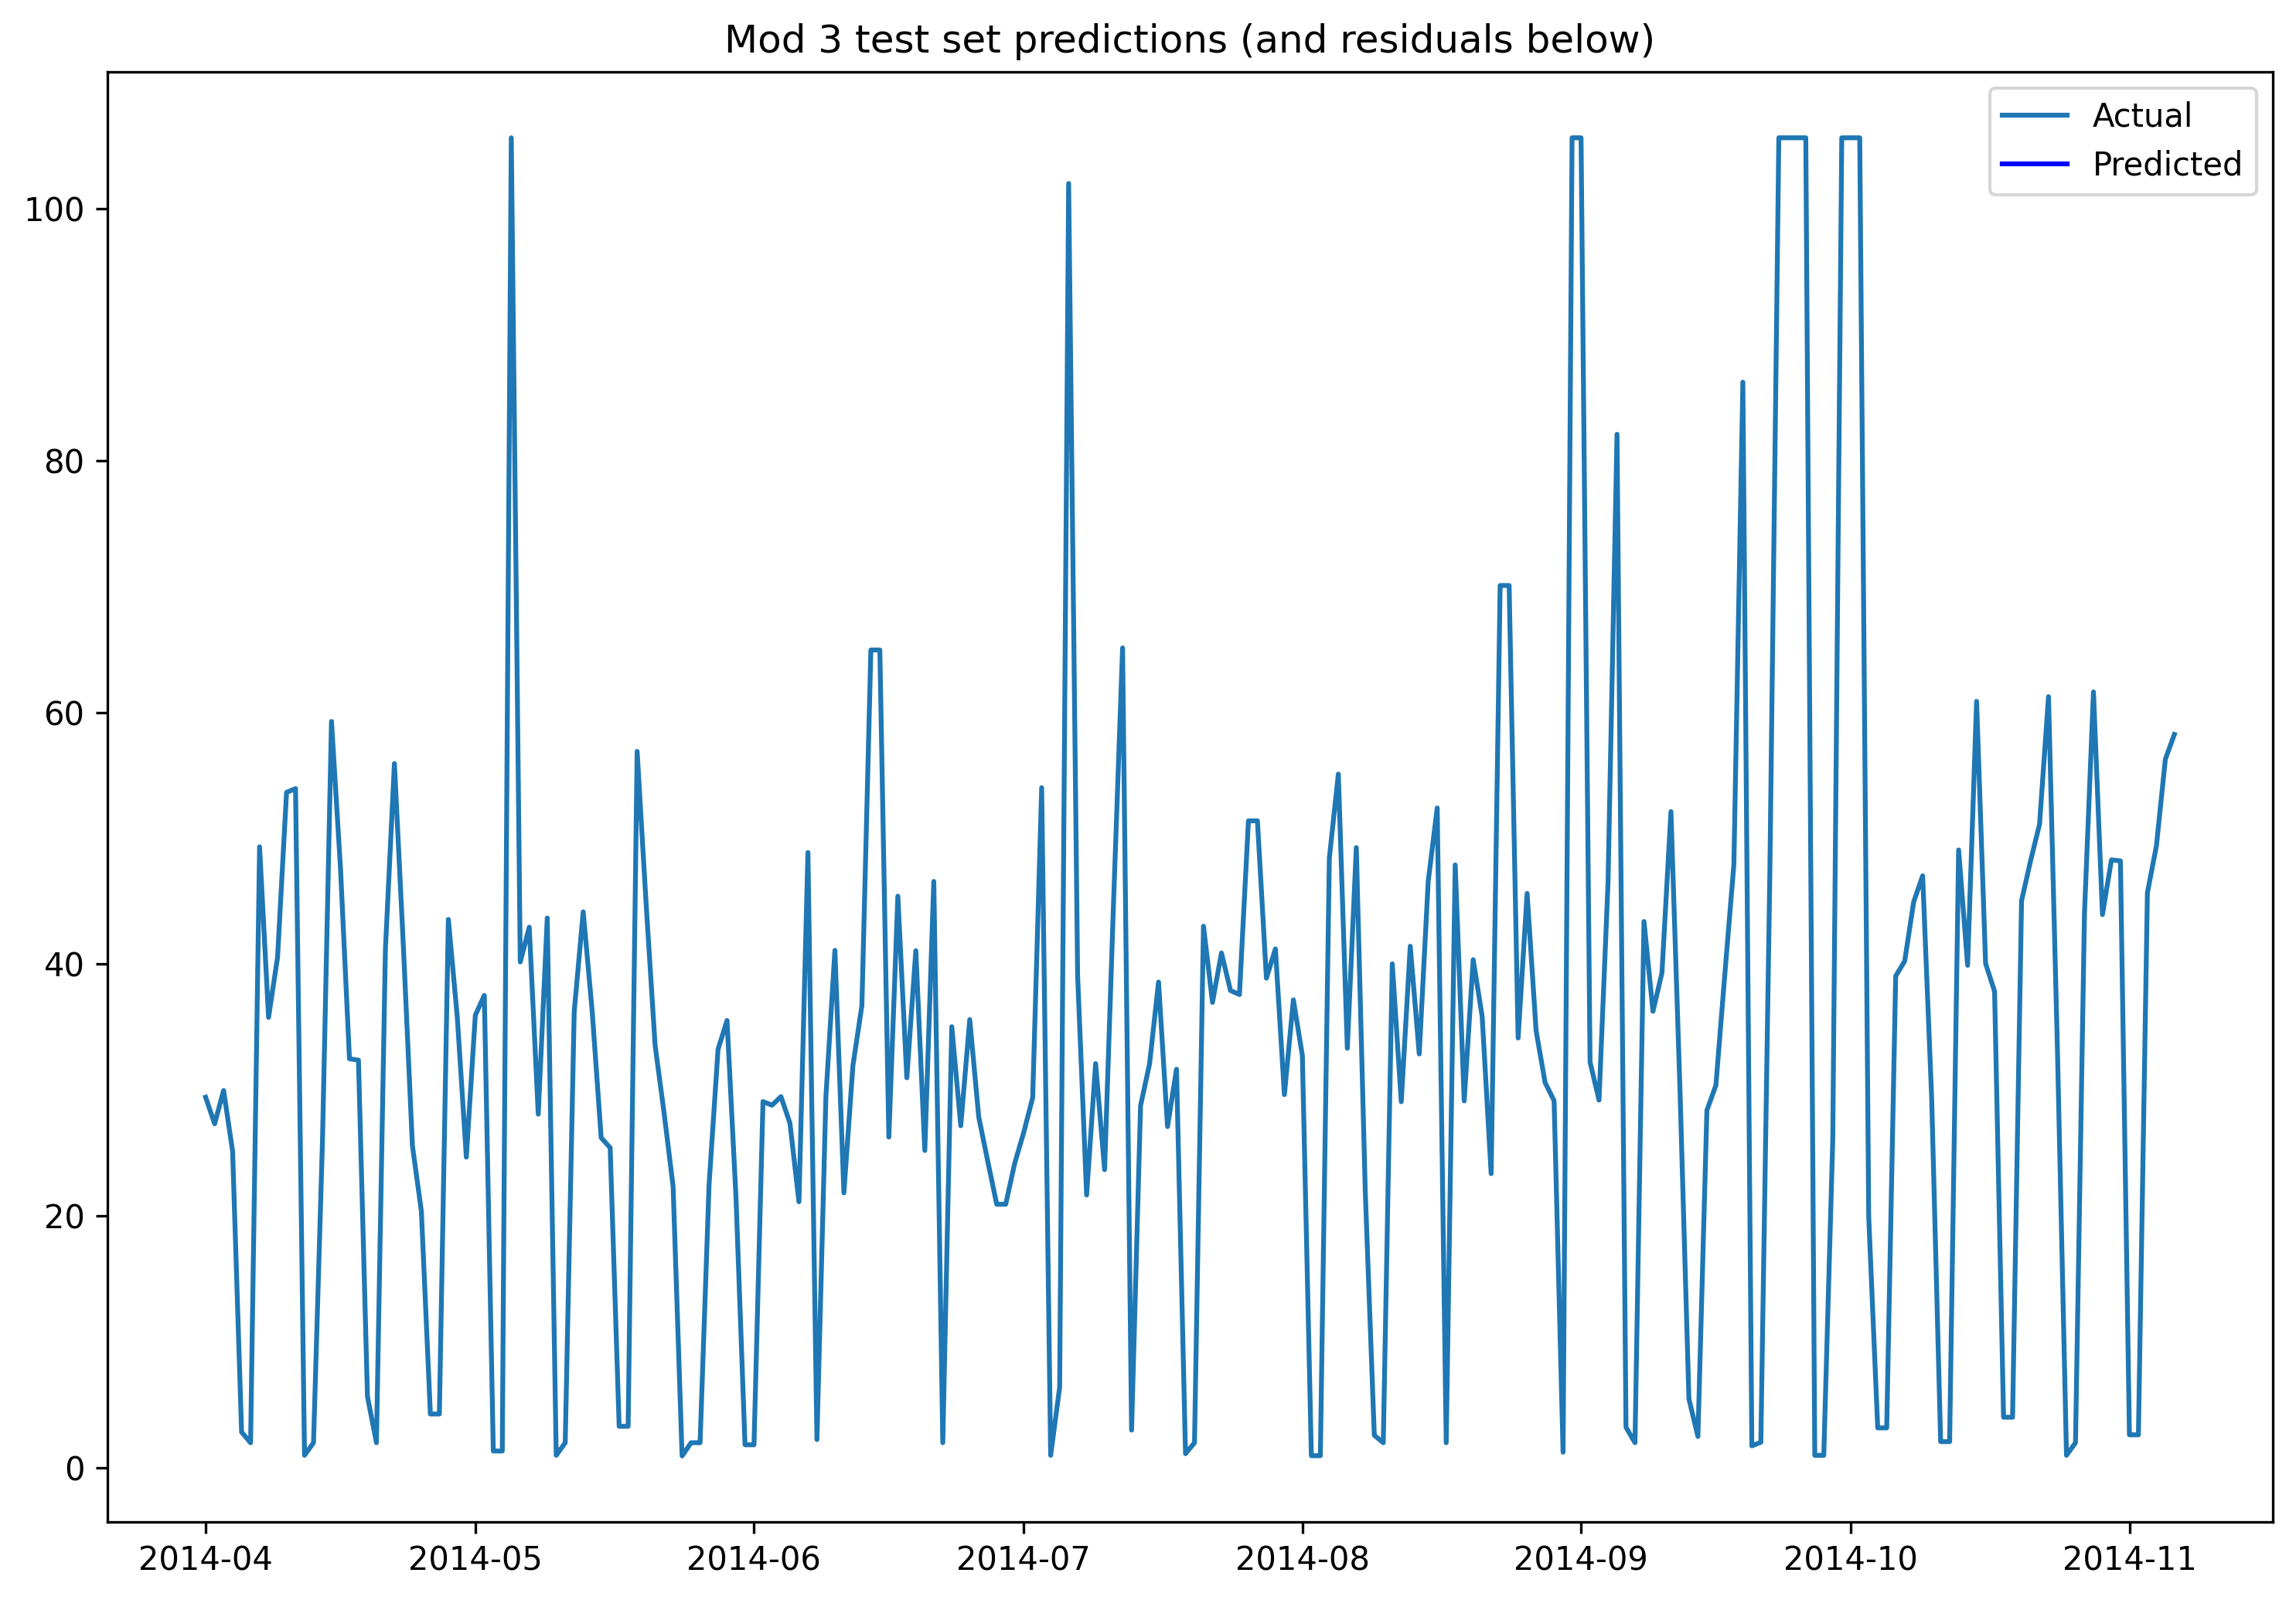

In [ ]:
from pmdarima import auto_arima
from scipy.special import inv_boxcox
import pandas as pd
import matplotlib.pyplot as plt

# Fit model on transformed series
auto_model = auto_arima(ts_boxcox_series, seasonal=True, m=7, stepwise=True, trace=True)
print(auto_model.summary())

# Predict on test set (ensure correct forecast steps)
test_length = len(ts.iloc[test_start_idx:test_end_idx])
auto_model_forecast_boxcox = auto_model.predict(n_periods=test_length)




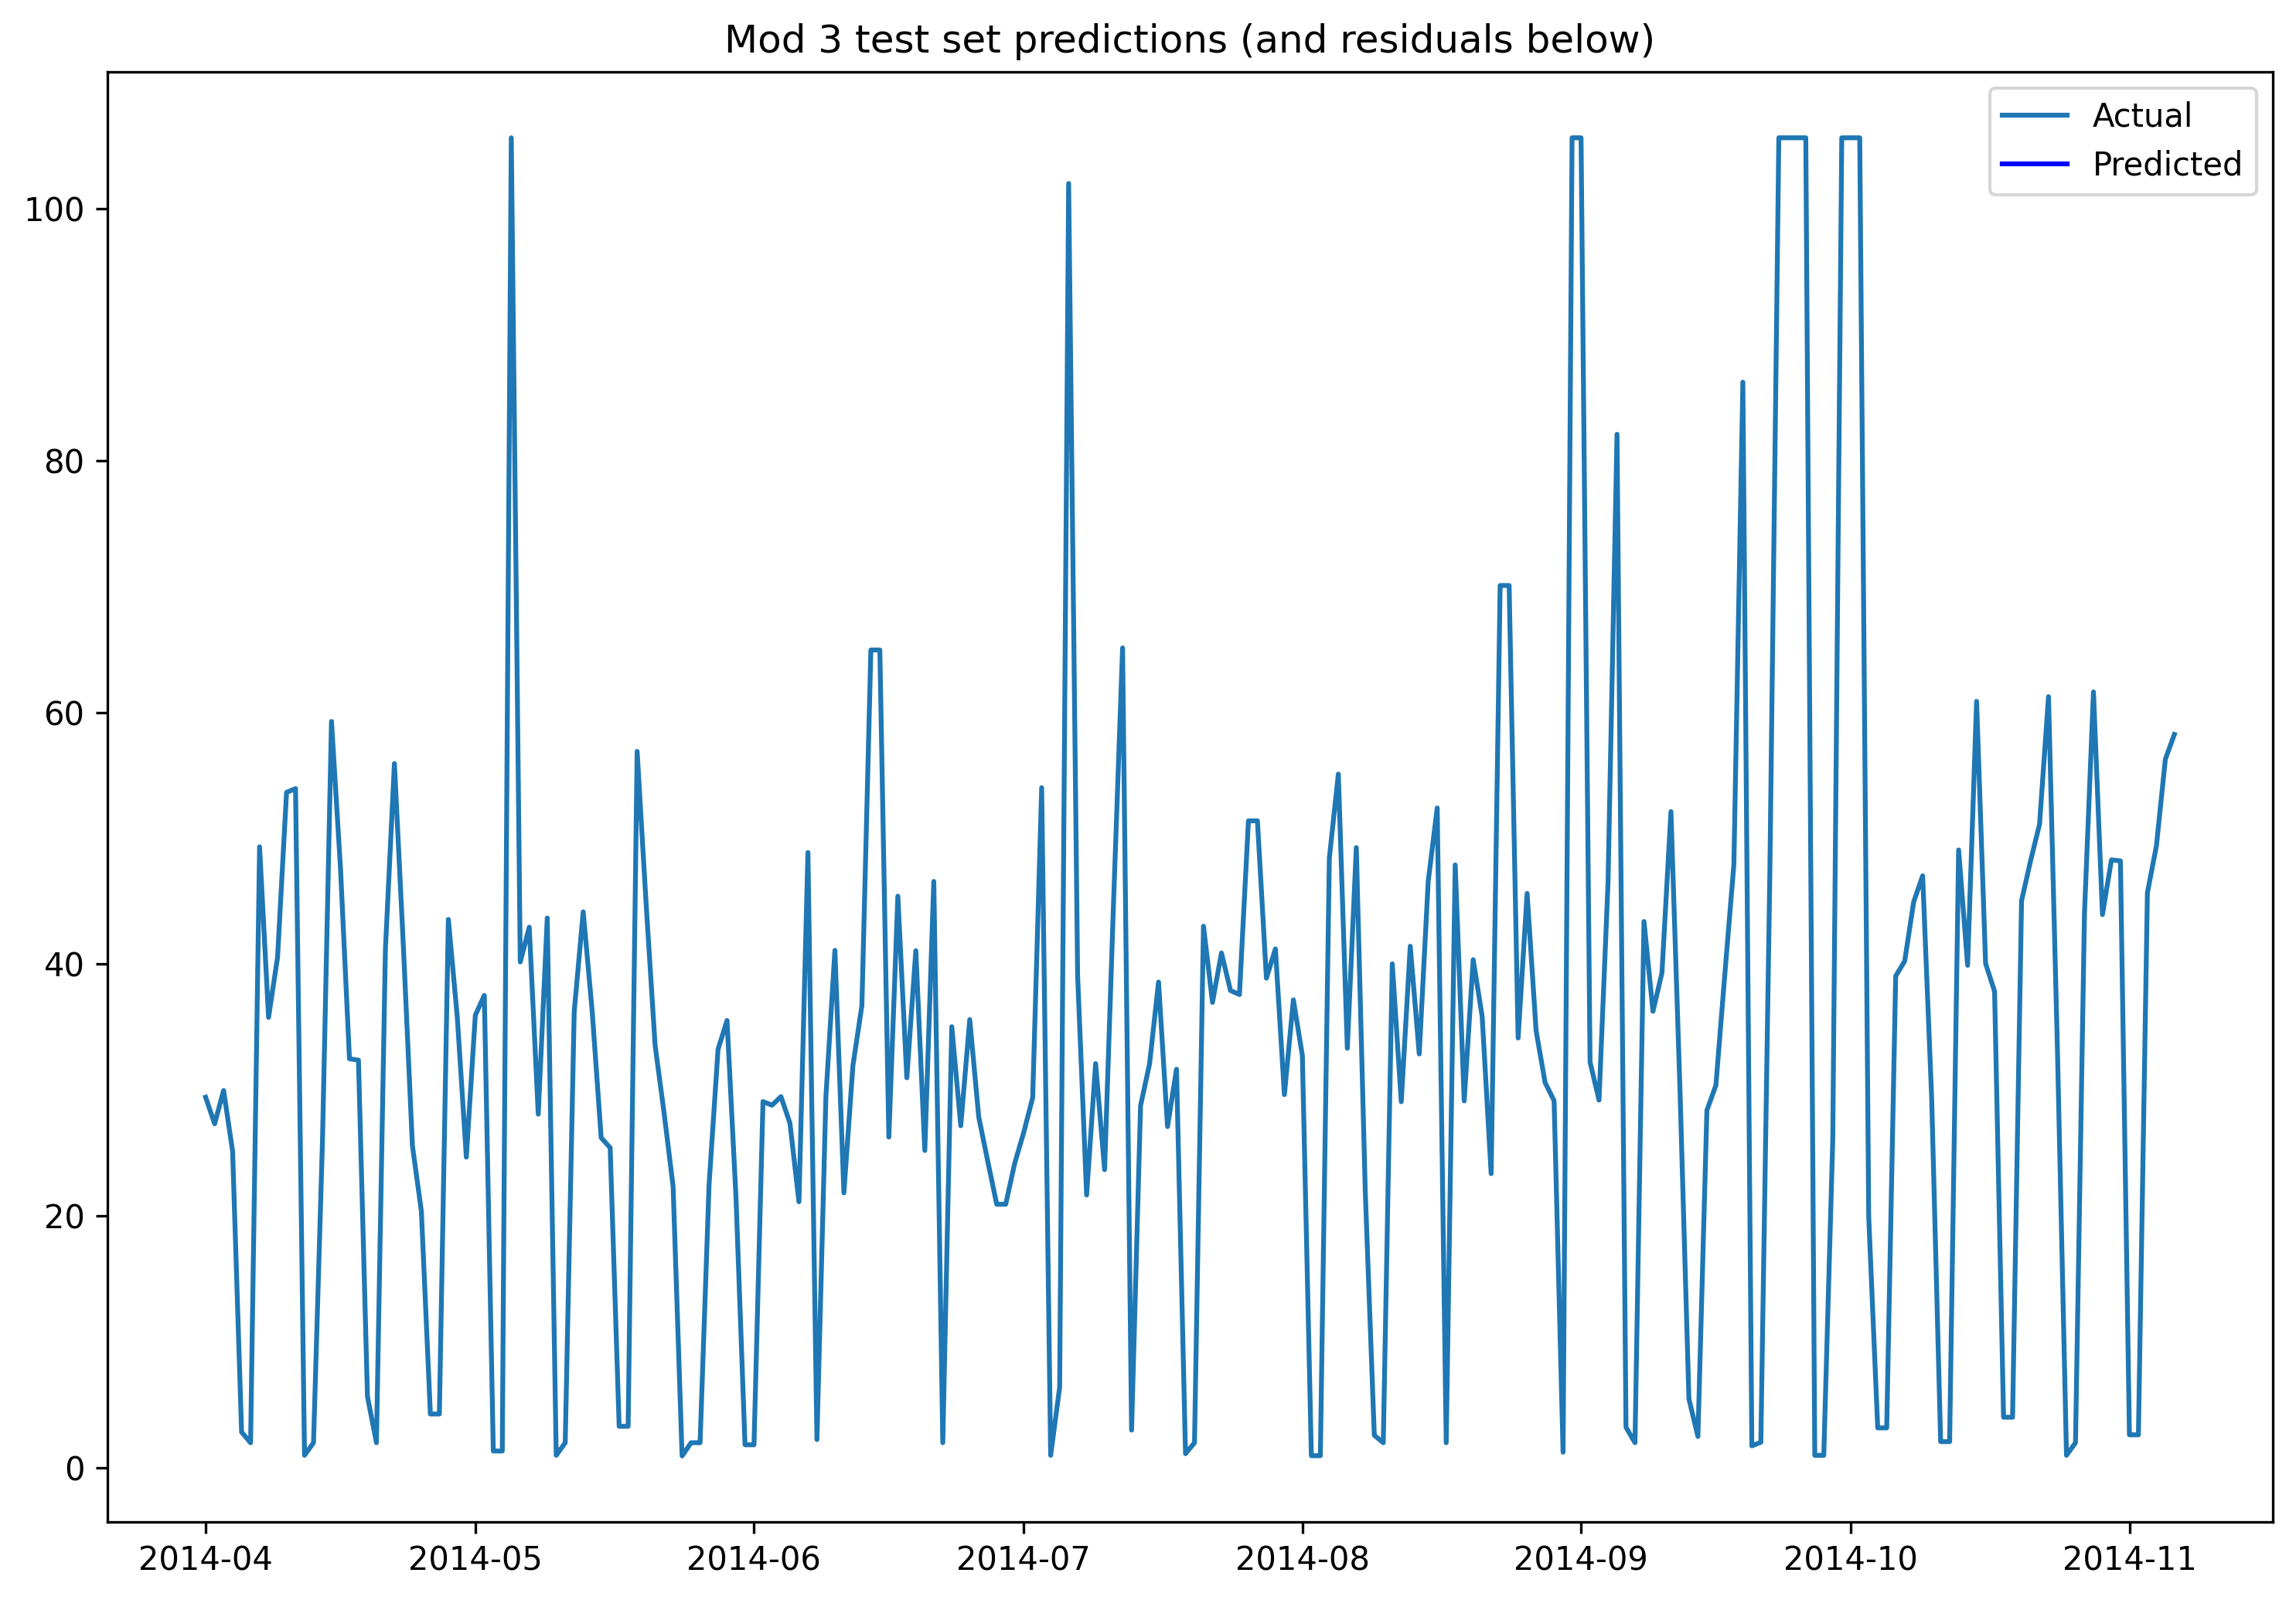

In [ ]:
# Reverse Box-Cox transformation
lambda_value = 0.5  # Replace with the correct lambda
autoarima_forecast_values = inv_boxcox(auto_model_forecast_boxcox, lambda_value)

# Align predictions with the date index of the test set
date_range_for_test = ts.index[test_start_idx:test_end_idx]
auto_model_pre_values = pd.Series(autoarima_forecast_values, index=date_range_for_test)

# Plot actual vs. predicted
plt.plot(ts.iloc[test_start_idx:test_end_idx], label='Actual', linewidth=1.5)
plt.plot(auto_model_pre_values, label='Predicted', color='blue', linewidth=1.5)
plt.title("Mod 3 test set predictions (and residuals below)")
plt.legend()
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


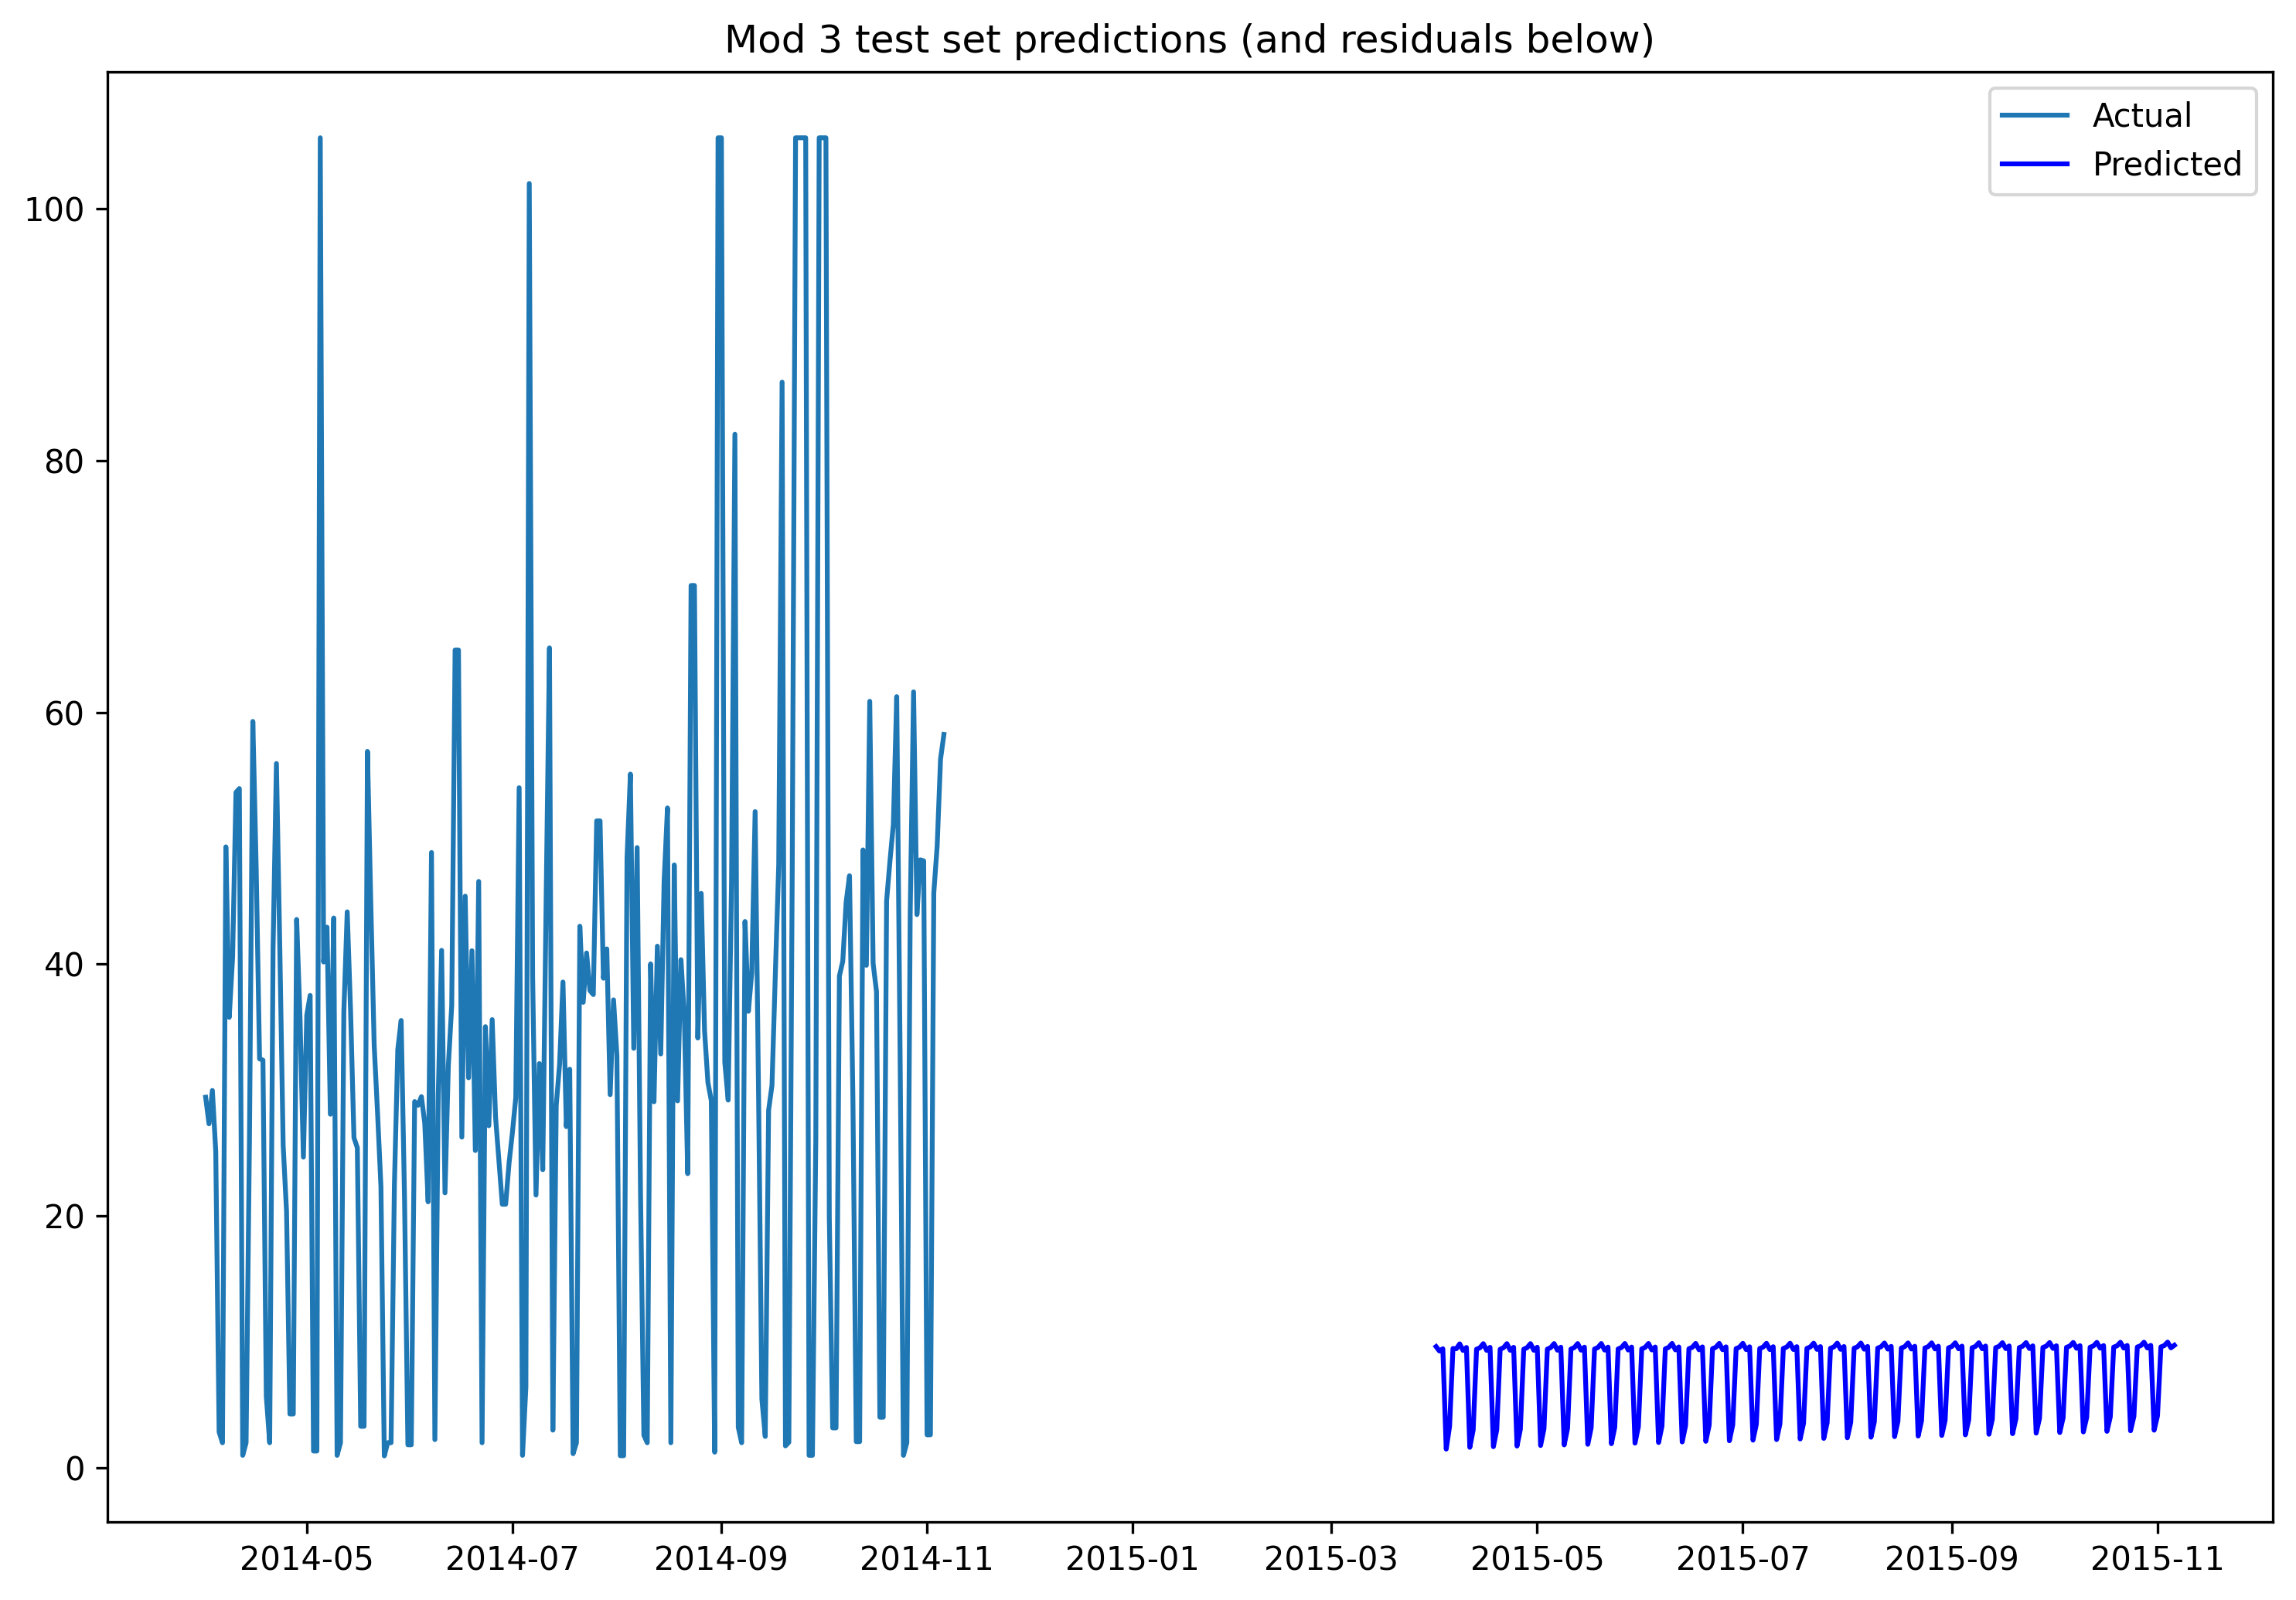

In [ ]:
# Import the necessary library
from pmdarima.arima import ARIMA
# Assuming you've already fitted the model with auto_arima

# Instead of:
# auto_model_forecast = auto_model.forecast(steps=len(ts.iloc[test_start_idx:test_end_idx]))

# You should either call `predict` method
# OR call the `get_prediction` method and then access `.predicted_mean`
# For `predict`:
auto_model_forecast = auto_model.predict(n_periods=len(ts.iloc[test_start_idx:test_end_idx]))

# For `get_prediction`:
# auto_model_forecast = auto_model.get_prediction(start=test_start, end=test_end).predicted_mean
# Please adjust the start and end dates according to your need

# Rename the variable for clarity (Optional)
# This helps distinguish between the forecast and the mean values
autoarima_forecast_values = auto_model_forecast

# Now you can create your DataFrame
auto_model_pre_values = pd.Series(autoarima_forecast_values, index=pd.date_range(start=test_start, periods=len(ts.iloc[test_start_idx:test_end_idx])))

# The rest of your code should work as expected
plt.plot(ts.iloc[test_start_idx:test_end_idx], label='Actual', linewidth=1.5)
plt.plot(autoarima_forecast_values, label='Predicted', color='blue', linewidth=1.5)
plt.title("Mod 3 test set predictions (and residuals below)")
plt.legend()
plt.show()

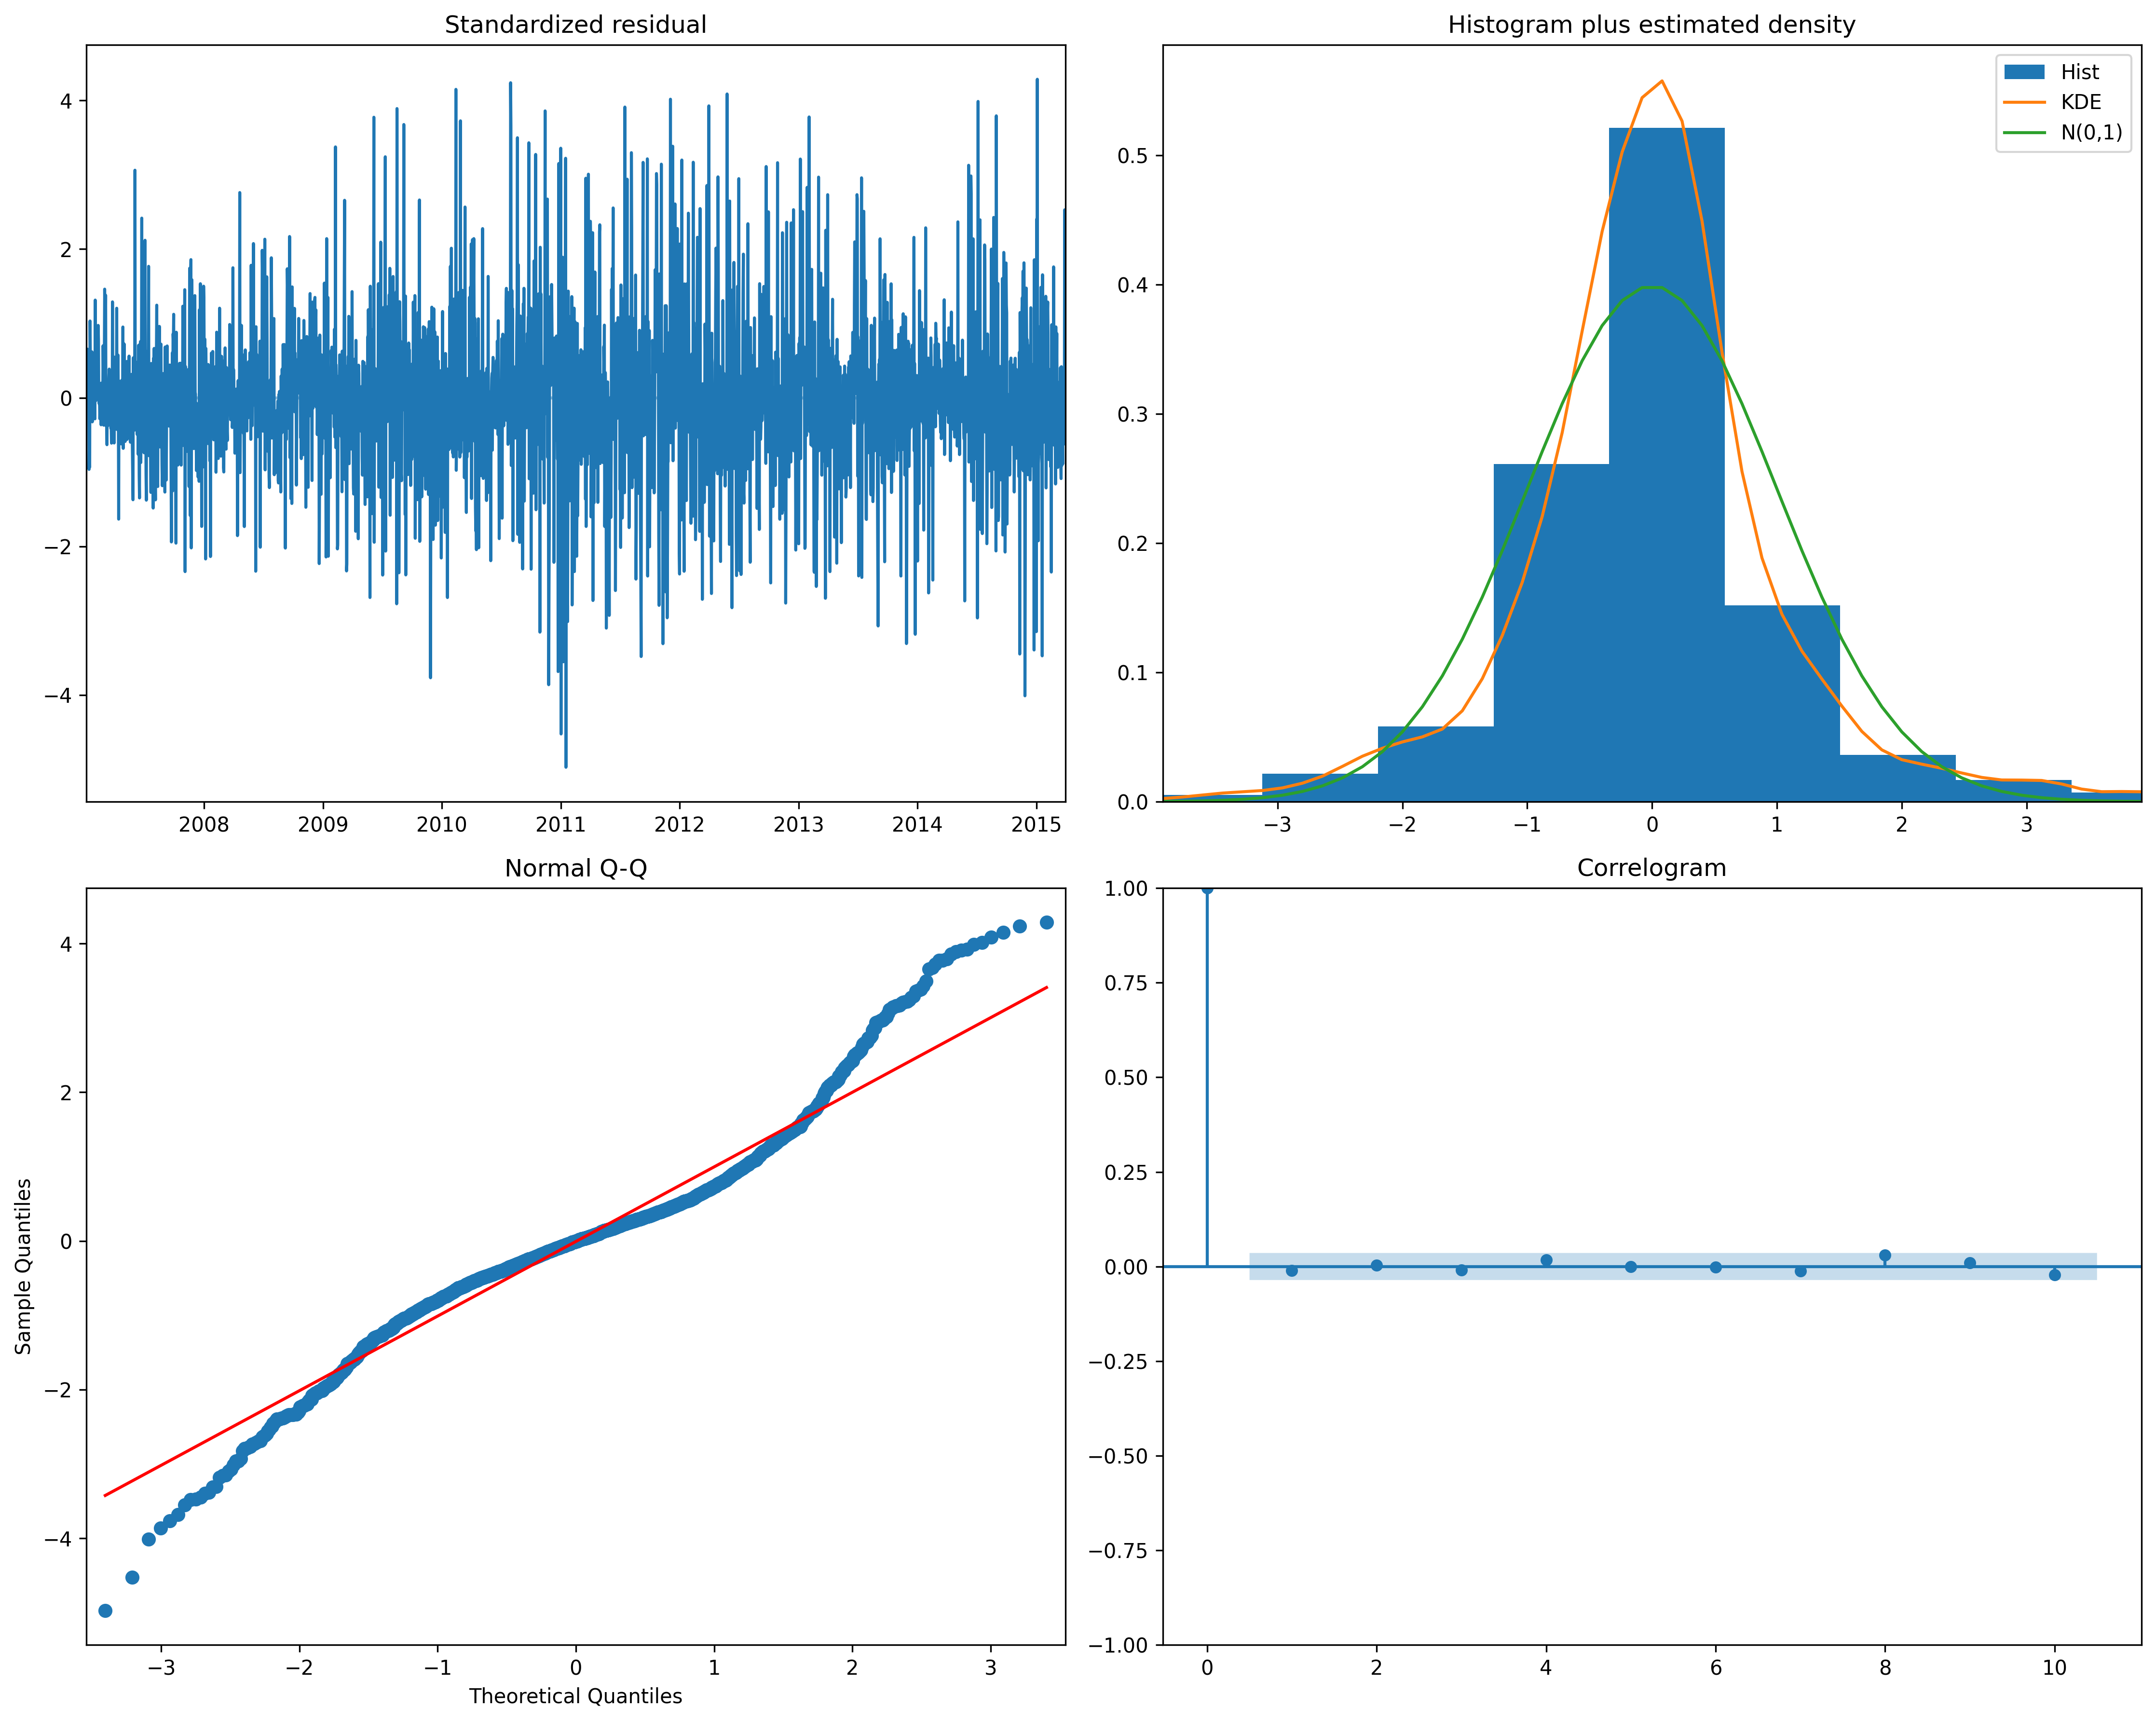

In [ ]:
# Print model summary and diagnostics
auto_model.plot_diagnostics(figsize=(15, 12))
plt.show()

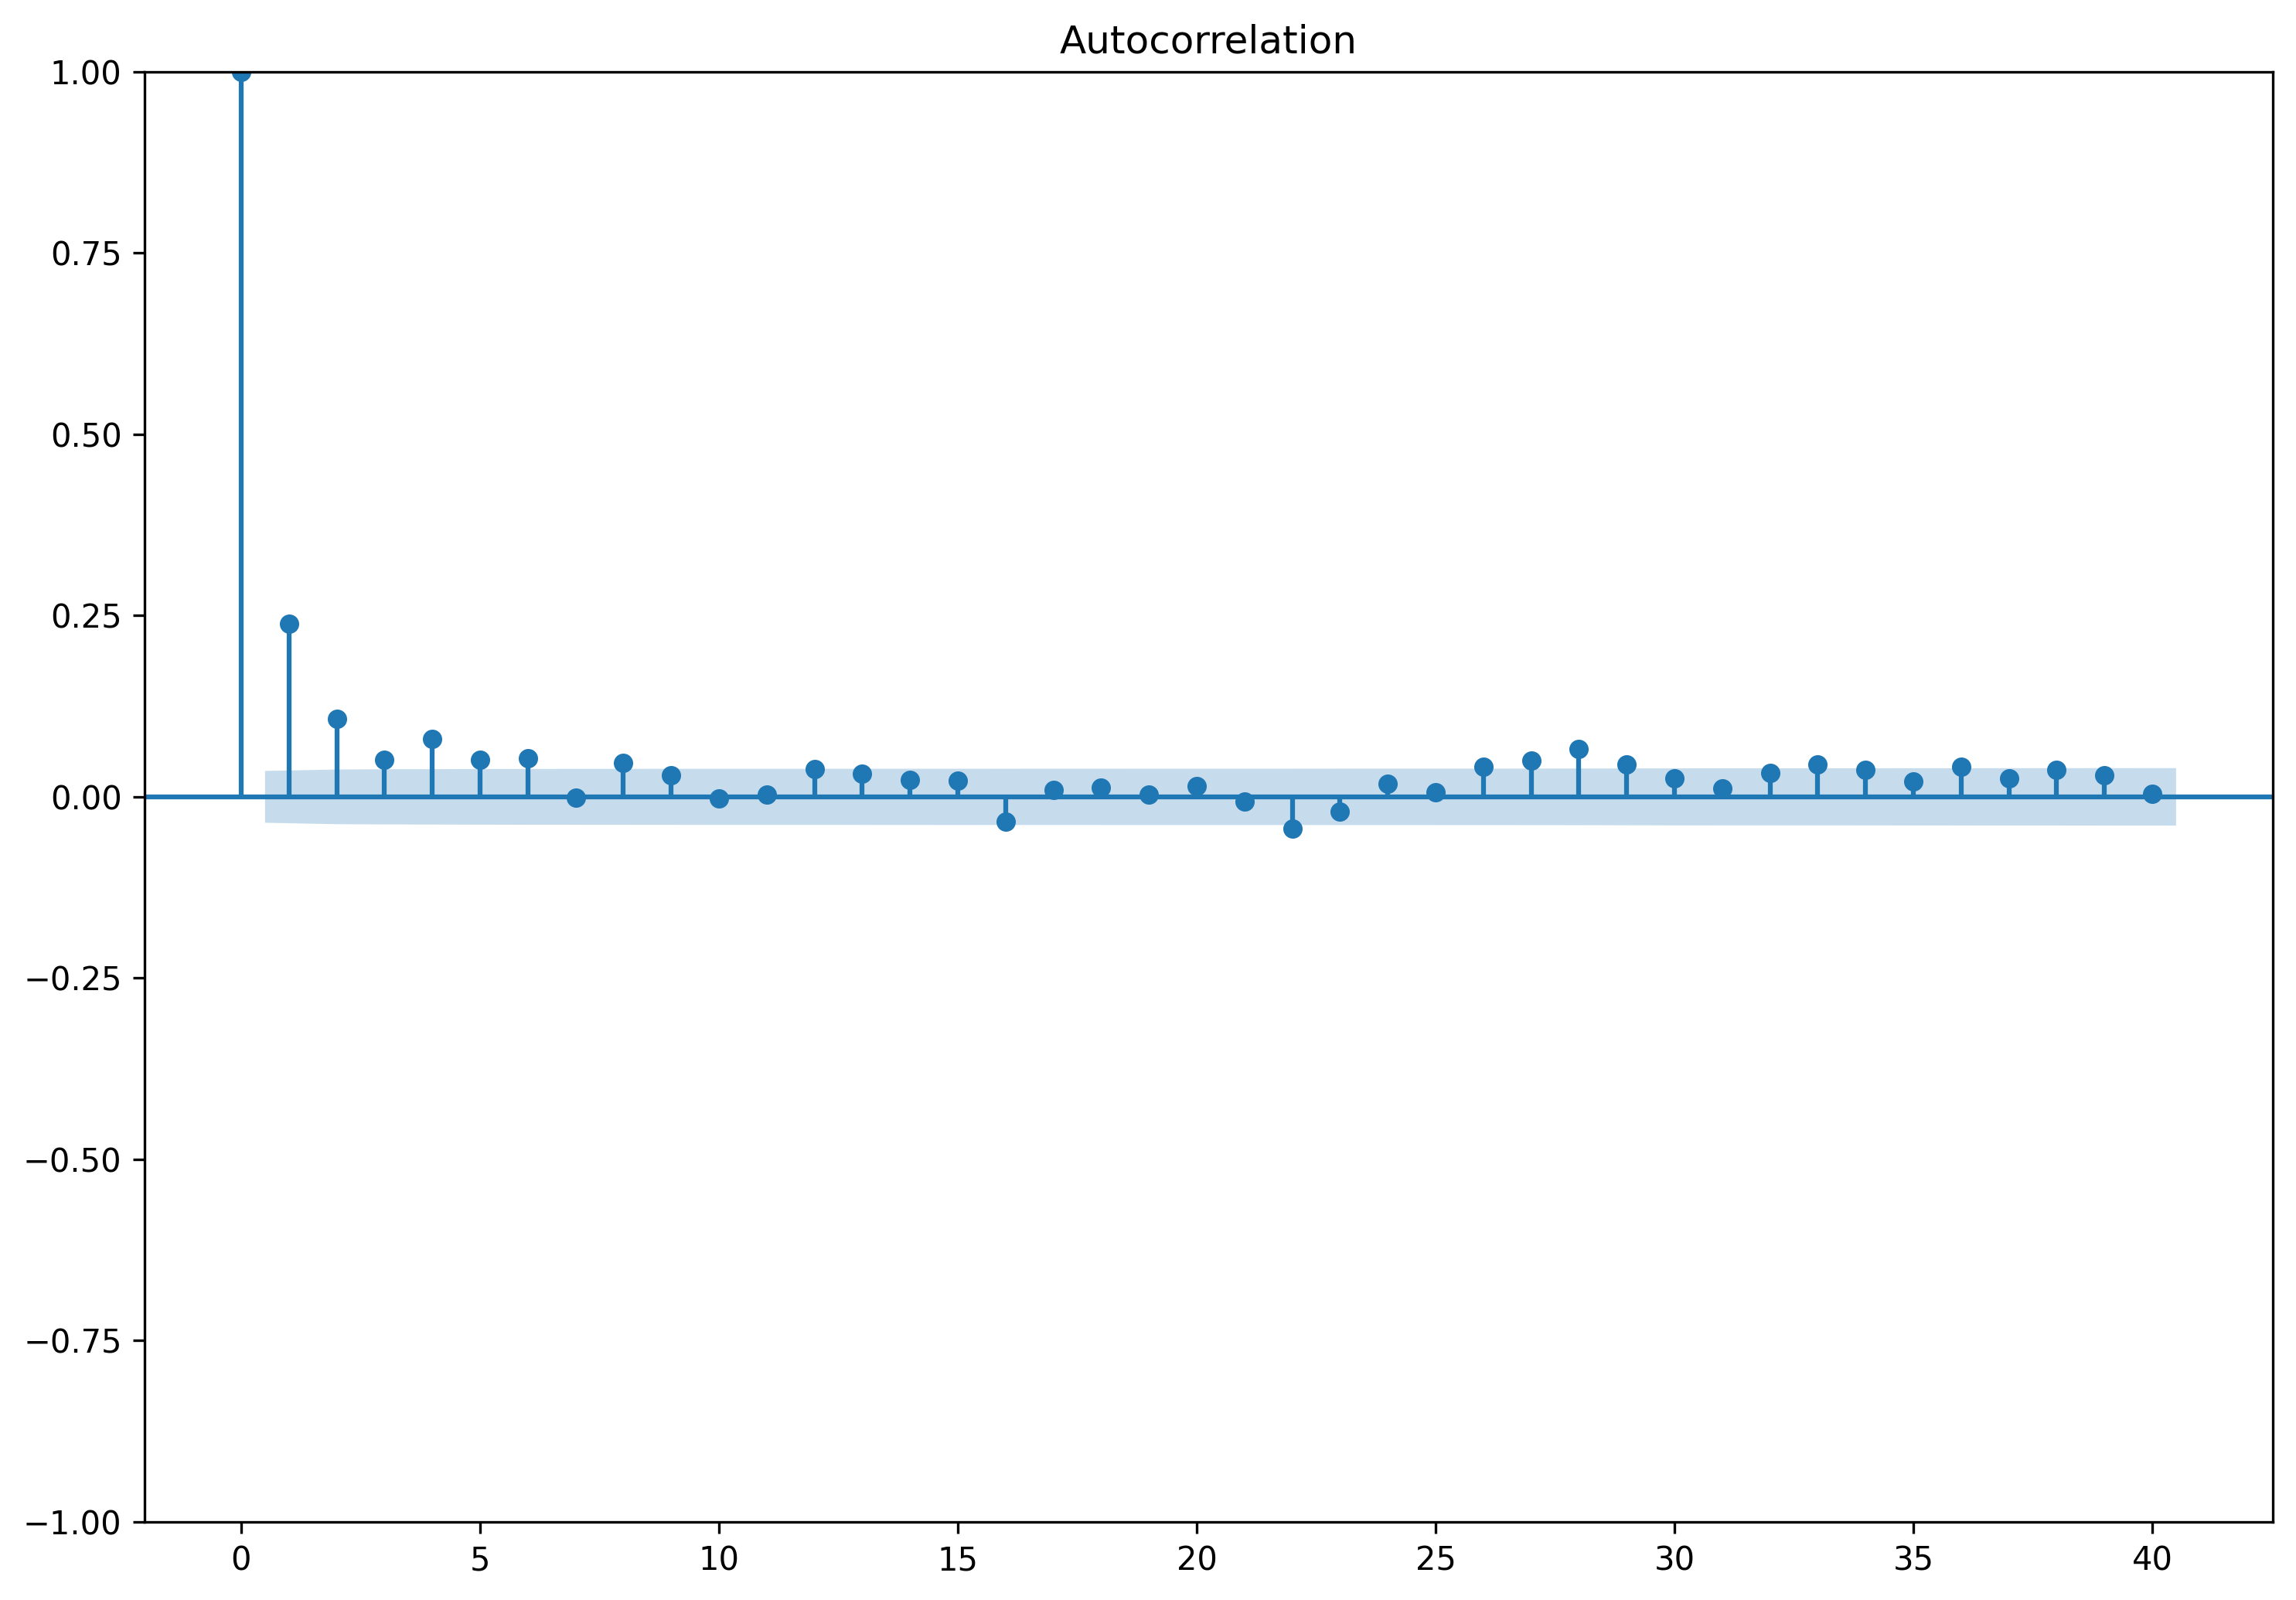

In [ ]:
plot_acf(mod_arima_1.resid, lags=40)
plt.show()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


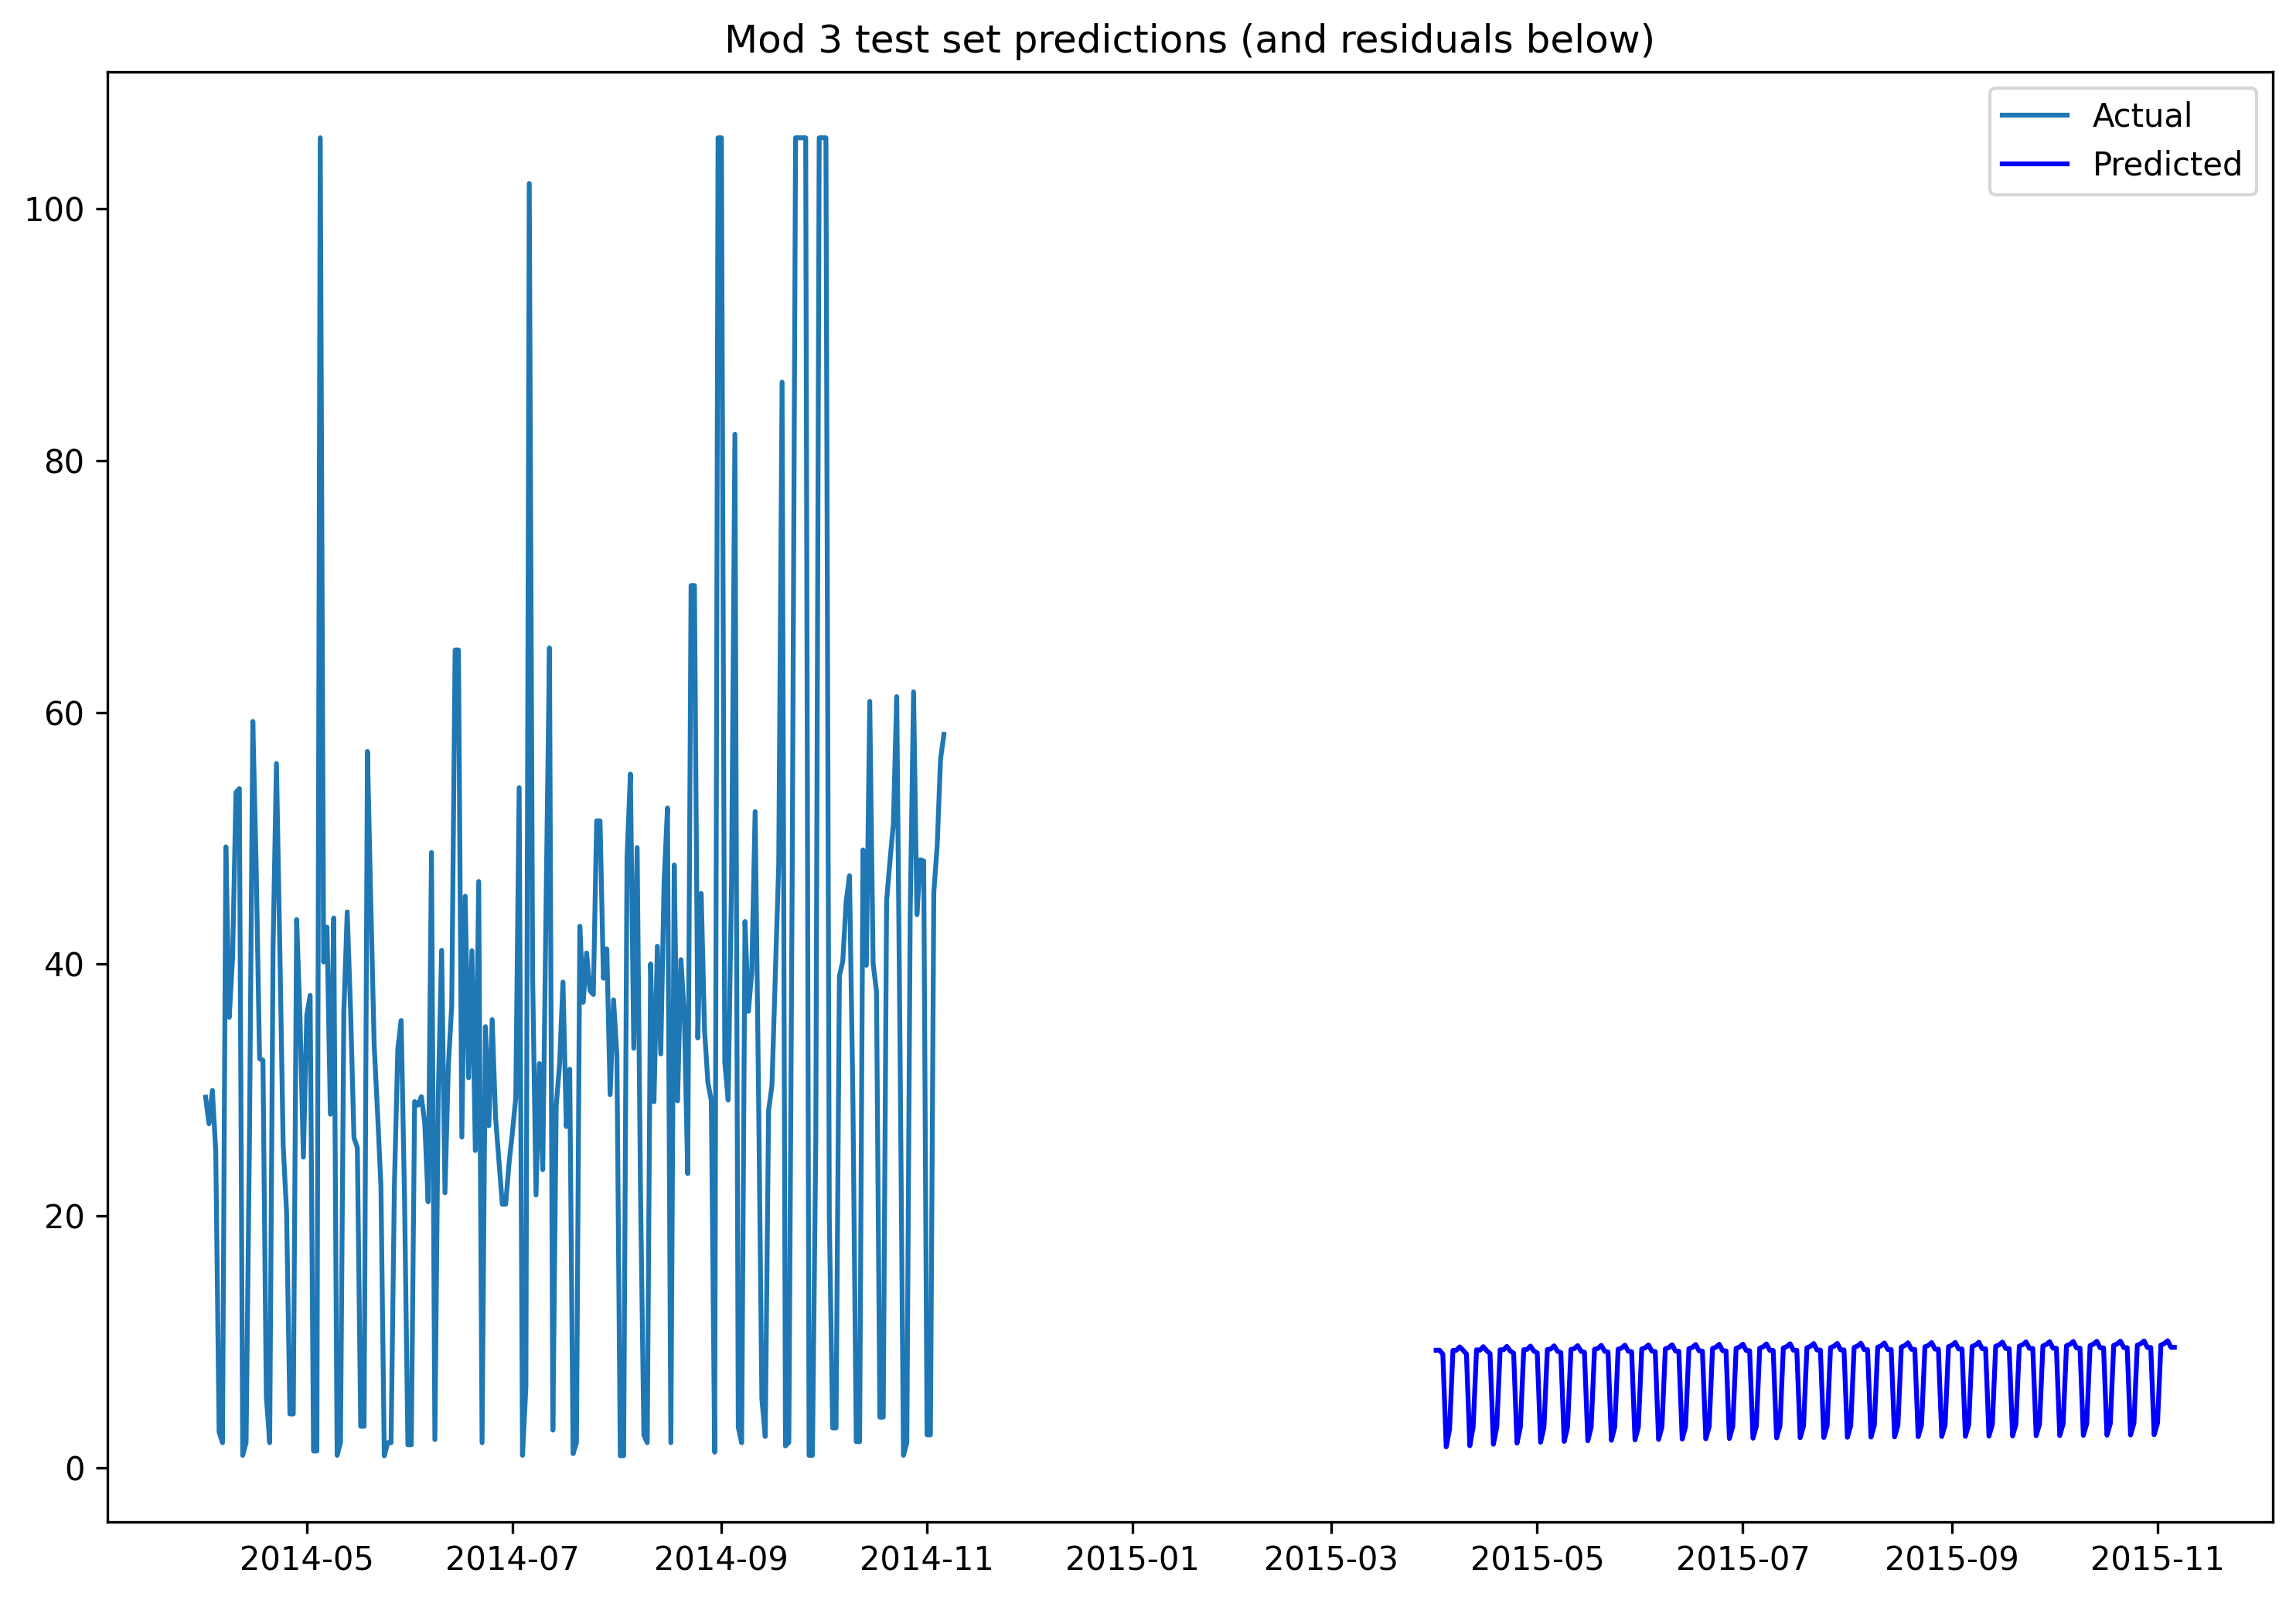

In [ ]:
# Model Fit
mod3 = ARIMA(ts_boxcox_series,
             order=(1, 1, 1),
             seasonal_order=(2, 1, 2, 7))
mod3 = mod3.fit()

mod3_forecast = mod3.get_forecast(steps=len(ts.iloc[test_start_idx:test_end_idx]))
mod3_forecast_mean = mod3_forecast.predicted_mean

mod3_pre_values = pd.Series(mod3_forecast_mean, index=pd.date_range(start=test_start, periods=len(ts.iloc[test_start_idx:test_end_idx])))

plt.plot(ts.iloc[test_start_idx:test_end_idx], label='Actual', linewidth=1.5)
plt.plot(mod3_forecast_mean, label='Predicted', color='blue', linewidth=1.5)
plt.title("Mod 3 test set predictions (and residuals below)")
plt.legend()
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit the SARIMAX model with seasonal components
sarimax_model = SARIMAX(ts.iloc[train_start_idx:train_end_idx],
                        order=(1, 1, 1), seasonal_order=(2, 0, 1, 7), trend='c')
sarimax_results = sarimax_model.fit()

# Forecast for test set
sarimax_forecast = sarimax_results.get_forecast(steps=len(ts.iloc[test_start_idx:test_end_idx]))
forecast_mean = sarimax_forecast.predicted_mean
# Adjust the periods to match the length of the test set
sarimax_pre_values = pd.Series(forecast_mean, index=pd.date_range(start=test_start, periods=len(ts.iloc[test_start_idx:test_end_idx])))

# Plot actual vs predicted
plt.plot(ts.iloc[test_start_idx:test_end_idx], label='Actual', linewidth=1.5)
plt.plot(forecast_mean, label='Predicted', color='blue', linewidth=1.5)
plt.title("SARIMAX Test Set Predictions")
plt.legend()
plt.show()


In [ ]:
print(mod3.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                 3009
Model:             ARIMA(1, 1, 1)x(2, 1, [1, 2], 7)   Log Likelihood               -7143.363
Date:                              Tue, 07 Jan 2025   AIC                          14300.726
Time:                                      11:01:55   BIC                          14342.773
Sample:                                  01-04-2007   HQIC                         14315.850
                                       - 03-31-2015                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2099      0.014     15.283      0.000       0.183       0.237
ma.L1         -0.98

In [ ]:
# Use the test set for comparison:
mae_value = error_func(ts.iloc[test_start_idx:test_end_idx], sarimax_pre_values)
# 'ts.iloc[test_start_idx:test_end_idx]' should have the same length as 'mod_arima_1_pre_values' (220)

# Then print using the new variable name:
print('MAE: ', int(mae_value))

In [ ]:


df_train = df[df.date < pd.Timestamp('2013-03-31')].copy()
df_test = df[df.date >= pd.Timestamp('2013-03-31')].copy()

# Apply log transformation
log_train_data = df_train['log_ave_days']

# Fit ARIMA model on log-transformed data
model = SARIMAX(log_train_data, order=(1, 1, 1), seasonal_order=(2, 0, 1, 7), trend='c')
results = model.fit()

# Forecast and transform back
log_forecast = results.get_forecast(steps=len(df_test))
log_forecast_mean = log_forecast.predicted_mean
forecast_original_scale = np.exp(log_forecast_mean)

# Compute MAE
mae = compute_mae(df_test['ave_days'], forecast_original_scale)
print("MAE on original scale:", mae)


KeyError: 'log_ave_days'